In [1]:
import mne
# from mne.io import read_raw
import numpy as np
# import matplotlib.pyplot as plt
from os.path import join
import os
# import pandas as pd
import json
# from collections import defaultdict

from functions import ephy_plotting, utils, analysis, ephy_meta_function

In [56]:
import importlib
importlib.reload(analysis)

<module 'functions.analysis' from 'c:\\Users\\Juliette\\Research\\Projects\\analysis_mSST\\scripts\\functions\\analysis.py'>

# 1. Load the dataset #

In [2]:
working_path = os.path.dirname(os.getcwd())
results_path = join(working_path, "results")
behav_results_saving_path = join(results_path, "behav_results")
# read the json file containing the included and excluded subjects, based on the behavioral results
included_excluded_file = join(results_path, 'final_included_subjects.json')
with open(included_excluded_file, 'r') as file:
    included_subjects = json.load(file)

In [3]:
included_subjects   

['C003 mSST',
 'C004 mSST',
 'C005 mSST',
 'C006 mSST',
 'C007 mSST',
 'C008 mSST',
 'C009 mSST',
 'C010 mSST',
 'C011 mSST',
 'C012 mSST',
 'C013 mSST',
 'sub006 DBS ON mSST',
 'sub006 DBS OFF mSST',
 'sub011 DBS OFF mSST',
 'sub011 DBS ON mSST',
 'sub012 DBS ON mSST',
 'sub012 DBS OFF mSST',
 'sub015 DBS OFF mSST',
 'sub015 DBS ON mSST',
 'sub019 DBS ON mSST',
 'sub019 DBS OFF mSST',
 'sub023 DBS OFF mSST',
 'sub023 DBS ON mSST',
 'sub025 DBS ON mSST',
 'sub025 DBS OFF mSST',
 'sub027 DBS ON mSST',
 'sub027 DBS OFF mSST',
 'sub028 DBS OFF mSST',
 'sub028 DBS ON mSST',
 'sub029 DBS ON mSST',
 'sub029 DBS OFF mSST',
 'sub032 DBS ON mSST',
 'sub032 DBS OFF mSST',
 'sub033 DBS ON mSST',
 'sub033 DBS OFF mSST']

In [4]:
included_subjects.remove('sub032 DBS OFF mSST')  # remove this subject due to too many artifacts
included_subjects.remove('sub032 DBS ON mSST')  # remove this subject due to too many artifacts
included_subjects.remove('sub029 DBS OFF mSST')  # remove this subject due to too many artifacts
included_subjects.remove('sub029 DBS ON mSST')  # remove this subject due to too many artifacts
included_subjects.remove('sub023 DBS OFF mSST')  # remove this subject due to too many artifacts
included_subjects.remove('sub023 DBS ON mSST')  # remove this subject due to too many artifacts
# included_subjects.remove('sub028 DBS ON mSST')  # remove this subject for erp
# included_subjects.remove('sub033 DBS OFF mSST')  # remove this subject for erp
# included_subjects.remove('sub033 DBS ON mSST')  # remove this subject for erp
# included_subjects.remove('sub019 DBS OFF mSST')  # remove this subject for gamma analysis
# included_subjects.remove('sub019 DBS ON mSST')  # remove this subject for gamma analysis
# included_subjects.remove('sub025 DBS OFF mSST')  # remove this subject for gamma analysis
# included_subjects.remove('sub025 DBS ON mSST') # remove this subject for gamma analysis
# included_subjects.remove('sub032 DBS OFF mSST')  # remove this subject for gamma analysis
# included_subjects.remove('sub032 DBS ON mSST') # remove this subject for gamma analysis

In [5]:
# working_path = os.path.dirname(os.getcwd())
# results_path = join(working_path, "results")
# behav_results_saving_path = join(results_path, "behav_results")
# # read the json file containing the included and excluded subjects, based on the behavioral results
# included_excluded_file = join(behav_results_saving_path, 'final_included_subjects.json')
# with open(included_excluded_file, 'r') as file:
#     included_subjects = json.load(file)

# keep only subjects starting with "sub":X
included_subjects = [subj for subj in included_subjects if subj.startswith('sub')]
print(f'Included_subjects: {included_subjects}')
onedrive_path = utils._get_onedrive_path()

#  Set saving path
filtered_epochs = False
if filtered_epochs:
    filt = [None, 40]  # Frequency range for filtering
    freq_wide = f'{filt[0]}-{filt[1]}Hz'
    fmin = filt[0]
    fmax = filt[1]
else:
    freq_wide = 'all frequencies'
    fmin = 1
    fmax = 80

#freq_wide = f'{40}-{80}Hz'
saving_path_group = join(results_path, 'group_level', 'lfp_perc_sig_change', freq_wide)  
os.makedirs(saving_path_group, exist_ok=True)  # Create the directory if it doesn't exist
saving_path_on_off = join(results_path, 'ON_vs_OFF', freq_wide)
os.makedirs(saving_path_on_off, exist_ok=True)

# Set source path for epochs
if filtered_epochs:
    epochs_path = join(results_path, 'lfp_epochs',
                    f'Filtered {filt[0]}-{filt[1]}Hz'
                    )
else:
    epochs_path = join(results_path, 'lfp_epochs')
    
sub_dict_epochs = {}  #  Stores the epochs for each subject/session

Included_subjects: ['sub006 DBS ON mSST', 'sub006 DBS OFF mSST', 'sub011 DBS OFF mSST', 'sub011 DBS ON mSST', 'sub012 DBS ON mSST', 'sub012 DBS OFF mSST', 'sub015 DBS OFF mSST', 'sub015 DBS ON mSST', 'sub019 DBS ON mSST', 'sub019 DBS OFF mSST', 'sub025 DBS ON mSST', 'sub025 DBS OFF mSST', 'sub027 DBS ON mSST', 'sub027 DBS OFF mSST', 'sub028 DBS OFF mSST', 'sub028 DBS ON mSST', 'sub033 DBS ON mSST', 'sub033 DBS OFF mSST']


In [6]:
for session_ID in included_subjects:
    if filtered_epochs:
        prefix = f'filtered-{filt[0]}-{filt[1]}Hz'
    else:
        prefix = 'long'
    epochs = mne.read_epochs(os.path.join(epochs_path, f"{session_ID}_cleaned-{prefix}-epo.fif"), preload=True)
    sub_dict_epochs[session_ID] = epochs

Reading c:\Users\Juliette\Research\Projects\analysis_mSST\results\lfp_epochs\sub006 DBS ON mSST_cleaned-long-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =   -3499.98 ...    3499.98 ms
        0 CTF compensation matrices available
Adding metadata with 15 columns
623 matching events found
No baseline correction applied
0 projection items activated
Reading c:\Users\Juliette\Research\Projects\analysis_mSST\results\lfp_epochs\sub006 DBS OFF mSST_cleaned-long-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =   -3500.22 ...    3500.22 ms
        0 CTF compensation matrices available
Adding metadata with 20 columns
454 matching events found
No baseline correction applied
0 projection items activated
Reading c:\Users\Juliette\Research\Projects\analysis_mSST\results\lfp_epochs\sub011 DBS OFF mSST_cleaned-long-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =   -3500.12 ...    3500.12 ms
        0 CTF compensation matrice

In [7]:
sub_dict_epochs['sub006 DBS OFF mSST']

<EpochsFIF | 454 events (all good), -3.5 – 3.5 s (baseline off), ~12.1 MB, data loaded, with metadata,
 'GC': 57
 'GF': 58
 'GO': 168
 'GS': 57
 'continue': 57
 'stop': 57>

In [14]:
# load threshold_jc dictionary from json file
threshold_file = join(results_path, 'gc_thresholds.json')
with open(threshold_file, 'r') as f:
    threshold_gc_dict = json.load(f)

In [16]:

######################
### TFR PARAMETERS ###
######################

decim = 1 
fmin_freq = fmin if fmin is not None else 1
#freqs = np.arange(fmin_freq, fmax, 1) 
freqs = np.arange(fmin_freq, 80, 1)
# For 500ms time resolution at 1 Hz: n_cycles = 1 * 0.5 = 0.5
# For 50ms time resolution at 40 Hz: n_cycles = 40 * 0.05 = 2
# Linear interpolation between these points
#n_cycles = 0.5 + (freqs - 1) * (2 - 0.5) / (40 - 1)
#n_cycles = freqs / 2.0
n_cycles = np.minimum(np.maximum(freqs / 2.0, 2), 20)

tfr_args = dict(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    decim=decim,
    return_itc=False,
    average=False
)        

baseline_correction_method = 'group_average' # 'group_average' or 'single_trial'
tmin_tmax = [0, 1500]
vmin_vmax = [-5, 5] if baseline_correction_method == 'single_trial' else [-70, 70]


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# from functions.analysis import get_tfr_decomposition
# from functions.ephy_plotting import plot_tfr_result

import mne
import pandas as pd
import os
import scipy 
from functions.analysis import identify_significant_clusters


def plot_tfr_result_contrast_groups(
        groups,
        tfr_dict,
        epochs_cond,
        roi,
        tfr_args,
        tmin_tmax,
        vmin_vmax,
        baseline_correction,
        baseline_correction_method,
        sub_num,
        saving_path
        ):
    
    add_rt = False
    add_ssd = False
    dependent_measures = False  # by default, measures are treatet as independent

    contrast = groups[0] + ' - ' + groups[1]

    title_prefix = "Power change" if baseline_correction else "Power"
    bc_note = "" if baseline_correction else ", no baseline correction"
    subject_info = f"nSub = {sub_num}" #if sub_num > 1 else sub
    cond_type, outcome = epochs_cond.split('_')[:2]
    # cond_type2, outcome2 = epochs_cond[1].split('_')[:2]

    # Set the x label based on what the epochs are centered on:
    aligned_on = epochs_cond.split('_')[-1] # both conditions should always be centered on the same cue

    if aligned_on == 'response':
        xlabel = 'Time from RESPONSE (s)'
    elif aligned_on == 'feedback':
        xlabel = 'Time from FEEDBACK (s)'
    elif aligned_on == 'square':
        xlabel = 'Time from GO cue (s)'
        add_rt = True if (
        (cond_type in ('GO', 'GF', 'GC') and outcome == 'successful') or
        (cond_type == 'GS' and outcome == 'unsuccessful')
        ) else False
        add_ssd = True if any(x in epochs_cond for x in ('GS', 'GC')) else False
    elif aligned_on == 'triangle':
        xlabel = 'Time from STOP/CONTINUE cue (s)'
        add_rt = True if (cond_type == 'GS' and outcome == 'unsuccessful') or (cond_type == 'GC' and outcome == 'successful') else False

    # check that time dimensions are the same for both groups, if not crop to the minimum length
    shape0 = tfr_dict[groups[0]][epochs_cond]['all_percentage_change'].shape
    shape1 = tfr_dict[groups[1]][epochs_cond]['all_percentage_change'].shape
    if shape0[2] != shape1[2]:
        print(f"The two groups have different time dimensions: {shape0[2]} vs {shape1[2]}. Cropping to the minimum length for contrast.")
    min_len = min(shape0[2], shape1[2])
    times = tfr_dict[groups[0]][epochs_cond]['times']
    tfr_dict[groups[0]][epochs_cond]['all_percentage_change'] = tfr_dict[groups[0]][epochs_cond]['all_percentage_change'][:, :, :min_len]
    tfr_dict[groups[1]][epochs_cond]['all_percentage_change'] = tfr_dict[groups[1]][epochs_cond]['all_percentage_change'][:, :, :min_len]
    times = times[:min_len]

    if 'DBS' in groups[0] and 'DBS' in groups[1]:
        # if both groups are DBS groups then measures are dependent because they come from the same subjects
        dependent_measures = True

        # tfr_dict[coi]['times'] = times
        contrast_percentage_change = tfr_dict[groups[0]][epochs_cond]['all_percentage_change'] - tfr_dict[groups[1]][epochs_cond]['all_percentage_change']
        tfr_dict[epochs_cond] = {}
        tfr_dict[epochs_cond]['contrast_groups'] = {
            'all_percentage_change': contrast_percentage_change,
            'times': times,
            'freqs': freqs}
        all_percentage_change = tfr_dict[epochs_cond]['contrast_groups']['all_percentage_change']

    else:
        # independent measures, at least one group is controls
        all_percentage_change = [tfr_dict[groups[0]][epochs_cond]['all_percentage_change'], 
                                      tfr_dict[groups[1]][epochs_cond]['all_percentage_change']]      

    mean_rt_all1 = tfr_dict[groups[0]][epochs_cond]['mean_rt_all']
    mean_rt_all2 = tfr_dict[groups[1]][epochs_cond]['mean_rt_all']
    mean_ssd_all1 = tfr_dict[groups[0]][epochs_cond]['mean_ssd_all']
    mean_ssd_all2 = tfr_dict[groups[1]][epochs_cond]['mean_ssd_all']
    # n_obs = all_percentage_change.shape[0]
    # # print(n_obs)
    pval = 0.05
    # df = n_obs - 1
    # threshold = scipy.stats.t.ppf(1-pval / 2, df) # two-tailed distribution
    threshold = None
    n_permutations = 1000

    # Compute permutation cluster test 
    if dependent_measures:
        T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
        all_percentage_change, n_permutations=n_permutations,
        threshold=threshold, tail=0,
        out_type= "mask", seed=11111, verbose=True)

    else:
        # F_observed, clusters, cluster_p_values, H0 for independent samples
        T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        all_percentage_change, n_permutations=n_permutations,
        threshold=threshold, tail=0,
        out_type= "mask", seed=11111, verbose=True)
    print(f"p_values: {cluster_p_values}")
    print(f"P_values shape: {cluster_p_values.shape}")
    
    condition = epochs_cond + '_' + contrast
    identify_significant_clusters(
        cluster_p_values, 
        clusters,
        tfr_dict[epochs_cond]['contrast_groups']['times'],
        T_obs,
        pval,
        tfr_args,
        condition = condition,
        roi = roi,
        saving_path = saving_path
        )

    # Compute grand averages
    avg_percentage_change = np.nanmean(all_percentage_change, axis=0)     
    assert T_obs.shape == avg_percentage_change.shape  

    # Compute min and max along the frequency axis
    if not baseline_correction:
        min_values = np.min(avg_percentage_change)  # Shape: (n_subjects, n_times)
        max_values = np.max(avg_percentage_change)
        
    # Plot
    # plt.figure(figsize=(4, 6))
    fig, ax = plt.subplots(figsize=(4, 6), constrained_layout=True)
    vmin, vmax = (vmin_vmax if baseline_correction else (min_values, max_values))
    times = tfr_dict[epochs_cond]['contrast_groups']['times'] 
    print(f'vmin: {vmin}, vmax: {vmax}')
    ax.imshow(avg_percentage_change, aspect='auto', origin='lower', 
                            # extent=[tmin_tmax[0]*1000, tmin_tmax[1]*1000, tfr_args["freqs"][0], tfr_args["freqs"][-1]], 
                            extent = [times[0], times[-1], freqs[0], freqs[-1]],
                            cmap='jet', vmin=vmin, vmax=vmax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency (Hz)')
    title_text = f"{title_prefix} \n {epochs_cond} \n {contrast} \n {roi} \n {subject_info}{bc_note}"
    fig.suptitle(title_text, fontsize=10)
    # ax.set_title(f"{title_prefix} \n {contrast} \n {roi} \n {subject_info}{bc_note}")
        
    if baseline_correction:
        if baseline_correction_method == 'single_trial':
            colorbar_label = 'Change from baseline (dB)'
        else:
            colorbar_label = 'Percent change from baseline (%)'
    else:
        colorbar_label = 'Mean Power (µV²)'
    fig.colorbar(ax.images[0], label=colorbar_label)   
    
    # add significant clusters on the plot if group-level analysis:
    if sub_num > 1:
        for c, p_val in zip(clusters, cluster_p_values):
            if p_val <= pval:
                mask = np.zeros_like(T_obs, dtype=bool)  # Explicitly match dimensions
                mask[c] = True
                ax.contour(mask, levels=[0.5], colors='black', linewidths=1.5,
                            extent=[tmin_tmax[0]*1000, tmin_tmax[1]*1000, tfr_args["freqs"][0], tfr_args["freqs"][-1]])

    if add_rt:
        avg_rt1 = np.nanmean(mean_rt_all1)*1000
        avg_rt2 = np.nanmean(mean_rt_all2)*1000
        if aligned_on == 'triangle':
            avg_rt1 -= np.nanmean(mean_ssd_all1)*1000
            avg_rt2 -= np.nanmean(mean_ssd_all2)*1000
        ax.axvline(x=avg_rt1, color='black', linestyle='-', label=f'Mean RT {epochs_cond} {groups[0]}')
        ax.axvline(x=avg_rt2, color='gray', linestyle='-', label=f'Mean RT {epochs_cond} {groups[1]}')

    if add_ssd :
        if mean_ssd_all1 is not None:
            avg_ssd1 = np.nanmean(mean_ssd_all1)*1000
            ax.axvline(x=avg_ssd1, color='k', linestyle='--', label=f'Mean SSD {groups[0]}')
        if mean_ssd_all2 is not None:
            avg_ssd2 = np.nanmean(mean_ssd_all2)*1000
            ax.axvline(x=avg_ssd2, color='k', linestyle='--', label=f'Mean SSD {groups[1]}')
    
    fig.savefig(os.path.join(saving_path, f"{epochs_cond}_{contrast}_{roi}_nSub{str(sub_num)}.png"))


def plot_tfr_result_contrast(
        group,
        tfr_dict,
        epochs_cond,
        roi,
        tfr_args,
        tmin_tmax,
        vmin_vmax,
        baseline_correction,
        baseline_correction_method,
        sub_num,
        saving_path,
        save_as = 'png'
        ):
    add_rt1 = False
    add_rt2 = False
    add_ssd1 = False
    add_ssd2 = False

    contrast = epochs_cond[0] + ' - ' + epochs_cond[1]

    title_prefix = "Power change" if baseline_correction else "Power"
    bc_note = "" if baseline_correction else ", no baseline correction"
    subject_info = f"nSub = {sub_num}" #if sub_num > 1 else sub
    cond_type1, outcome1 = epochs_cond[0].split('_')[:2]
    cond_type2, outcome2 = epochs_cond[1].split('_')[:2]

    # Set the x label based on what the epochs are centered on:
    aligned_on = epochs_cond[0].split('_')[-1] # both conditions should always be centered on the same cue

    if aligned_on == 'response':
        xlabel = 'Time from RESPONSE (s)'
    elif aligned_on == 'feedback':
        xlabel = 'Time from FEEDBACK (s)'
    elif aligned_on == 'square':
        xlabel = 'Time from GO cue (s)'
        add_rt1 = True if (
        (cond_type1 in ('lmGO', 'GO', 'GF', 'GC', 'slowGC', 'fastGC') and outcome1 == 'successful') or
        (cond_type1 == 'GS' and outcome1 == 'unsuccessful')
        ) else False
        add_rt2 = True if (
        (cond_type2 in ('lmGO', 'GO', 'GF', 'GC', 'slowGC', 'fastGC') and outcome2 == 'successful') or
        (cond_type2 == 'GS' and outcome2 == 'unsuccessful')
        ) else False
        add_ssd1 = True if any(x in epochs_cond[0] for x in ('GS', 'GC', 'slowGC', 'fastGC')) else False
        add_ssd2 = True if any(x in epochs_cond[1] for x in ('GS', 'GC', 'slowGC', 'fastGC')) else False
    elif aligned_on == 'triangle':
        xlabel = 'Time from STOP/CONTINUE cue (s)'
        add_rt1 = True if (cond_type1 == 'GS' and outcome1 == 'unsuccessful') or (cond_type1 in ('GC', 'slowGC', 'fastGC') and outcome1 == 'successful') else False
        add_rt2 = True if (cond_type2 == 'GS' and outcome2 == 'unsuccessful') or (cond_type2 in ('GC', 'slowGC', 'fastGC') and outcome2 == 'successful') else False

    all_percentage_change = tfr_dict[group]['contrast']['all_percentage_change']
    mean_rt_all1 = tfr_dict[group][epochs_cond[0]]['mean_rt_all']
    mean_rt_all2 = tfr_dict[group][epochs_cond[1]]['mean_rt_all']
    mean_ssd_all1 = tfr_dict[group][epochs_cond[0]]['mean_ssd_all']
    mean_ssd_all2 = tfr_dict[group][epochs_cond[1]]['mean_ssd_all']
    n_obs = all_percentage_change.shape[0]
    print(n_obs)
    pval = 0.05
    # df = n_obs - 1
    # threshold = scipy.stats.t.ppf(1-pval / 2, df) # two-tailed distribution
    threshold = None
    n_permutations = 1000

    # Compute permutation cluster test for the left stn
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
    all_percentage_change, n_permutations=n_permutations,
    threshold=threshold, tail=0,
    out_type= "mask", seed=11111, verbose=True)
    print(f"p_values: {cluster_p_values}")
    print(f"P_values shape: {cluster_p_values.shape}")
    
    condition = group + '_' + contrast
    identify_significant_clusters(
        cluster_p_values, 
        clusters,
        tfr_dict[group]['contrast']['times'],
        T_obs,
        pval,
        tfr_args,
        condition = condition,
        roi = roi,
        saving_path = saving_path
        )

    # Compute grand averages
    avg_percentage_change = np.nanmean(all_percentage_change, axis=0)     
    assert T_obs.shape == avg_percentage_change.shape  

    # Compute min and max along the frequency axis
    if not baseline_correction:
        min_values = np.min(avg_percentage_change)  # Shape: (n_subjects, n_times)
        max_values = np.max(avg_percentage_change)
        
    # Plot
    # plt.figure(figsize=(4, 6))
    fig, ax = plt.subplots(figsize=(4, 6), constrained_layout=True)
    vmin, vmax = (vmin_vmax if baseline_correction else (min_values, max_values))
    times = tfr_dict[group]['contrast']['times'] 
    print(f'vmin: {vmin}, vmax: {vmax}')
    ax.imshow(avg_percentage_change, aspect='auto', origin='lower', 
                            # extent=[tmin_tmax[0]*1000, tmin_tmax[1]*1000, tfr_args["freqs"][0], tfr_args["freqs"][-1]], 
                            extent = [times[0], times[-1], freqs[0], freqs[-1]],
                            cmap='jet', vmin=vmin, vmax=vmax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency (Hz)')
    title_text = f"{title_prefix} \n {group} \n {contrast} \n {roi} \n {subject_info}{bc_note}"
    fig.suptitle(title_text, fontsize=10)
    # ax.set_title(f"{title_prefix} \n {contrast} \n {roi} \n {subject_info}{bc_note}")
        
    if baseline_correction:
        if baseline_correction_method == 'single_trial':
            colorbar_label = 'Change from baseline (dB)'
        else:
            colorbar_label = 'Percent change from baseline (%)'
    else:
        colorbar_label = 'Mean Power (µV²)'
    fig.colorbar(ax.images[0], label=colorbar_label)   
    
    # add significant clusters on the plot if group-level analysis:
    if sub_num > 1:
        for c, p_val in zip(clusters, cluster_p_values):
            if p_val <= 0.05:
                mask = np.zeros_like(T_obs, dtype=bool)  # Explicitly match dimensions
                mask[c] = True
                ax.contour(mask, levels=[0.5], colors='black', linewidths=1.5,
                            extent=[tmin_tmax[0]*1000, tmin_tmax[1]*1000, tfr_args["freqs"][0], tfr_args["freqs"][-1]])

    if add_rt1:
        avg_rt1 = np.nanmean(mean_rt_all1)*1000
        if aligned_on == 'triangle':
            avg_rt1 -= np.nanmean(mean_ssd_all1)*1000
        ax.axvline(x=avg_rt1, color='black', linestyle='-', label=f'Mean RT {epochs_cond[0]}')
    if add_rt2:
        avg_rt2 = np.nanmean(mean_rt_all2)*1000
        if aligned_on == 'triangle':
            avg_rt2 -= np.nanmean(mean_ssd_all2)*1000
        ax.axvline(x=avg_rt2, color='gray', linestyle='-', label=f'Mean RT {epochs_cond[1]}')
    if add_ssd1 and mean_ssd_all1 is not None:
        avg_ssd1 = np.nanmean(mean_ssd_all1)*1000
        ax.axvline(x=avg_ssd1, color='k', linestyle='--', label='Mean SSD')
    if add_ssd2 and mean_ssd_all2 is not None:
        avg_ssd2 = np.nanmean(mean_ssd_all2)*1000
        ax.axvline(x=avg_ssd2, color='k', linestyle='--', label='Mean SSD')
    fig.savefig(os.path.join(saving_path, f"{group}_{contrast}_{roi}_nSub{str(sub_num)}.{save_as}"))
     



def plot_tfr_result(
        group,
        all_percentage_change,
        times,
        epochs_cond,
        roi,
        tfr_args,
        tmin_tmax,
        vmin_vmax,
        baseline_correction,
        baseline_correction_method,
        sub_num,
        sub = None,
        mean_rt_all = None,
        mean_ssd_all = None,
        saving_path = None,
        save_as = 'png'
        ):
    add_rt = False
    add_ssd = False

    title_prefix = "Power change" if baseline_correction else "Power"
    bc_note = "" if baseline_correction else ", no baseline correction"
    subject_info = f"nSub = {sub_num}" if sub_num > 1 else sub
    cond_type, outcome = epochs_cond.split('_')[:2]

    # Set the x label based on what the epochs are centered on:
    aligned_on = epochs_cond.split('_')[-1]
    if aligned_on == 'response':
        xlabel = 'Time from RESPONSE (s)'
    elif aligned_on == 'feedback':
        xlabel = 'Time from FEEDBACK (s)'
    elif aligned_on == 'square':
        xlabel = 'Time from GO cue (s)'
        add_rt = True if (
        (cond_type in ('lmGO', 'GO', 'GF', 'GC', 'slowGC', 'fastGC') and outcome == 'successful') or
        (cond_type == 'GS' and outcome == 'unsuccessful')
        ) else False
        add_ssd = True if any(x in epochs_cond for x in ('GS', 'GC', 'slowGC', 'fastGC')) else False
    elif aligned_on == 'triangle':
        xlabel = 'Time from STOP/CONTINUE cue (s)'
        add_rt = True if (cond_type == 'GS' and outcome == 'unsuccessful') or (cond_type in ('GC', 'slowGC', 'fastGC') and outcome == 'successful') else False

    # Compute grand averages
    avg_percentage_change = np.nanmean(all_percentage_change, axis=0)       

    # Compute min and max along the frequency axis
    if not baseline_correction:
        min_values = np.min(avg_percentage_change)  # Shape: (n_subjects, n_times)
        max_values = np.max(avg_percentage_change)
        
    # Plot Left STN
    # plt.figure(figsize=(4, 6))
    fig, ax = plt.subplots(figsize=(4, 6), constrained_layout=True)
    vmin, vmax = (vmin_vmax if baseline_correction else (min_values, max_values))
    ax.imshow(avg_percentage_change, aspect='auto', origin='lower', 
                            extent=[times[0], times[-1], tfr_args["freqs"][0], tfr_args["freqs"][-1]], 
                            cmap='jet', vmin=vmin, vmax=vmax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency (Hz)')
    title_text = f"{title_prefix} \n {group} \n {epochs_cond} \n {roi} \n {subject_info}{bc_note}"
    fig.suptitle(title_text, fontsize=10)
    # ax.set_title(f"{title_prefix} \n {group} \n {epochs_cond} \n {roi} \n {subject_info}{bc_note}")
    if add_rt:
        avg_rt = np.nanmean(mean_rt_all)*1000
        if aligned_on == 'triangle':
            avg_rt -= np.nanmean(mean_ssd_all)*1000
        ax.axvline(x=avg_rt, color='black', linestyle='-', label='Mean RT')
    if add_ssd and mean_ssd_all is not None:
        avg_ssd = np.nanmean(mean_ssd_all)*1000
        ax.axvline(x=avg_ssd, color='k', linestyle='--', label='Mean SSD')
        
    if baseline_correction:
        if baseline_correction_method == 'single_trial':
            colorbar_label = 'Change from baseline (dB)'
        else:
            colorbar_label = 'Percent change from baseline (%)'
    else:
        colorbar_label = 'Mean Power (µV²)'
    fig.colorbar(ax.images[0], label=colorbar_label)    
    fig.savefig(os.path.join(saving_path, f"{group}_{epochs_cond}_{roi}_{subject_info}.{save_as}"))



def get_tfr_decomposition(
        epochs, 
        cond_of_interest, 
        ch_names, 
        tfr_args, 
        baseline_correction, 
        baseline_correction_method, 
        tmin_tmax,
        threshold_GC
        ):
    latency_matched = False
    slowGC = False
    fastGC = False
    mean_rt = None
    mean_ssd = None
    
    if cond_of_interest.split('_')[0] == 'lmGO':
        latency_matched = True
        epoch_type = 'GO'
    elif cond_of_interest.split('_')[0] == 'slowGC':
        slowGC = True
        epoch_type = 'GC'
    elif cond_of_interest.split('_')[0] == 'fastGC':
        fastGC = True
        epoch_type = 'GC'
    else:
        # Parse epoch condition
        epoch_type = cond_of_interest.split('_')[0]

    outcome_str, aligned_str = cond_of_interest.split('_')[1], cond_of_interest.split('_')[2]
    outcome = 1.0 if outcome_str == "successful" else 0.0     

    # Select the appropriate epochs
    type_mask = epochs.metadata["event"] == epoch_type
    outcome_mask = epochs.metadata["key_resp_experiment.corr"] == outcome
    data = epochs[type_mask & outcome_mask]    

    if latency_matched:
        rt = np.asarray(data.metadata['key_resp_experiment.rt'])
        threshold = np.percentile(rt, 50)
        slow_mask = rt >= threshold
        data = data[slow_mask] 

    if slowGC:
        rt = np.asarray(data.metadata['key_resp_experiment.rt'])
        ssd = np.asarray(data.metadata['continue_signal_time'])
        threshold = threshold_GC/1000 # this value should be added for each trial to the SSD 
        rt_from_continue = rt - ssd
        slow_mask = rt_from_continue >= threshold
        # slow_mask = rt >= (ssd + threshold)
        data = data[slow_mask]

    if fastGC:
        rt = np.asarray(data.metadata['key_resp_experiment.rt'])
        ssd = np.asarray(data.metadata['continue_signal_time'])
        threshold = threshold_GC/1000 # this value should be added for each trial to the SSD 
        rt_from_continue = rt - ssd
        fast_mask = rt_from_continue < threshold
        data = data[fast_mask]

    # get RTs and SSDs for later plotting:
    rt = np.asarray(data.metadata['key_resp_experiment.rt'])
    if np.any(~np.isnan(rt)):        # at least one value that is not nan
        mean_rt = np.nanmean(rt)
    else:
        mean_rt = None

    ssd = None
    if epoch_type == 'GS':
        ssd = np.asarray(data.metadata['stop_signal_time'])
    elif epoch_type == 'GC':
        ssd = np.asarray(data.metadata['continue_signal_time'])
    mean_ssd = np.nanmean(ssd) if ssd is not None else None

    # Select only desired channels
    epochs = data.copy().pick(ch_names)

    # Compute TFR
    power = epochs.compute_tfr(**tfr_args)  # shape: (n_epochs, n_channels, n_freqs, n_times)      
    power.data *= 1e12  # V² → (µV)²
    
    # Average across channels if multiple channels are specified
    if len(ch_names) > 1:
        power_mean = np.nanmean(power.data, axis=1)  # (n_epochs, n_freqs, n_times)
    else:
        power_mean = power.data[:, 0, :, :]  # (n_epochs, n_freqs, n_times)

    times = power.times * 1000
    dt_ms = 1000/round(epochs.info['sfreq'])
    #n_times_new = int(np.round(((tmin_tmax[1]- tmin_tmax[0])*1000) / dt_ms))
    freqs = power.freqs

    # crop to keep only times of interest               
    # determine t0 et t1 indices based on tmin_tmax and aligned_str
    if aligned_str != 'square':
        if aligned_str == 'response':
            t0_per_trial = np.array(data.metadata['key_resp_experiment.rt']) * 1000  # convert to ms
        elif aligned_str == 'feedback':
            if epoch_type == 'GS' and outcome_str == 'successful':
                t0_per_trial = (np.array(data.metadata['stop_signal_time']) + 1.5) * 1000  # feedback is at 1000 ms after response
            else:
                t0_per_trial = (np.array(data.metadata['key_resp_experiment.rt']) + 0.5) * 1000  # feedback is at 500 ms after response
        elif aligned_str == 'triangle':
            if epoch_type == 'GS': 
                ssd_column = 'stop_signal_time'
            elif epoch_type == 'GC':
                ssd_column = 'continue_signal_time'                        
            t0_per_trial = np.array(data.metadata[ssd_column]) * 1000
    
        new_epochs = []
        if baseline_correction and baseline_correction_method == 'group_average':
            # baseline_power = np.empty((power_mean.shape[0], power_mean.shape[1], 1))  # (n_trials, n_freqs, 1)
            mean_power = np.nanmean(power_mean, axis=0)  # (n_freqs, n_times)
            # Define baseline period for change calculation
            baseline_indices = (times >= -500) & (times <= -200)
            baseline_power = np.nanmean(mean_power[:, baseline_indices], axis=1, keepdims=True)  # shape: (n_freqs, 1 time)            
        
        for i in range(power_mean.shape[0]):
            t0_idx = t0_per_trial[i] + tmin_tmax[0]*1000
            t1_idx = t0_per_trial[i] + tmin_tmax[1]*1000
            time_idx = (times >= t0_idx) & (times <= t1_idx)
            new_epochs.append(power_mean[i][:, time_idx])  # shape: (n_freqs, n_times_new)

        min_len = min(e.shape[1] for e in new_epochs)
        new_epochs = [e[:, :min_len] for e in new_epochs]
        new_epochs = np.stack(new_epochs, axis=0)  # shape: (n_epochs, n_freqs, n_times_new)
        new_times = np.arange(tmin_tmax[0]*1000, tmin_tmax[1]*1000, dt_ms)
        mean_power = np.nanmean(new_epochs, axis=0)
        times = new_times
        change = (mean_power - baseline_power) / baseline_power * 100  # percent change  # shape: (n_freqs, n_times)
        # mean_power = change

    else:
        mean_power = np.nanmean(power_mean, axis=0)  # (n_freqs, n_times)

        if baseline_correction and baseline_correction_method == 'group_average':
            # Define baseline period for change calculation
            baseline_indices = (times >= -500) & (times <= -200)
            baseline_power = np.nanmean(mean_power[:, baseline_indices], axis=1, keepdims=True)  # shape: (n_freqs, 1 time)
            change = (mean_power - baseline_power) / baseline_power * 100  # percent change  # shape: (n_freqs, n_times)
            # mean_power = change
        
        time_idx = (times >= tmin_tmax[0]*1000) & (times <= tmin_tmax[1]*1000)
        change = change[:, time_idx]
        times = times[time_idx]

    return change, times, freqs, mean_rt, mean_ssd        


def meta_function_tfr_intra_group(
        tfr_dict, # store tfr results
        sub_group, # specify which group to analyze (e.g. 'DBS OFF', 'DBS ON', 'controls')
        sub_dict_epochs, # dictionary containing all subjects' data
        single_sub, # True or False, whether to plot single subject TFRs or group averages
        epochs_cond, # what condition(s) to analyse (e.g. ['GO_successful_square'], ['GO_successful_square', 'GS_successful_square'])
        roi, # region of interest (e.g. ['LEFT_STN'], ['RIGHT_STN'], ['LEFT_STN', 'RIGHT_STN']). A list creates an average of all channels in the list.
        tfr_args, # dictionary containing tfr parameters (e.g. frequencies of interest, number of cycles, etc.)
        tmin_tmax = [0, 1.5], # time window of interest for plotting (e.g. [-0.5, 1.5])
        plot_contrast = False, # True or False, whether to plot contrasts between two conditions
        plot_single_condition = True, # True or False, whether to plot single conditions
        vmin_vmax = [-70, 70], # min and max values for color scale (e.g. [-70, 70] if in percentage change)
        baseline_correction = True, # True or False, whether to apply baseline correction
        baseline_correction_method = 'group_average', # method for baseline correction (e.g. 'group_average' or 'single_trial')
        saving_path = "C:\\Users\\Juliette\\Research\\Projects\\analysis_mSST\\results", # path to save the figures
        save_as = 'png', # format to save the figures (e.g. 'png', 'pdf')
        threshold_gc_dict = None # dictionary containing the GC threshold for each subject (only needed if using slowGC or fastGC conditions
):
    """
    epochs_cond can be a list of one condition (e.g. ['GO_successful_square']) or a 
    list of two conditions to compare (e.g. ['GO_successful_square', 'GS_successful_square']). 
    The structure should always be 'condition_outcome_(cue to align on)'.
    For example:
    GS_successful_square means Stop Trials, successful trials, aligned to Go cue.
    GS_successful_triangle means Stop Trials, successful trials, aligned to Stop cue.
    GS_unsuccessful_feedback means Stop Trials, unsuccessful trials, aligned to feedback.
    GO_successful_response means Go Trials, successful trials, aligned to response.
    """

    # First, extract information about what the user wants to plot/analyze:
    # single_condition = True if len(epochs_cond) == 1 else False
    # coi = epochs_cond[0] if single_condition else epochs_cond[0] + ' - ' + epochs_cond[1]

    # Validate epochs_cond format
    assert all(epochs_cond[i].split('_')[0] in ['lmGO', 'GO', 'GS', 'GF', 'GC', 'slowGC', 'fastGC'] for i in range(len(epochs_cond))), "Condition should start with 'lmGO', 'GO', 'GF', 'GC' or 'GS'" 

    if plot_contrast:
        if len(epochs_cond) == 2:
            suffix0 = epochs_cond[0].split('_')[-1]
            suffix1 = epochs_cond[1].split('_')[-1]
            if not (suffix0 == suffix1 or {suffix0, suffix1} == {"stop", "continue"}):
                raise ValueError("Both conditions should be aligned to the same cue for comparison (or be stop/continue)")
    # Validate plot_contrast parameter:
    if plot_contrast and len(epochs_cond) != 2:
        raise ValueError("To plot contrasts, exactly two conditions must be provided in epochs_cond.")


    # for group in sub_groups:
    for coi in epochs_cond:
        all_percentage_change = []
        subs_included = []

        # Then, extract the relevant epochs decompositions from sub_dict based on the specified conditions and ROIs.
        # sub-select epochs/subjects based on sub_groups
        group_key = sub_group if 'DBS' in sub_group else 'C'
        selected_sub_dict_epochs = {key: value for key, value in sub_dict_epochs.items() if group_key in key}
        mean_rt_all = []
        mean_ssd_all = []

        for sub, epochs in selected_sub_dict_epochs.items():        
            if single_sub: 
                all_percentage_change = []
                sub_num = 1

            threshold_GC = threshold_gc_dict.get(sub) if any(x in coi for x in ['slowGC', 'fastGC']) else None
            print(f"Processing subject {sub} for condition {coi} with threshold_GC = {threshold_GC}")
            mean_power, times, freqs, mean_rt, mean_ssd = get_tfr_decomposition(
                epochs = epochs, 
                cond_of_interest = coi, 
                ch_names = roi, 
                tfr_args = tfr_args, 
                baseline_correction= baseline_correction,
                baseline_correction_method= baseline_correction_method,
                tmin_tmax = tmin_tmax,
                threshold_GC = threshold_GC
            )
            all_percentage_change.append(mean_power)
            subs_included.append(sub)
            mean_rt_all.append(mean_rt)
            mean_ssd_all.append(mean_ssd)

            # Then plot the average TFR if requested
            if single_sub : 
                sub_num = 1
                if plot_single_condition:
                    plot_tfr_result(
                        group = sub_group,
                        all_percentage_change = all_percentage_change,
                        times = times,
                        epochs_cond = coi,
                        roi = roi,
                        tfr_args = tfr_args,
                        tmin_tmax = tmin_tmax,
                        vmin_vmax = vmin_vmax,
                        baseline_correction = baseline_correction,
                        baseline_correction_method = baseline_correction_method,
                        sub_num = sub_num,
                        sub = sub,
                        mean_rt_all = mean_rt,
                        mean_ssd_all = mean_ssd,
                        saving_path = saving_path,
                        save_as = save_as
                        )
        print(len(all_percentage_change))
        if not single_sub:
            sub_num = len(subs_included)
            # Convert to array (shape: (n_subs, n_freqs, n_times))
            min_len = min(e.shape[1] for e in all_percentage_change)
            all_percentage_change = [e[:, :min_len] for e in all_percentage_change]
            all_percentage_change = np.stack(all_percentage_change, axis=0)

            if plot_single_condition:
                plot_tfr_result(
                    group = sub_group,
                    all_percentage_change = all_percentage_change,
                    times = times,
                    epochs_cond = coi,
                    roi = roi,
                    tfr_args = tfr_args,
                    tmin_tmax = tmin_tmax,
                    vmin_vmax = vmin_vmax,
                    baseline_correction = baseline_correction,
                    baseline_correction_method = baseline_correction_method,
                    sub_num = sub_num,
                    sub = None,
                    mean_rt_all = mean_rt_all,
                    mean_ssd_all = mean_ssd_all,
                    saving_path = saving_path,
                    save_as = save_as
                    )     

            if len(roi) > 1:
                tfr_dict[sub_group][coi] = {
                    'all_percentage_change': all_percentage_change,
                    'mean_rt_all': mean_rt_all,
                    'mean_ssd_all': mean_ssd_all,
                    'times': times,
                    'freqs': freqs} 
            else:
                tfr_dict[sub_group][coi] = {
                    'all_percentage_change': all_percentage_change,
                    roi[0]: all_percentage_change,
                    'mean_rt_all': mean_rt_all,
                    'mean_ssd_all': mean_ssd_all,
                    'times': times,
                    'freqs': freqs}                 


# If needed, add statistical tests between conditions and add to the plot.
    if plot_contrast:
        # subtract the percentage changes of the two conditions
        # check that the two conditions have the same shape
        # correct shape if needed:
        shape0 = tfr_dict[sub_group][epochs_cond[0]]['all_percentage_change'].shape
        shape1 = tfr_dict[sub_group][epochs_cond[1]]['all_percentage_change'].shape
        if shape0[2] != shape1[2]:
            print(f"The two conditions have different time dimensions: {shape0[2]} vs {shape1[2]}. Cropping to the minimum length for contrast.")
        min_len = min(shape0[2], shape1[2])
        tfr_dict[sub_group][epochs_cond[0]]['all_percentage_change'] = tfr_dict[sub_group][epochs_cond[0]]['all_percentage_change'][:, :, :min_len]
        tfr_dict[sub_group][epochs_cond[1]]['all_percentage_change'] = tfr_dict[sub_group][epochs_cond[1]]['all_percentage_change'][:, :, :min_len]
        times = times[:min_len]
        tfr_dict[sub_group][coi]['times'] = times
        
        contrast_percentage_change = tfr_dict[sub_group][epochs_cond[0]]['all_percentage_change'] - tfr_dict[sub_group][epochs_cond[1]]['all_percentage_change']
        tfr_dict[sub_group]['contrast'] = {
            'all_percentage_change': contrast_percentage_change,
            'times': times,
            'freqs': freqs}
        
        plot_tfr_result_contrast(
            group = sub_group,
            tfr_dict = tfr_dict,
            epochs_cond = epochs_cond,
            roi = roi,
            tfr_args = tfr_args,
            tmin_tmax = tmin_tmax,
            vmin_vmax = vmin_vmax,
            baseline_correction = baseline_correction,
            baseline_correction_method = baseline_correction_method,
            sub_num = sub_num,
            saving_path = saving_path,
            save_as = save_as            
            )    
    
    return tfr_dict


def meta_function_tfr_inter_groups(
        tfr_dict, # store tfr results
        groups, # specify which groups to compare (e.g. ['DBS OFF', 'DBS ON'], ['DBS OFF', 'controls'])
        sub_dict_epochs, # dictionary containing all subjects' data
        single_sub, # True or False, whether to plot single subject TFRs or group averages
        epochs_cond, # what condition(s) to analyse (e.g. ['GO_successful_square'], ['GO_successful_square', 'GS_successful_square'])
        roi, # region of interest (e.g. ['LEFT_STN'], ['RIGHT_STN'], ['LEFT_STN', 'RIGHT_STN']). A list of multiple channels will return an average of all channels in the list.
        tfr_args, # dictionary containing tfr parameters (e.g. frequencies of interest, number of cycles, etc.)
        tmin_tmax = [0, 1.5], # time window of interest for plotting (e.g. [-0.5, 1.5])
        plot_contrast_groups = True, # True or False, whether to plot contrasts between two groups
        plot_contrast_cond_group = False, # True or False, whether to plot contrasts between conditions and between two groups
        plot_single_condition = True, # True or False, whether to plot single conditions
        vmin_vmax = [-70, 70], # min and max values for color scale (e.g. [-70, 70] if in percentage change)
        baseline_correction = True, # True or False, whether to apply baseline correction
        baseline_correction_method = 'group_average', # method for baseline correction (e.g. 'group_average' or 'single_trial')
        saving_path = "C:\\Users\\Juliette\\Research\\Projects\\analysis_mSST\\results", # path to save the figures
        save_as = 'png', # format to save the figures (e.g. 'png', 'pdf')
):
    """
    epochs_cond can be a list of one condition (e.g. ['GO_successful_square']) or a 
    list of two conditions to compare (e.g. ['GO_successful_square', 'GS_successful_square']). 
    The structure should always be 'condition_outcome_(cue to align on)'.
    For example:
    GS_successful_square means Stop Trials, successful trials, aligned to Go cue.
    GS_successful_triangle means Stop Trials, successful trials, aligned to Stop cue.
    GS_unsuccessful_feedback means Stop Trials, unsuccessful trials, aligned to feedback.
    GO_successful_response means Go Trials, successful trials, aligned to response.
    """
    
    # Validate epochs_cond format
    assert all(epochs_cond[i].split('_')[0] in ['lmGO', 'GO', 'GS', 'GF', 'GC'] for i in range(len(epochs_cond))), "Condition should start with 'lmGO', 'GO', 'GF', 'GC' or 'GS'" 

    if plot_contrast_cond_group:
        if len(epochs_cond) == 2:
            suffix0 = epochs_cond[0].split('_')[-1]
            suffix1 = epochs_cond[1].split('_')[-1]
            if not (suffix0 == suffix1 or {suffix0, suffix1} == {"stop", "continue"}):
                raise ValueError("Both conditions should be aligned to the same cue for comparison (or be stop/continue)")
    # Validate plot_contrast parameter:
    if plot_contrast_cond_group and len(epochs_cond) != 2:
        raise ValueError("To plot contrasts, exactly two conditions must be provided in epochs_cond.")

    if len(groups) != 2:
        raise ValueError("To compare groups, exactly two groups must be provided in groups.")

    # for group in sub_groups:
    for coi in epochs_cond:
        for sub_group in groups:
            all_percentage_change = []
            subs_included = []

            # Then, extract the relevant epochs decompositions from sub_dict based on the specified conditions and ROIs.
            # sub-select epochs/subjects based on sub_groups
            group_key = sub_group if 'DBS' in sub_group else 'C'
            selected_sub_dict_epochs = {key: value for key, value in sub_dict_epochs.items() if group_key in key}
            # selected_sub_dict_epochs = {key: value for key, value in sub_dict_epochs.items() if sub_group in key}
            mean_rt_all = []
            mean_ssd_all = []

            for sub, epochs in selected_sub_dict_epochs.items():        
                if single_sub: 
                    all_percentage_change = []
                    sub_num = 1

                mean_power, times, freqs, mean_rt, mean_ssd = get_tfr_decomposition(
                    epochs = epochs, 
                    cond_of_interest = coi, 
                    ch_names = roi, 
                    tfr_args = tfr_args, 
                    baseline_correction= baseline_correction,
                    baseline_correction_method= baseline_correction_method,
                    tmin_tmax = tmin_tmax
                )
                all_percentage_change.append(mean_power)
                subs_included.append(sub)
                mean_rt_all.append(mean_rt)
                mean_ssd_all.append(mean_ssd)

                # Then plot the average TFR if requested
                if single_sub : 
                    sub_num = 1
                    if plot_single_condition:
                        plot_tfr_result(
                            group = sub_group,
                            all_percentage_change = all_percentage_change,
                            times = times,
                            epochs_cond = coi,
                            roi = roi,
                            tfr_args = tfr_args,
                            tmin_tmax = tmin_tmax,
                            vmin_vmax = vmin_vmax,
                            baseline_correction = baseline_correction,
                            baseline_correction_method = baseline_correction_method,
                            sub_num = sub_num,
                            sub = sub,
                            mean_rt_all = mean_rt,
                            mean_ssd_all = mean_ssd,
                            saving_path = saving_path
                            )

            if not single_sub:
                sub_num = len(subs_included)
                # Convert to array (shape: (n_subs, n_freqs, n_times))
                min_len = min(e.shape[1] for e in all_percentage_change)
                all_percentage_change = [e[:, :min_len] for e in all_percentage_change]
                all_percentage_change = np.stack(all_percentage_change, axis=0)

                if plot_single_condition:
                    plot_tfr_result(
                        group = sub_group,
                        all_percentage_change = all_percentage_change,
                        times = times,
                        epochs_cond = coi,
                        roi = roi,
                        tfr_args = tfr_args,
                        tmin_tmax = tmin_tmax,
                        vmin_vmax = vmin_vmax,
                        baseline_correction = baseline_correction,
                        baseline_correction_method = baseline_correction_method,
                        sub_num = sub_num,
                        sub = None,
                        mean_rt_all = mean_rt_all,
                        mean_ssd_all = mean_ssd_all,
                        saving_path = saving_path
                        )     

                tfr_dict[sub_group][coi] = {
                    'all_percentage_change': all_percentage_change,
                    'mean_rt_all': mean_rt_all,
                    'mean_ssd_all': mean_ssd_all,
                    'times': times,
                    'freqs': freqs} 

        if plot_contrast_groups:
            # shape0 = tfr_dict[groups[0]][coi]['all_percentage_change'].shape
            # shape1 = tfr_dict[groups[1]][coi]['all_percentage_change'].shape
            # if shape0[2] != shape1[2]:
            #     print(f"The two groups have different time dimensions: {shape0[2]} vs {shape1[2]}. Cropping to the minimum length for contrast.")
            # min_len = min(shape0[2], shape1[2])
            # tfr_dict[groups[0]][coi]['all_percentage_change'] = tfr_dict[groups[0]][coi]['all_percentage_change'][:, :, :min_len]
            # tfr_dict[groups[1]][coi]['all_percentage_change'] = tfr_dict[groups[1]][coi]['all_percentage_change'][:, :, :min_len]
            # times = times[:min_len]
            # # tfr_dict[coi]['times'] = times
            # contrast_percentage_change = tfr_dict[groups[0]][coi]['all_percentage_change'] - tfr_dict[groups[1]][coi]['all_percentage_change']
            # tfr_dict[coi] = {}
            # tfr_dict[coi]['contrast_groups'] = {
            #     'all_percentage_change': contrast_percentage_change,
            #     'times': times,
            #     'freqs': freqs}
            
            plot_tfr_result_contrast_groups(
                groups = groups,
                tfr_dict = tfr_dict,
                epochs_cond = coi,
                roi = roi,
                tfr_args = tfr_args,
                tmin_tmax = tmin_tmax,
                vmin_vmax = vmin_vmax,
                baseline_correction = baseline_correction,
                baseline_correction_method = baseline_correction_method,
                sub_num = sub_num,
                saving_path = saving_path            
                )

    # If needed, add statistical tests between conditions and add to the plot.
    if plot_contrast_cond_group:
        # subtract the percentage changes of the two conditions
        # check that the two conditions have the same shape
        # correct shape if needed:
        # shape0 = tfr_dict[sub_group][epochs_cond[0]]['all_percentage_change'].shape
        # shape1 = tfr_dict[sub_group][epochs_cond[1]]['all_percentage_change'].shape
        # if shape0[2] != shape1[2]:
        #     print(f"The two conditions have different time dimensions: {shape0[2]} vs {shape1[2]}. Cropping to the minimum length for contrast.")
        # min_len = min(shape0[2], shape1[2])
        # tfr_dict[sub_group][epochs_cond[0]]['all_percentage_change'] = tfr_dict[sub_group][epochs_cond[0]]['all_percentage_change'][:, :, :min_len]
        # tfr_dict[sub_group][epochs_cond[1]]['all_percentage_change'] = tfr_dict[sub_group][epochs_cond[1]]['all_percentage_change'][:, :, :min_len]
        # times = times[:min_len]
        # tfr_dict[sub_group][coi]['times'] = times
        
        # contrast_percentage_change = tfr_dict[sub_group][epochs_cond[0]]['all_percentage_change'] - tfr_dict[sub_group][epochs_cond[1]]['all_percentage_change']
        # tfr_dict[sub_group]['contrast'] = {
        #     'all_percentage_change': contrast_percentage_change,
        #     'times': times,
        #     'freqs': freqs}
        
        plot_tfr_result_contrast(
            group = sub_group,
            tfr_dict = tfr_dict,
            epochs_cond = epochs_cond,
            roi = roi,
            tfr_args = tfr_args,
            tmin_tmax = tmin_tmax,
            vmin_vmax = vmin_vmax,
            baseline_correction = baseline_correction,
            baseline_correction_method = baseline_correction_method,
            sub_num = sub_num,
            saving_path = saving_path            
            )    
        
    return tfr_dict

In [17]:
tfr_dict = {
    'DBS OFF': {},
    'DBS ON': {}
}

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]

Using a threshold of 2.200985
stat_fun(H1): min=-4.657653383845958 max=5.384298817719104
Running initial clustering …
Found 23 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

p_values: [1.    1.    0.016 0.079 1.    0.601 1.    1.    0.991 1.    1.    0.934
 0.972 1.    1.    0.711 1.    1.    1.    1.    1.    1.    0.993]
P_values shape: (23,)
Clusters approaching signifiance: 1

Cluster 4: Peak Freq = 34 Hz, Peak Time = 911.9642650721328 ms, Peak T-Stat = 4.40, Pixel Size = 616 pixels, P_value = 0.0790

Significant clusters found: 1

Cluster 4: Peak Freq = 34 Hz, Peak Time = 911.9642650721328 ms, Peak T-Stat = 4.40, Pixel Size = 616 pixels, P_value = 0.0790
Cluster 3: Peak Freq = 19 Hz, Peak Time = 195.99232012515137 ms, Peak T-Stat = 5.38, Pixel Size = 1567 pixels, P_value = 0.0160
Cluster results saved to C:\Users\Juliette\Research\Projects\analysis_mSST\results\test_meta_function\Clusters excel\cluster_results_GO_successful_square_DBS ON - DBS OFF_['Left_STN'].xlsx
Cluster results saved to C:\Users\Juliette\Research\Projects\analysis_mSST\results\test_meta_function\Clusters csv\cluster_results_GO_successful_square_DBS ON - DBS OFF_['Left_STN'].csv
vmi

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]

...

p_values: [0.959 0.489 0.731 0.153 0.999 0.983 1.    0.962 0.957 0.973 1.    1.
 0.847 1.    0.718 1.    1.    1.    0.999 1.    1.    1.    1.    1.
 0.999 1.    1.   ]
P_values shape: (27,)

No significant clusters found

Cluster results saved to C:\Users\Juliette\Research\Projects\analysis_mSST\results\test_meta_function\Clusters excel\cluster_results_GO_successful_square_DBS ON - DBS OFF_['Right_STN'].xlsx
Cluster results saved to C:\Users\Juliette\Research\Projects\analysis_mSST\results\test_meta_function\Clusters csv\cluster_results_GO_successful_square_DBS ON - DBS OFF_['Right_STN'].csv
vmin: -70, vmax: 70


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]

Using a threshold of 2.200985
stat_fun(H1): min=-3.1811974402038308 max=6.0334579531854065
Running initial clustering …
Found 16 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

p_values: [0.007 0.843 1.    1.    0.999 1.    1.    0.997 1.    1.    1.    1.
 0.997 1.    1.    1.   ]
P_values shape: (16,)

Significant clusters found: 1

Cluster 1: Peak Freq = 16 Hz, Peak Time = 787.9691237684656 ms, Peak T-Stat = 6.03, Pixel Size = 898 pixels, P_value = 0.0070
Cluster results saved to C:\Users\Juliette\Research\Projects\analysis_mSST\results\test_meta_function\Clusters excel\cluster_results_GF_successful_square_DBS ON - DBS OFF_['Right_STN'].xlsx
Cluster results saved to C:\Users\Juliette\Research\Projects\analysis_mSST\results\test_meta_function\Clusters csv\cluster_results_GF_successful_square_DBS ON - DBS OFF_['Right_STN'].csv
vmin: -70, vmax: 70


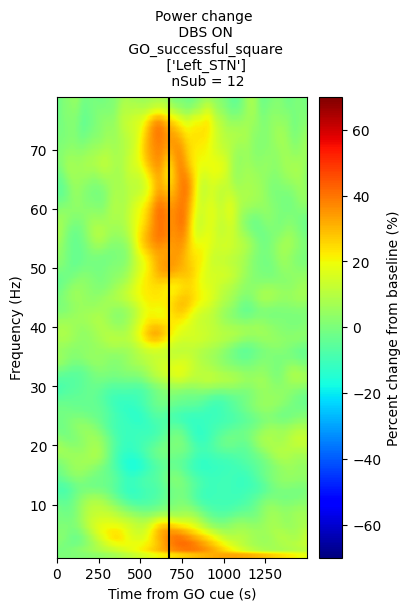

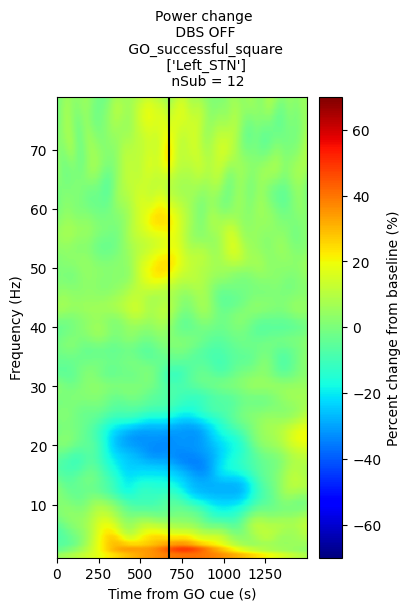

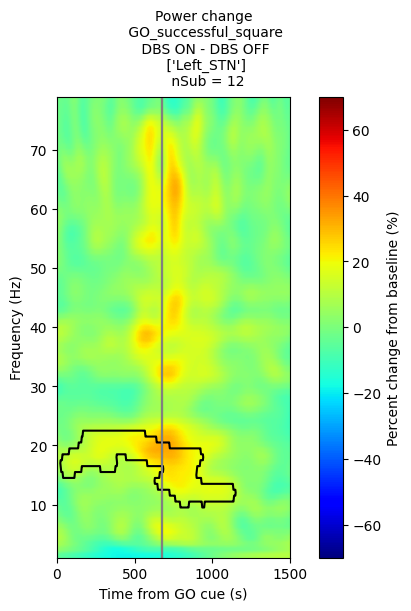

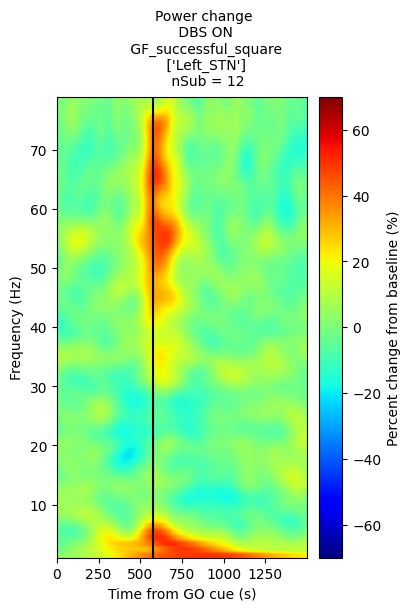

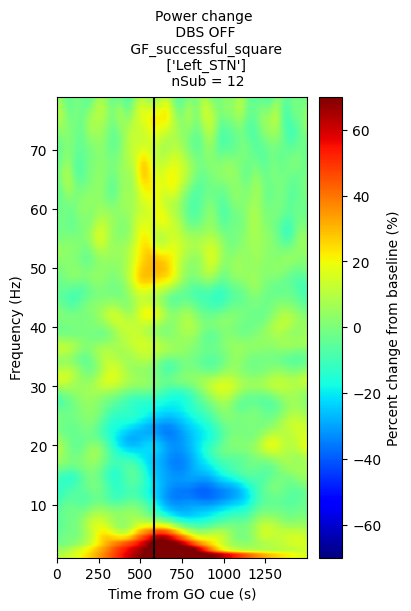

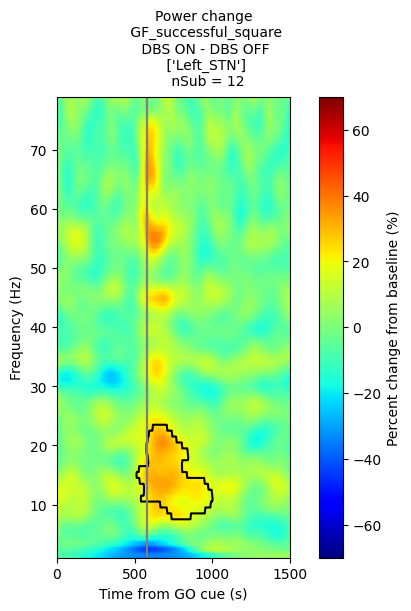

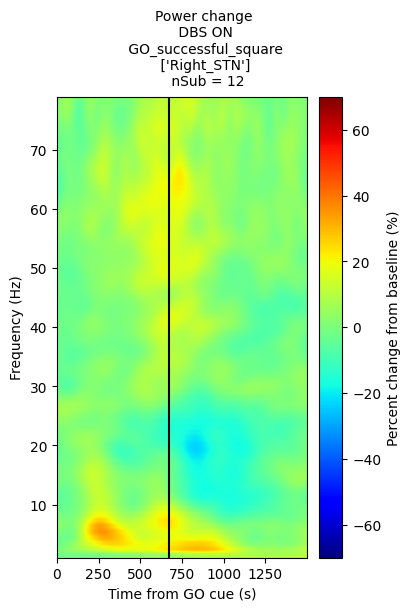

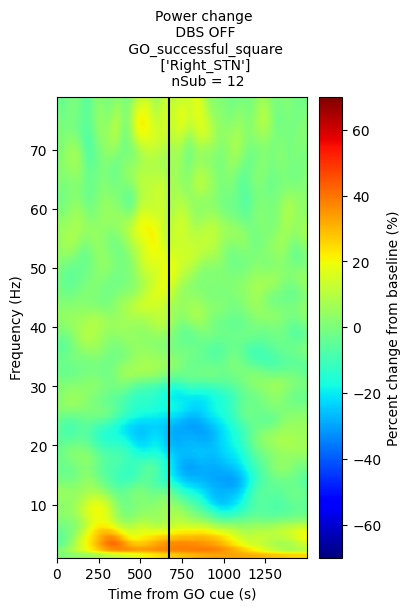

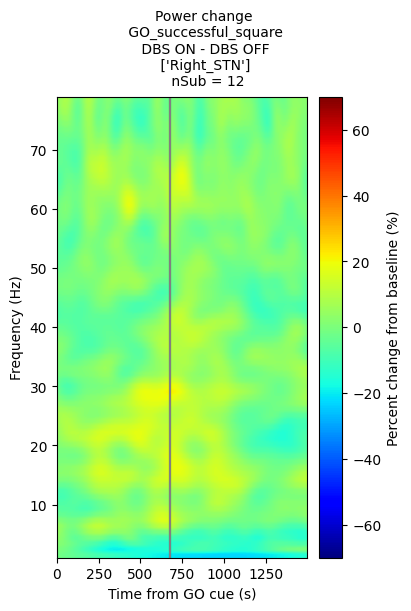

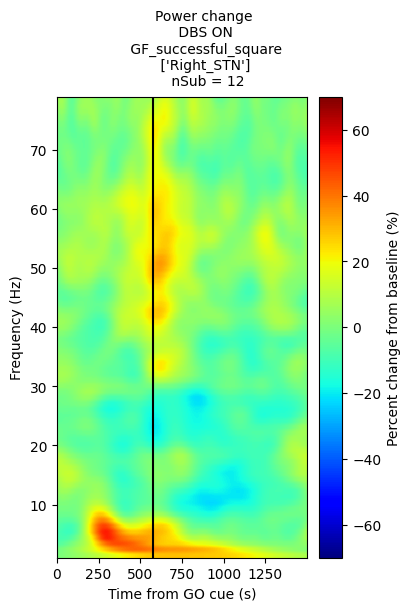

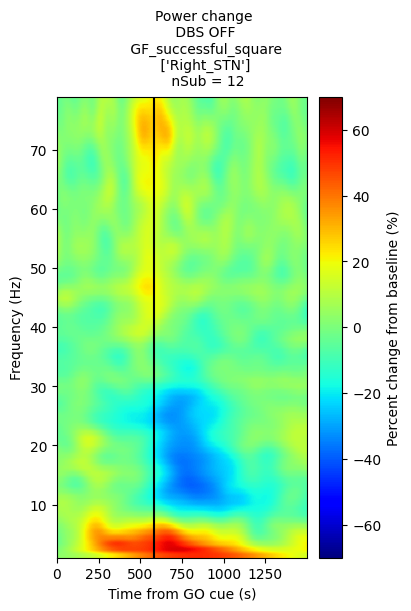

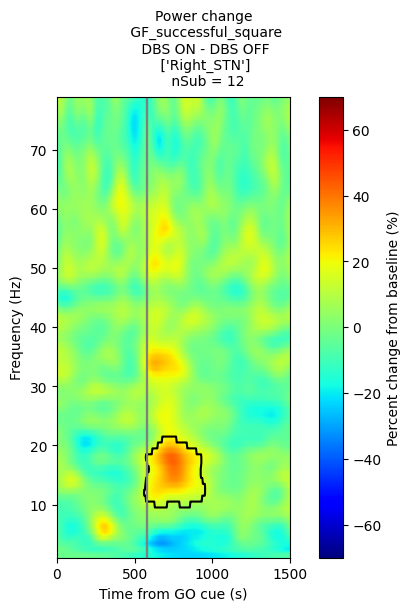

In [15]:
epochs_cond = [
    # 'GF_successful_response'
    # 'GC_successful_response',
    # 'GS_unsuccessful_response',
    'GO_successful_square',
    'GF_successful_square',
    # 'GC_successful_square',
    # 'GS_unsuccessful_square',
    # 'GS_successful_square',
    #  'GC_successful_triangle',
    # 'GS_unsuccessful_triangle',
    # 'GS_successful_triangle',
    #'GS_unsuccessful_feedback',
    # 'GS_unsuccessful_feedback',
    # 'GO_successful_feedback',
    # 'GF_successful_feedback'
    ]
# roi = ['Left_STN']

for roi in [['Left_STN'], ['Right_STN']]:
    tfr_dict = meta_function_tfr_inter_groups(
        tfr_dict = tfr_dict,
        groups = ['DBS ON', 'DBS OFF'],
        sub_dict_epochs = sub_dict_epochs,
        single_sub = False,
        epochs_cond = epochs_cond,
        roi = roi,
        tfr_args = tfr_args,
        tmin_tmax = [0, 1.5],
        plot_contrast_groups = True,
        plot_contrast_cond_group = False,
        plot_single_condition = True,
        vmin_vmax = vmin_vmax,
        baseline_correction = True,
        baseline_correction_method = baseline_correction_method,
        saving_path = "C:\\Users\\Juliette\\Research\\Projects\\analysis_mSST\\results\\test_meta_function",
        save_as='png'
        )


Processing subject sub006 DBS OFF mSST for condition slowGC_successful_square with threshold_GC = 321.7466000001878


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


Processing subject sub011 DBS OFF mSST for condition slowGC_successful_square with threshold_GC = 617.2914999187924


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


Processing subject sub012 DBS OFF mSST for condition slowGC_successful_square with threshold_GC = 443.6643000000273


...

Processing subject sub033 DBS ON mSST for condition lmGO_successful_square with threshold_GC = None


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    2.4s finished


9
9
Using a threshold of 2.306004
stat_fun(H1): min=-6.118253557958753 max=4.004675224170002
Running initial clustering …
Found 24 clusters


  0%|          | Permuting (exact test) : 0/255 [00:00<?,       ?it/s]

p_values: [0.5390625  1.         1.         1.         0.41796875 0.96484375
 1.         0.84765625 0.7109375  1.         1.         0.9140625
 1.         1.         1.         1.         1.         0.24609375
 1.         0.99609375 1.         0.98828125 1.         1.        ]
P_values shape: (24,)

No significant clusters found

Cluster results saved to C:\Users\Juliette\Research\Projects\analysis_mSST\results\grouped_lfp_results\Clusters excel\cluster_results_DBS ON_slowGC_successful_square - lmGO_successful_square_['Left_STN', 'Right_STN'].xlsx
Cluster results saved to C:\Users\Juliette\Research\Projects\analysis_mSST\results\grouped_lfp_results\Clusters csv\cluster_results_DBS ON_slowGC_successful_square - lmGO_successful_square_['Left_STN', 'Right_STN'].csv
vmin: -70, vmax: 70


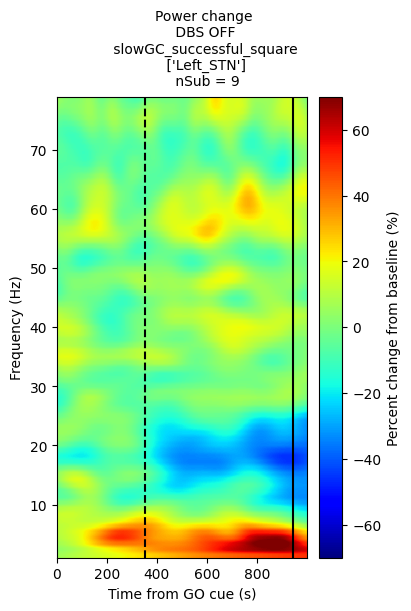

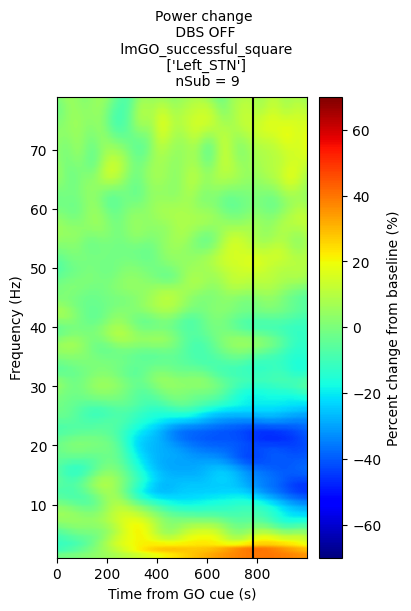

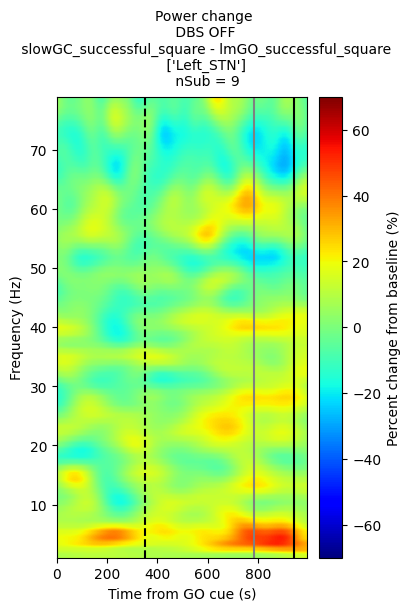

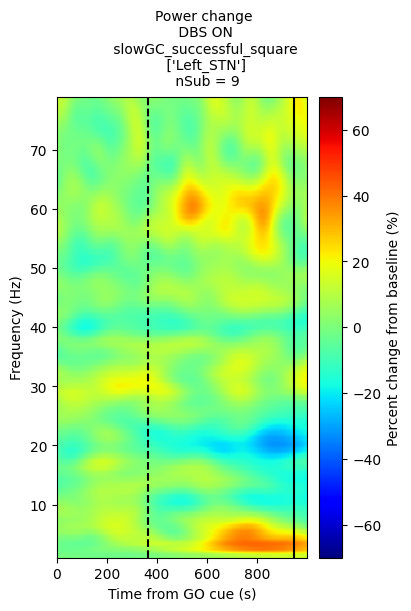

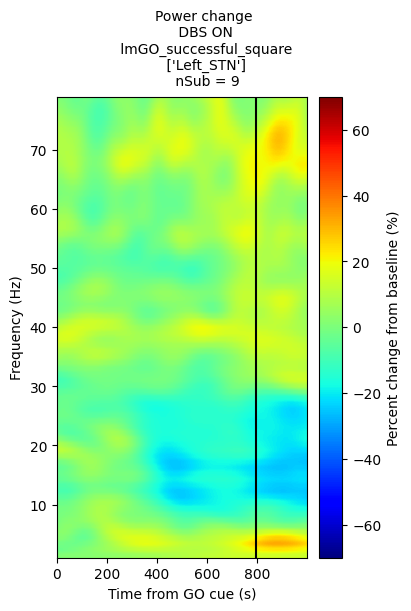

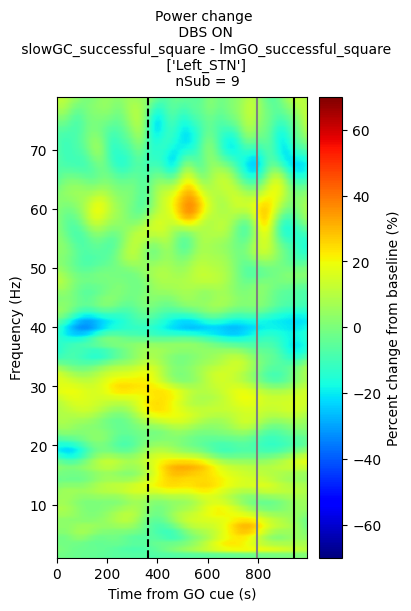

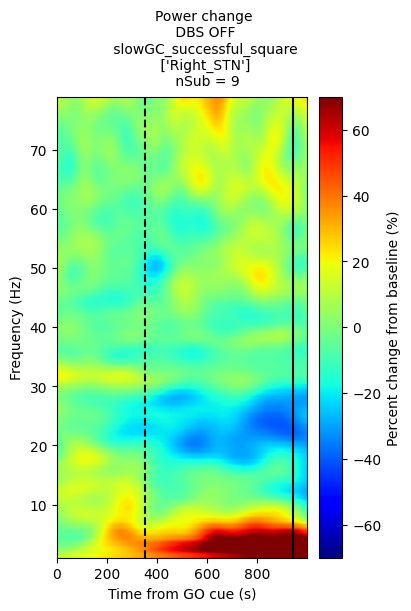

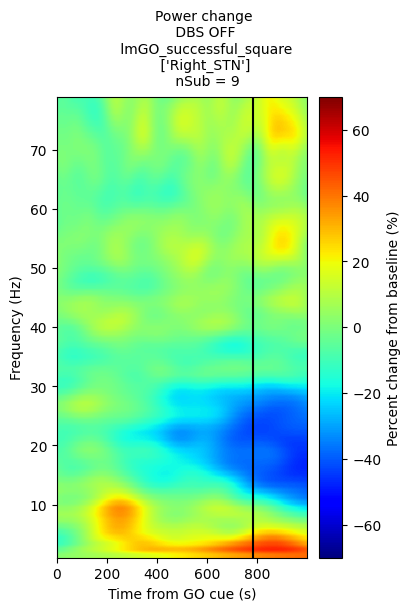

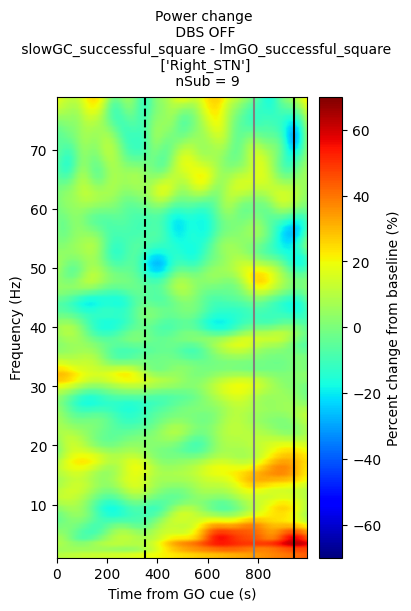

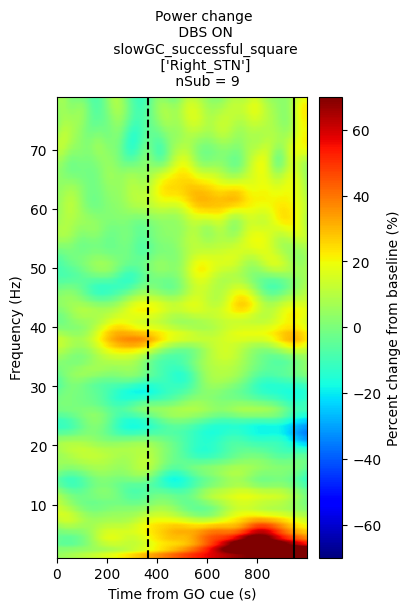

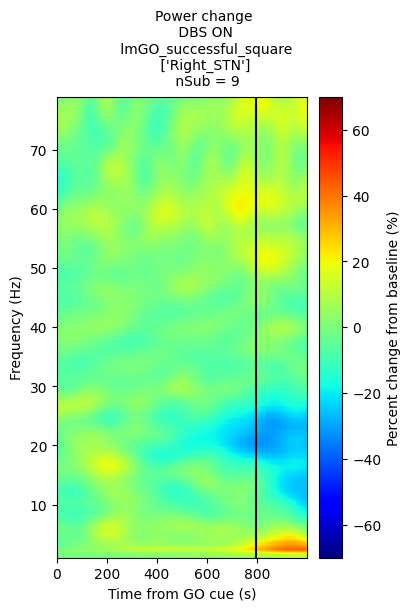

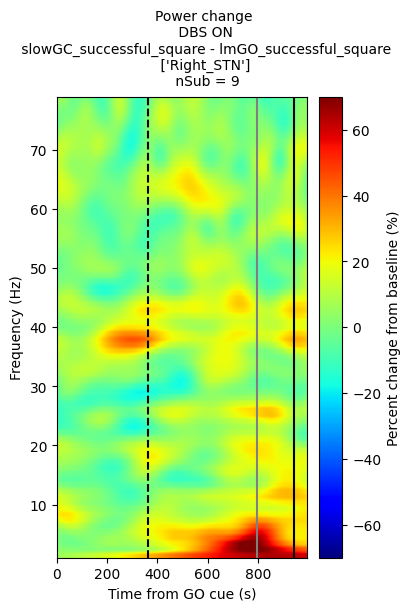

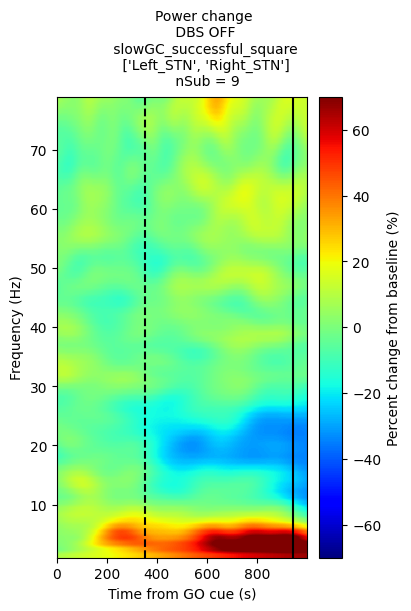

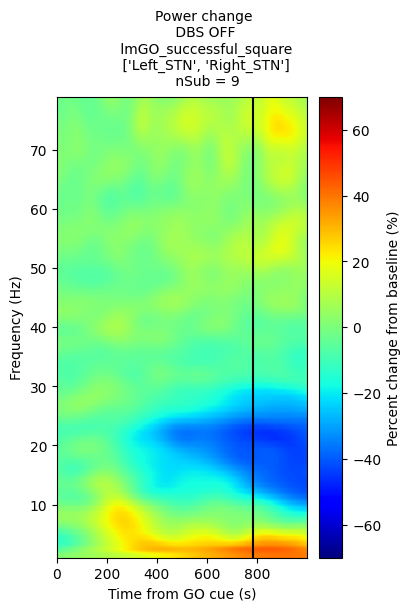

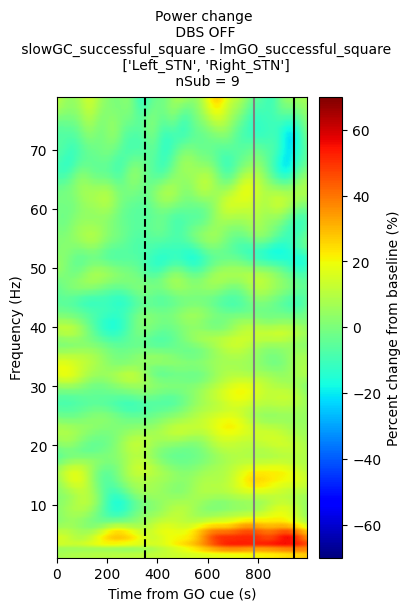

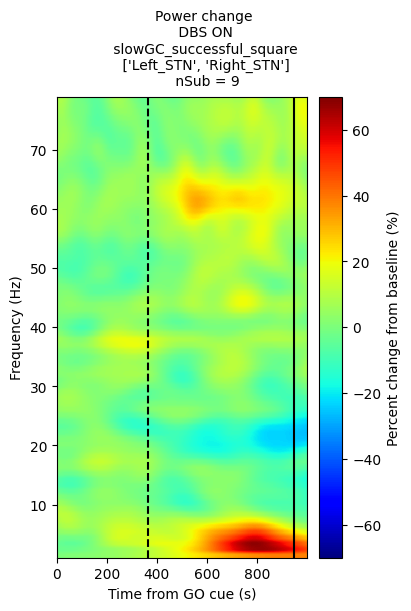

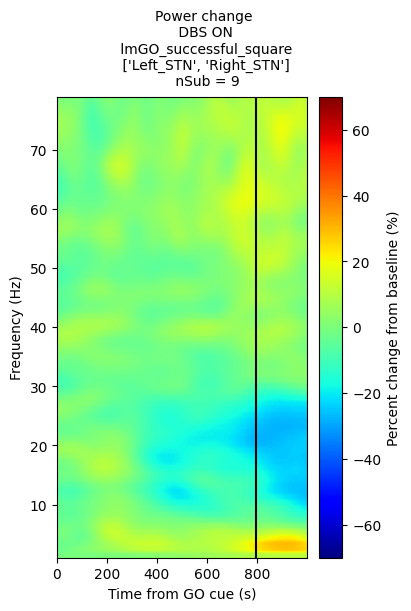

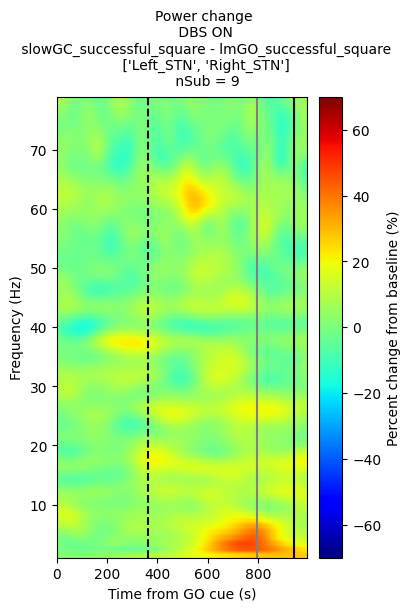

In [38]:
epochs_cond = [
    # 'GS_unsuccessful_triangle', 
    # 'slowGC_successful_triangle', 
    # 'fastGC_successful_triangle', 
    # 'GC_successful_response',
    # 'GS_unsuccessful_response',
    # 'GS_successful_square',
    'slowGC_successful_square',
    # 'GF_successful_square',
    'lmGO_successful_square',
    # 'GS_unsuccessful_square',
    # 'GC_successful_triangle',
    # 'GS_successful_triangle',    
    # 'GS_unsuccessful_triangle',
    # 'GS_successful_feedback',
    # 'GS_unsuccessful_feedback',
    # 'GO_successful_feedback',
    # 'GF_successful_feedback'
    ]
# roi = ['Left_STN']

for roi in [['Left_STN'], ['Right_STN'], ['Left_STN', 'Right_STN']]:
    for sub_group in ['DBS OFF', 'DBS ON']:
        tfr_dict = meta_function_tfr_intra_group(
            tfr_dict = tfr_dict,
            sub_group = sub_group,
            sub_dict_epochs = sub_dict_epochs,
            single_sub = False,
            epochs_cond = epochs_cond,
            roi = roi,
            tfr_args = tfr_args,
            tmin_tmax = [0, 1],
            plot_contrast = True,
            plot_single_condition = True,
            vmin_vmax = vmin_vmax,
            baseline_correction = True,
            baseline_correction_method = baseline_correction_method,
            saving_path = "C:\\Users\\Juliette\\Research\\Projects\\analysis_mSST\\results\\grouped_lfp_results",
            save_as='png',
            threshold_gc_dict = threshold_gc_dict
            )

# epochs_cond = ['GC_successful_square']
# # roi = ['Left_STN']

# meta_function_tfr(
#     sub_groups = ['DBS OFF'],
#     sub_dict_epochs = sub_dict_epochs,
#     single_sub = False,
#     epochs_cond = epochs_cond,
#     roi = roi,
#     tfr_args = tfr_args,
#     tmin_tmax = [0, 1.5],
#     )

# epochs_cond = ['GF_successful_square']
# roi = ['Right_STN']

# meta_function_tfr(
#     sub_groups = ['DBS OFF'],
#     sub_dict_epochs = sub_dict_epochs,
#     single_sub = False,
#     epochs_cond = epochs_cond,
#     roi = roi,
#     tfr_args = tfr_args,
#     tmin_tmax = [-0.5, 1.5],                                                                                                                                                      
#     )

Processing group DBS OFF, roi Left_STN, conditions ['GO_successful_square', 'GF_successful_square']


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.8s finished


9


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished


9
9
Using a threshold of 2.306004
stat_fun(H1): min=-4.923303038258621 max=6.239522352531165
Running initial clustering …
Found 26 clusters


...

9


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished


9
9
Using a threshold of 2.306004
stat_fun(H1): min=-4.146044623866278 max=4.214888124097789
Running initial clustering …
Found 20 clusters


  0%|          | Permuting (exact test) : 0/255 [00:00<?,       ?it/s]

p_values: [0.97265625 1.         0.98828125 1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.125      1.         0.9765625  1.         1.
 1.         1.        ]
P_values shape: (20,)

No significant clusters found

Cluster results saved to C:\Users\Juliette\Research\Projects\analysis_mSST\results\test_meta_function\Clusters excel\cluster_results_DBS ON_GO_successful_square - GF_successful_square_['Right_STN'].xlsx
Cluster results saved to C:\Users\Juliette\Research\Projects\analysis_mSST\results\test_meta_function\Clusters csv\cluster_results_DBS ON_GO_successful_square - GF_successful_square_['Right_STN'].csv
vmin: -70, vmax: 70


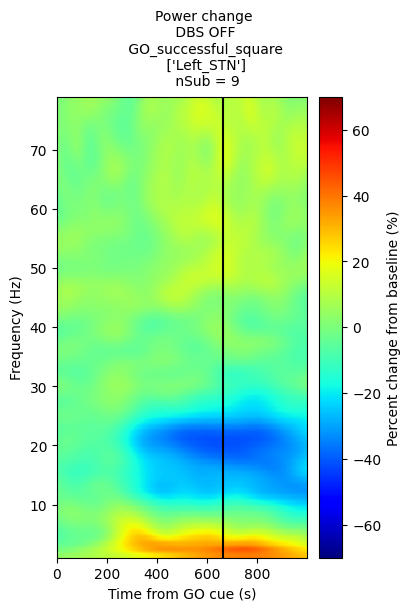

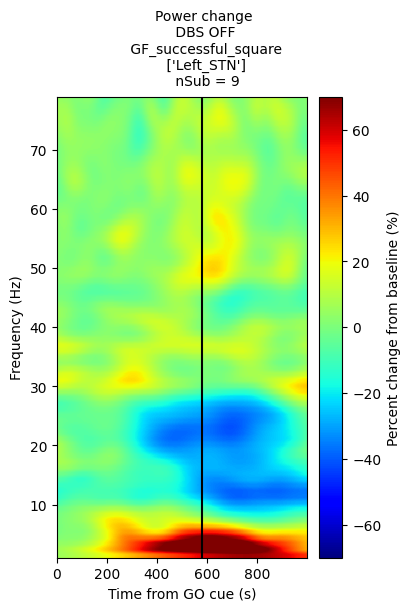

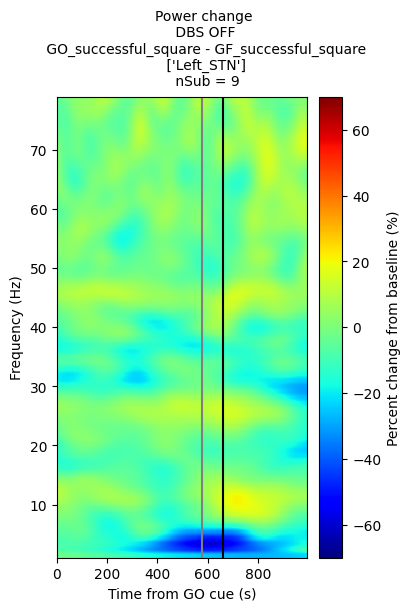

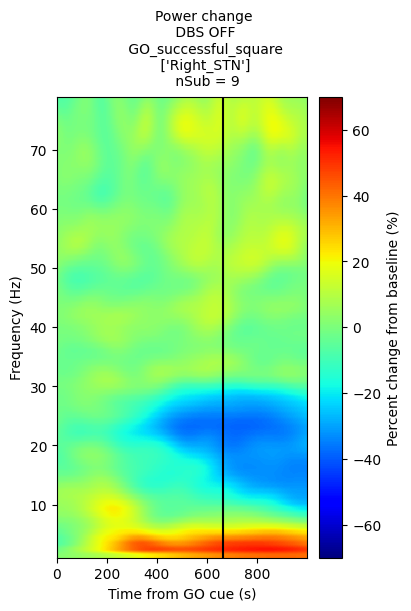

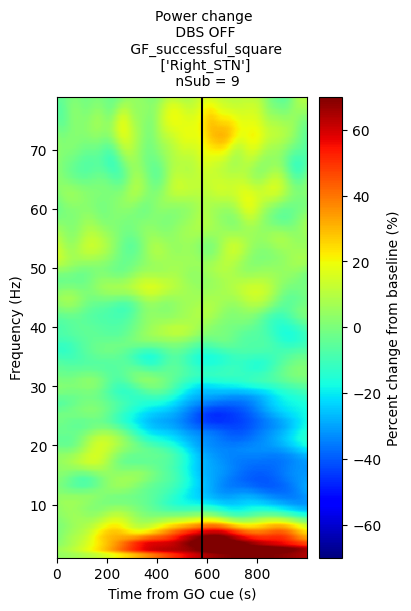

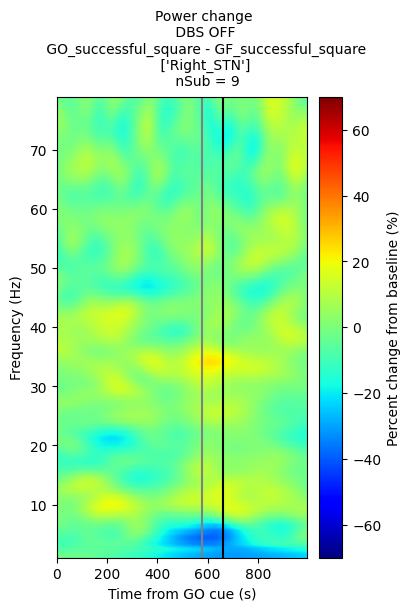

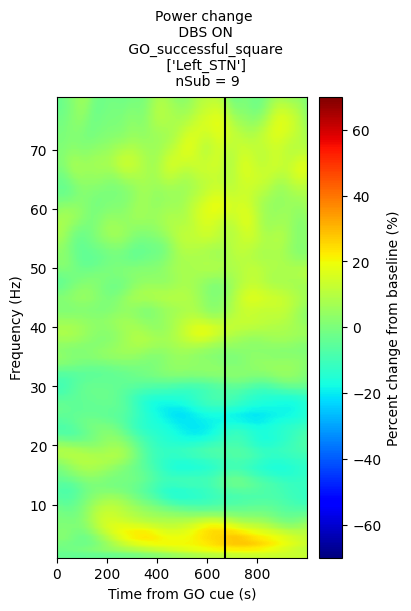

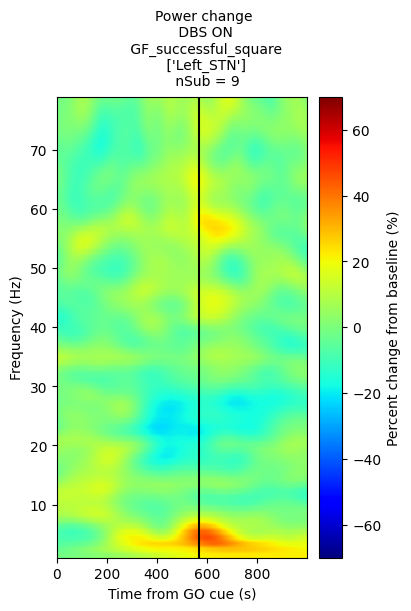

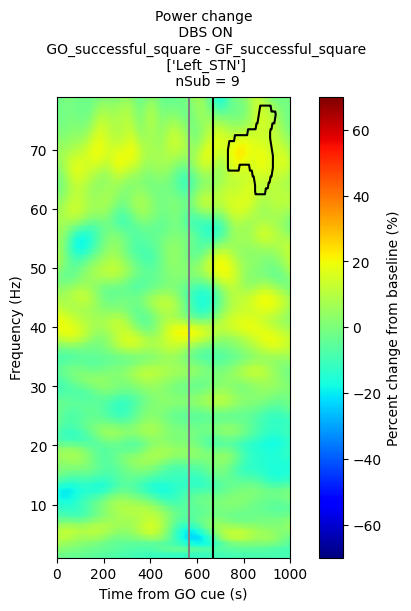

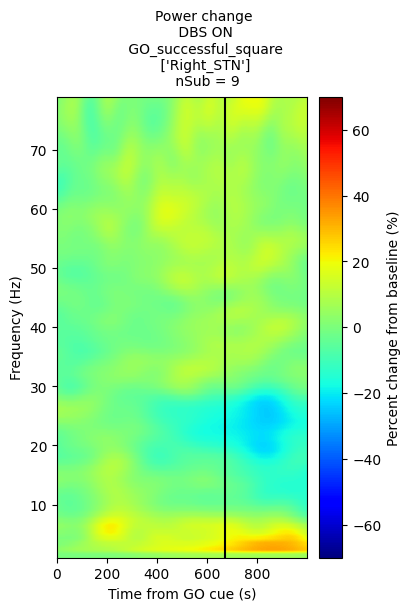

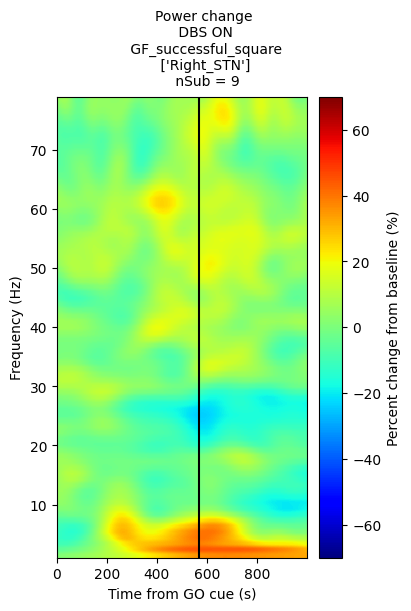

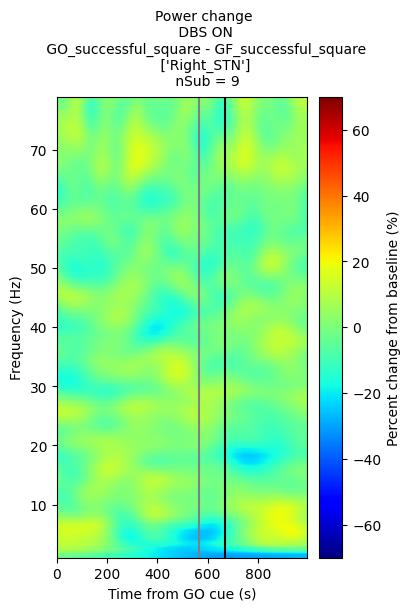

In [54]:
epochs_cond = [
    # 'GS_successful_triangle', 
    # 'GC_successful_triangle', 
    # 'GC_successful_response',
    # 'GS_unsuccessful_response',
    # 'GS_successful_square',
    # 'lmGO_successful_square',
    'GO_successful_square',
    'GF_successful_square',
    # 'GC_successful_square',
    # 'GS_unsuccessful_square',
    # 'GC_successful_triangle',
    # 'GS_unsuccessful_triangle',
    # 'GS_successful_triangle',
    # 'GS_successful_feedback',
    # 'GS_unsuccessful_feedback',
    # 'GO_successful_feedback',
    # 'GF_successful_feedback'
    ]
# roi = ['Left_STN']

for sub_group in ['DBS OFF', 'DBS ON']:
    for roi in [['Left_STN'], ['Right_STN']]:
        print(f"Processing group {sub_group}, roi {roi[0]}, conditions {epochs_cond}")
        tfr_dict = meta_function_tfr_intra_group(
            tfr_dict = tfr_dict,
            sub_group = sub_group,
            sub_dict_epochs = sub_dict_epochs,
            single_sub = False,
            epochs_cond = epochs_cond,
            roi = roi,
            tfr_args = tfr_args,
            tmin_tmax = [0, 1],
            plot_contrast = True,
            plot_single_condition = True,
            vmin_vmax = vmin_vmax,
            baseline_correction = True,
            baseline_correction_method = baseline_correction_method,
            saving_path = "C:\\Users\\Juliette\\Research\\Projects\\analysis_mSST\\results\\test_meta_function",
            save_as='png'
            )


In [56]:
tfr_dict['DBS ON']['GF_successful_square'].keys()

dict_keys(['all_percentage_change', 'Right_STN', 'mean_rt_all', 'mean_ssd_all', 'times', 'freqs'])

In [15]:
tfr_dict['DBS OFF']['lmGO_successful_square']['mean_rt_all']

[0.7465713189189188,
 0.8410149271805825,
 0.8302083392411215,
 0.7811460046593024,
 0.6791048586639999,
 0.7169814767136986,
 0.7033109000000001,
 0.7708806566156627,
 0.89862692]

ERP

In [30]:
# =========================
# FULL ERP PIPELINE – ONE CELL (WITH COMPARISON PLOT)
# =========================

import os
import numpy as np
import matplotlib.pyplot as plt
import mne

def get_erp_decomposition(
        epochs,
        cond_of_interest,
        ch_names,
        baseline_correction=True,
        tmin_tmax=[-0.2, 0.8]
):
    """
    Returns average ERP for one subject, one condition, one ROI
    """

    # ---- Parse condition ----
    epoch_type, outcome_str, aligned_str = cond_of_interest.split('_')
    outcome = 1.0 if outcome_str == "successful" else 0.0

    # ---- Select epochs ----
    type_mask = epochs.metadata["event"] == epoch_type
    outcome_mask = epochs.metadata["key_resp_experiment.corr"] == outcome
    data = epochs[type_mask & outcome_mask]

    if len(data) == 0:
        return None, None, None, None

    # ---- RT / SSD ----
    rt = np.asarray(data.metadata['key_resp_experiment.rt'])
    mean_rt = np.nanmean(rt) if np.any(~np.isnan(rt)) else None

    ssd = None
    if epoch_type == 'GS':
        ssd = np.asarray(data.metadata['stop_signal_time'])
    elif epoch_type == 'GC':
        ssd = np.asarray(data.metadata['continue_signal_time'])
    mean_ssd = np.nanmean(ssd) if ssd is not None else None

    # ---- Pick channels ----
    data = data.copy().pick(ch_names)

    # ---- ERP data ----
    # shape: (n_epochs, n_channels, n_times)
    X = data.get_data() * 1e6  # V → µV

    # average over channels
    X = np.nanmean(X, axis=1)  # (n_epochs, n_times)

    # average over trials
    erp = np.nanmean(X, axis=0)  # (n_times,)

    times = data.times * 1000  # ms

    # ---- Baseline correction FIRST ----
    if baseline_correction:
        bmask = (times >= -200) & (times <= 0)
        if np.any(bmask):
            baseline = np.nanmean(erp[bmask])
            erp = erp - baseline
        else:
            # fail silently but safely
            erp = erp * np.nan

    # ---- Crop AFTER baseline ----
    tmask = (times >= tmin_tmax[0] * 1000) & (times <= tmin_tmax[1] * 1000)
    erp = erp[tmask]
    times = times[tmask]

    # # ---- Crop ----
    # tmask = (times >= tmin_tmax[0] * 1000) & (times <= tmin_tmax[1] * 1000)
    # erp = erp[tmask]
    # times = times[tmask]

    # # ---- Baseline correction ----
    # if baseline_correction:
    #     bmask = (times >= -200) & (times <= 0)
    #     baseline = np.nanmean(erp[bmask])
    #     erp = erp - baseline

    return erp, times, mean_rt, mean_ssd


# ------------------------------
# Single-condition ERP plot (with RT)
# ------------------------------
# ------------------------------
# Single-condition ERP plot (with RT line)
# ------------------------------
def plot_erp_result(
        group,
        all_erps,
        times,
        epochs_cond,
        roi,
        sub_num,
        saving_path,
        mean_rt_all=None,
        save_as='png'
):

    avg = np.nanmean(all_erps, axis=0)
    sem = np.nanstd(all_erps, axis=0) / np.sqrt(all_erps.shape[0])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(times, avg, label=epochs_cond)
    ax.fill_between(times, avg - sem, avg + sem, alpha=0.3)

    # Event lines
    ax.axvline(0, color='red', linestyle='--', label='Cue')
    
    # Mean RT line
    if mean_rt_all is not None and len(mean_rt_all) > 0:
        mean_rt = np.nanmean(mean_rt_all)
        ax.axvline(mean_rt*1000, color='blue', linestyle='--', label=f'Mean RT ({mean_rt:.1f} ms)')

    ax.axhline(0, color='gray', linestyle=':')

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title(f"{group} | {epochs_cond} | {roi} | n={sub_num}")
    ax.legend()

    os.makedirs(saving_path, exist_ok=True)
    fig.savefig(
        os.path.join(saving_path, f"{group}_{epochs_cond}_{roi}_ERP.{save_as}"),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close(fig)


# ------------------------------
# Comparison plot (two conditions, with RT lines)
# ------------------------------
def plot_erp_comparison(
        group,
        erp_dict,
        times,
        roi,
        sub_num,
        mean_rt_dict=None,
        saving_path=None,
        save_as='png'
):
    fig, ax = plt.subplots(figsize=(6, 4))

    colors = ['black', 'green']  # adjust for two conditions
    for i, (cond, all_erps) in enumerate(erp_dict.items()):
        avg = np.nanmean(all_erps, axis=0)
        sem = np.nanstd(all_erps, axis=0) / np.sqrt(all_erps.shape[0])

        ax.plot(times, avg, color=colors[i], label=cond)
        ax.fill_between(times, avg - sem, avg + sem, alpha=0.25, color=colors[i])

        # Mean RT line per condition
        if mean_rt_dict is not None and cond in mean_rt_dict and len(mean_rt_dict[cond]) > 0:
            mean_rt = np.nanmean(mean_rt_dict[cond])
            ax.axvline(mean_rt*1000, color=colors[i], linestyle='--', alpha=0.7,
                       label=f'{cond} Mean RT ({mean_rt:.1f} ms)')

    ax.axvline(0, color='red', linestyle='--', label='Cue')
    ax.axhline(0, color='gray', linestyle=':')

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title(f"{group} | {roi} | n={sub_num}")
    ax.legend()

    os.makedirs(saving_path, exist_ok=True)
    fig.savefig(
        os.path.join(saving_path, f"{group}_ERP_COMPARISON_{roi}.{save_as}"),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close(fig)


def meta_function_erp_intra_group(
        tfr_dict,
        sub_group,
        sub_dict_epochs,
        single_sub,
        epochs_cond,
        roi,
        tmin_tmax,
        plot_single_condition,
        baseline_correction,
        saving_path,
        save_as='png'
):

    if sub_group not in tfr_dict:
        tfr_dict[sub_group] = {}

    comparison_store = {}
    mean_rt_store = {}

    group_key = sub_group if 'DBS' in sub_group else 'C'
    selected_epochs = {
        k: v for k, v in sub_dict_epochs.items() if group_key in k
    }

    for coi in epochs_cond:

        all_erps = []
        subs = []
        mean_rt_all = []

        for sub, epochs in selected_epochs.items():

            erp, times, mean_rt, _ = get_erp_decomposition(
                epochs,
                coi,
                roi,
                baseline_correction,
                tmin_tmax
            )

            if erp is None:
                continue

            all_erps.append(erp)
            subs.append(sub)
            mean_rt_all.append(mean_rt)

        if len(all_erps) == 0:
            continue

        min_len = min(e.shape[0] for e in all_erps)
        all_erps = np.stack([e[:min_len] for e in all_erps])
        times = times[:min_len]

        sub_num = len(subs)

        if plot_single_condition:
            plot_erp_result(
                sub_group,
                all_erps,
                times,
                coi,
                roi,
                sub_num,
                saving_path,
                mean_rt_all=mean_rt_all,
                save_as=save_as
            )

        tfr_dict[sub_group][coi] = {
            'all_erps': all_erps,
            'times': times,
            'mean_rt_all': mean_rt_all
        }

        comparison_store[coi] = all_erps
        mean_rt_store[coi] = mean_rt_all

    # ---- COMPARISON PLOT ----
    if len(comparison_store) == 2:
        plot_erp_comparison(
            group=sub_group,
            erp_dict=comparison_store,
            times=times,
            roi=roi,
            sub_num=sub_num,
            mean_rt_dict=mean_rt_store,
            saving_path=saving_path,
            save_as=save_as
        )

    return tfr_dict


In [32]:
epochs_cond = [
    #'GS_successful_feedback', 
    #'GS_unsuccessful_feedback', 
    # 'GC_successful_response',
    # 'GS_unsuccessful_response',
    # 'GF_successful_square',
    # 'GC_successful_square',
    # 'GS_unsuccessful_square',
    'GO_successful_square',
    'GC_successful_square',
    # 'GO_successful_square',
    # 'GC_successful_triangle',
    # 'GS_unsuccessful_triangle',
    # 'GS_successful_triangle',
    # 'GS_successful_feedback',
    # 'GS_unsuccessful_feedback',
    # 'GO_successful_feedback',
    # 'GF_successful_feedback'
    ]
# roi = ['Left_STN']

for sub_group in ['DBS OFF', 'DBS ON']:
    tfr_dict = meta_function_erp_intra_group(
        tfr_dict = tfr_dict,
        sub_group = sub_group,
        sub_dict_epochs = sub_dict_epochs,
        single_sub = False,
        epochs_cond = epochs_cond,
        roi = ['Left_STN'],
        tmin_tmax = [0, 1],
        plot_single_condition = True,
        baseline_correction = True,
        saving_path = "C:\\Users\\Juliette\\OneDrive\\Images\\images for figures\\poster\\eeg\\erp",
        save_as='pdf'
        )

C:\Users\Juliette\AppData\Local\Temp\ipykernel_25756\2282607046.py:52: RuntimeWarning: Mean of empty slice
  X = np.nanmean(X, axis=1)  # (n_epochs, n_times)
C:\Users\Juliette\AppData\Local\Temp\ipykernel_25756\2282607046.py:52: RuntimeWarning: Mean of empty slice
  X = np.nanmean(X, axis=1)  # (n_epochs, n_times)
C:\Users\Juliette\AppData\Local\Temp\ipykernel_25756\2282607046.py:52: RuntimeWarning: Mean of empty slice
  X = np.nanmean(X, axis=1)  # (n_epochs, n_times)
C:\Users\Juliette\AppData\Local\Temp\ipykernel_25756\2282607046.py:52: RuntimeWarning: Mean of empty slice
  X = np.nanmean(X, axis=1)  # (n_epochs, n_times)


# 3. Work with epochs #

Each epoch is baseline corrected separately (single-trial baseline correction) using dB normalization. 

## Why?## 
Because when epochs are aligned on the STOP or CONTINU signals, then the baseline period is not always the same (because the SSD varies from trial to trial). Therefore, each epoch has to be corrected separately.

## How? ## 
dB normalization is used. Previously, "percent change from baseline" was used but in Hu et al., 2014, it is showed that this method is only good when baseline correction is applied on averaged epochs, and should be avoided when the correction is applied at the single trial level. They recomment the subtraction method, but this method is also not suited when we then want to perform group analysis, because it is very dependent on the baseline levels of power, which can be very different from one patient to another 

## cf ChatGPT: Why subtraction can be problematic across subjects: ##
Subtraction (power − baseline) preserves the original units (e.g., (µV)²). Different subjects often have very different absolute power levels (different baselines, scalp impedance, electrode coupling, sensor placement, intrinsic amplitude). If you average these absolute differences across subjects, subjects with larger absolute power will dominate the group mean.
Relative normalizations (percent change, dB, or z-score) produce unitless values that place subjects on the same scale and are much safer for group averages and group statistics.

Recommended pipelines (practical):
    Recommendation A — preferred for most TF analyses:
        1. Compute baseline for each trial (baseline mean and — optionally — baseline std if you want z-scores).
        2. Normalize per trial to a unitless measure:
            Percent change: pc = (power - baseline) / baseline * 100
            dB: db = 10 * np.log10(power / baseline) (or 20*log10 if using amplitudes, but for power use 10)
            Z-score: z = (power - baseline_mean) / baseline_std
        3. Average normalized trials within each subject → subject-level TFR.
        4. Average subject-level TFRs across subjects (or run subject-level stats).

    Why: relative or z-scored measures control for between-subject scaling and variance.

    Recommendation B — when subtraction may be acceptable:
        If you have strong reasons to keep absolute changes (e.g., comparing absolute energy in identical recording setups and sensors, and you’ve confirmed baselines are comparable), you can:
            1. Subtract baseline at the single-trial level,
            2. Average trials per subject,
            3. Then average subjects.

    But always check subject baseline distributions (plot baseline means) and consider adding a normalization if they spread widely.



## 3.1. Set the parameters for the plots ## 

In [ ]:
saving_path_group

In [6]:
######################
### TFR PARAMETERS ###
######################

# decim = 1 
# freqs = np.arange(1, 40, 1) 
# n_cycles = np.minimum(np.maximum(freqs / 2.0, 3), 20)
# tfr_args = dict(
#     method="morlet",
#     freqs=freqs,
#     n_cycles=n_cycles,
#     decim=decim,
#     return_itc=False,
#     average=False
# )        

# tmin_tmax = [-500, 1500]
# vmin_vmax = [-70, 70]

######################
### TFR PARAMETERS ###
######################

decim = 1 
fmin_freq = fmin if fmin is not None else 1
#freqs = np.arange(fmin_freq, fmax, 1) 
freqs = np.arange(fmin_freq, 80, 1)
# For 500ms time resolution at 1 Hz: n_cycles = 1 * 0.5 = 0.5
# For 50ms time resolution at 40 Hz: n_cycles = 40 * 0.05 = 2
# Linear interpolation between these points
#n_cycles = 0.5 + (freqs - 1) * (2 - 0.5) / (40 - 1)
#n_cycles = freqs / 2.0
n_cycles = np.minimum(np.maximum(freqs / 2.0, 2), 20)

tfr_args = dict(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    decim=decim,
    return_itc=False,
    average=False
)        

baseline_correction_method = 'group_average' # 'group_average' or 'single_trial'
tmin_tmax = [0, 1500]
vmin_vmax = [-5, 5] if baseline_correction_method == 'single_trial' else [-70, 70]

sub_nums = []  #  List to store unique subject numbers

for sub in included_subjects:
    sub = sub[:6]
    if sub not in sub_nums:  # Check if sub is already in sub_nums
        sub_nums.append(sub)

## 3.2. Plot power changes at the single-subject level ##

### 3.2.1. Plot the mean signal per channel and trial type ###

In [ ]:
%matplotlib inline
#  Plot power change for each single subject and each condition/trial type
for sub in sub_nums:
#for sub in ['sub032 DBS ON mSST']:
    print(f"Now processing sub: {sub}")
    single_sub_dict_subsets = {key: value for key, value in sub_dict_epochs.items() if sub in key}
    print(single_sub_dict_subsets.keys())
    saving_path_single = join(results_path, 'single_sub', f'{sub} mSST','lfp_perc_sig_change', freq_wide)
    os.makedirs(saving_path_single, exist_ok=True)  # Create the directory if it doesn't exist

    ## single condition            
    for dbs_status in [
        'DBS OFF', 
        'DBS ON'
        ]:
        if any(dbs_status in key for key in single_sub_dict_subsets.keys()):
            for cond in [
                'GO_successful', 
                'lm_GO_successful',
                # # #'GO_unsuccessful', 
                'GF_successful', 
                # # #'GF_unsuccessful',
                'GC_successful', 
                # # #'GC_unsuccessful',
                'GS_successful', 
                'GS_unsuccessful',
                 'stop_successful',
                 'stop_unsuccessful',
                'continue_successful'
                ]:
                ephy_plotting.tfr_pow_change_cond(
                    sub_dict = single_sub_dict_subsets, 
                    dbs_status = dbs_status, 
                    epoch_cond = cond,
                    tfr_args = tfr_args, 
                    t_min_max = tmin_tmax, 
                    vmin_vmax = vmin_vmax,
                    baseline_correction=True,
                    saving_path=saving_path_single,
                    show_fig=True,
                    save_as = 'png',
                    baseline_correction_method=baseline_correction_method
                    )
            

### 3.2.2 Plot the power change contrasting different trial types ###

In [ ]:
#  Plot power change for different constrasts, for each single subject and each condition/trial type
#  Contrasts of interest are:
#       - GS_successful - GO_successful  --> reactive inhibition contrast
#       - GO_successful - GF_successful  --> proactive inhibition contrast
#       - GS_successful - GS_unsuccessful  --> stopping contrast
#       - STOP_successful - STOP_unsuccessful --> stopping contrast but aligned to the STOP cue
#       - STOP_successful - CONTINUE_successful --> attentional contrast aligned to the unexpected stimuli

for sub in sub_nums:
    print(f"Now processing sub: {sub}")
    single_sub_dict_subsets = {key: value for key, value in sub_dict_epochs.items() if sub in key}
    print(single_sub_dict_subsets.keys())
    saving_path_single = join(results_path, 'single_sub', f'{sub} mSST','lfp_perc_sig_change', freq_wide)
    os.makedirs(saving_path_single, exist_ok=True)  # Create the directory if it doesn't exist

    ## difference conditions          
    for dbs_status in ['DBS OFF', 'DBS ON']:
        if any(dbs_status in key for key in single_sub_dict_subsets.keys()):
            condition = f"{dbs_status} GS_successful - GO_successful {sub}"
            ephy_plotting.perc_pow_diff_cond(
                            sub_dict = single_sub_dict_subsets,  
                            dbs_status = dbs_status,  
                            tfr_args = tfr_args, 
                            t_min_max = tmin_tmax, 
                            vmin_vmax = vmin_vmax,
                            epoch_cond1 = "GS_successful",
                            epoch_cond2 = "GO_successful",
                            condition = condition,
                            saving_path = saving_path_single,
                            show_fig = True,
                            add_rt = True,
                            baseline_correction_method=baseline_correction_method

                            )
            condition = f"{dbs_status} GS_successful - latency-matched GO_successful {sub}"
            ephy_plotting.perc_pow_diff_cond(
                            sub_dict = single_sub_dict_subsets,  
                            dbs_status = dbs_status,  
                            tfr_args = tfr_args, 
                            t_min_max = tmin_tmax, 
                            vmin_vmax = vmin_vmax,
                            epoch_cond1 = "GS_successful",
                            epoch_cond2 = "lm_GO_successful",
                            condition = condition,
                            saving_path = saving_path_single,
                            show_fig = True,
                            add_rt = True,
                            baseline_correction_method=baseline_correction_method
                            )
            

            condition = f"{dbs_status} GO_successful - GF_successful {sub}"
            ephy_plotting.perc_pow_diff_cond(
                            sub_dict = single_sub_dict_subsets,  
                            dbs_status = dbs_status,  
                            tfr_args = tfr_args, 
                            t_min_max = tmin_tmax, 
                            vmin_vmax = vmin_vmax,
                            epoch_cond1 = "GO_successful",
                            epoch_cond2 = "GF_successful",
                            condition = condition,
                            saving_path = saving_path_single,
                            show_fig = True,
                            add_rt = True,
                            baseline_correction_method=baseline_correction_method
                            )
            condition = f"{dbs_status} GS_successful - GS_unsuccessful {sub}"
            ephy_plotting.perc_pow_diff_cond(
                            sub_dict = single_sub_dict_subsets,  
                            dbs_status = dbs_status,  
                            tfr_args = tfr_args, 
                            t_min_max = tmin_tmax,
                            vmin_vmax = vmin_vmax,
                            epoch_cond1 = "GS_successful",
                            epoch_cond2 = "GS_unsuccessful",
                            condition = condition,
                            saving_path = saving_path_single,
                            show_fig = True,
                            add_rt = True,
                            baseline_correction_method=baseline_correction_method
                            )
            condition = f"{dbs_status} stop_successful - stop_unsuccessful {sub}"
            ephy_plotting.perc_pow_diff_cond(
                            sub_dict = single_sub_dict_subsets,  
                            dbs_status = dbs_status,  
                            tfr_args = tfr_args, 
                            t_min_max = tmin_tmax, 
                            vmin_vmax = vmin_vmax,
                            epoch_cond1 = "stop_successful",
                            epoch_cond2 = "stop_unsuccessful",
                            condition = condition,
                            saving_path = saving_path_single,
                            show_fig = True,
                            add_rt = True,
                            baseline_correction_method=baseline_correction_method
                            )
            condition = f"{dbs_status} stop_successful - continue_successful {sub}"
            ephy_plotting.perc_pow_diff_cond(
                            sub_dict = single_sub_dict_subsets,  
                            dbs_status = dbs_status,  
                            tfr_args = tfr_args, 
                            t_min_max = tmin_tmax, 
                            vmin_vmax = vmin_vmax,
                            epoch_cond1 = "stop_successful",
                            epoch_cond2 = "continue_successful",
                            condition = condition,
                            saving_path = saving_path_single,
                            show_fig = True,
                            add_rt = True,
                            baseline_correction_method=baseline_correction_method
                            )

## 3.3. Plot power changes at the group level ##

### 3.3.1. Plot average power changes for each trial type ###

In [ ]:
# vmin_vmax=[-5, 5] 
vmin_vmax = [-5, 5] if baseline_correction_method == 'single_trial' else [-70, 70]
for dbs_status in [
    'DBS OFF', 
    'DBS ON'
    ]:                
    for cond in [
        'GO_successful', 
        'lm_GO_successful',
        #'GO_unsuccessful', 
        'GF_successful', 
        #'GF_unsuccessful',
        'GC_successful', 
        #'GC_unsuccessful',
        'GS_successful', 
        'GS_unsuccessful',
        'stop_successful',
        'stop_unsuccessful',
        'continue_successful'
        ]:
        print(f"Now processing: {dbs_status} - {cond} ")
        ephy_plotting.tfr_pow_change_cond(
                    sub_dict = sub_dict_epochs, 
                    dbs_status = dbs_status, 
                    epoch_cond = cond, 
                    tfr_args = tfr_args, 
                    t_min_max = tmin_tmax, 
                    vmin_vmax = vmin_vmax,
                    baseline_correction = True,
                    saving_path = saving_path_group,
                    show_fig = True,
                    add_rt = True,
                    save_as = 'png',
                    baseline_correction_method=baseline_correction_method
                    )


### 3.3.2. Plot average power changes across contrasts of interest ###

In [ ]:
save_as = 'png'
for dbs_status in [
    'DBS OFF', 
    'DBS ON'
    ]:
    condition = f"{dbs_status} GS successful - latency-matched GO successful"
    print(f"Now processing: {condition}")
    ephy_plotting.perc_pow_diff_cond(
                sub_dict = sub_dict_epochs, 
                dbs_status = dbs_status,  
                tfr_args = tfr_args, 
                t_min_max = tmin_tmax, 
                vmin_vmax = vmin_vmax,
                epoch_cond1 = "GS_successful",
                epoch_cond2 = "lm_GO_successful" ,
                condition = condition,
                saving_path = saving_path_group,
                show_fig = True,
                add_rt = True,
                save_as = save_as,
                baseline_correction_method=baseline_correction_method
                )    

    condition = f"{dbs_status} GO successful - GS successful"
    print(f"Now processing: {condition}")
    ephy_plotting.perc_pow_diff_cond(
                sub_dict = sub_dict_epochs, 
                dbs_status = dbs_status,  
                tfr_args = tfr_args, 
                t_min_max = tmin_tmax, 
                vmin_vmax = vmin_vmax,
                epoch_cond1 = "GO_successful",
                epoch_cond2 = "GS_successful",
                condition = condition,
                saving_path = saving_path_group,
                show_fig = True,
                add_rt = True,
                save_as = save_as,
                )

    condition = f"{dbs_status} GO successful - GF successful"
    print(f"Now processing: {condition}")
    ephy_plotting.perc_pow_diff_cond(
                sub_dict = sub_dict_epochs, 
                dbs_status = dbs_status,  
                tfr_args = tfr_args, 
                t_min_max = tmin_tmax, 
                vmin_vmax = vmin_vmax,
                epoch_cond1 = "GO_successful",
                epoch_cond2 = "GF_successful",
                condition = condition,
                saving_path = saving_path_group,
                show_fig = True,
                add_rt = True,
                save_as = save_as,
                baseline_correction_method=baseline_correction_method
                )

    condition = f"{dbs_status} GS successful - GS unsuccessful"
    print(f"Now processing: {condition}")
    ephy_plotting.perc_pow_diff_cond(
                sub_dict = sub_dict_epochs,
                dbs_status = dbs_status,  
                tfr_args = tfr_args, 
                t_min_max = tmin_tmax, 
                vmin_vmax = vmin_vmax,
                epoch_cond1 = "GS_successful",
                epoch_cond2 = "GS_unsuccessful",
                condition = condition,
                saving_path = saving_path_group,
                show_fig = True,
                add_rt = True,
                save_as = save_as,
                baseline_correction_method=baseline_correction_method
                )

    condition = f"{dbs_status} stop successful - stop unsuccessful"
    print(f"Now processing: {condition}")
    ephy_plotting.perc_pow_diff_cond(
                sub_dict = sub_dict_epochs,
                dbs_status = dbs_status,  
                tfr_args = tfr_args, 
                t_min_max = tmin_tmax, 
                vmin_vmax = vmin_vmax,
                epoch_cond1 = "stop_successful",
                epoch_cond2 = "stop_unsuccessful",
                condition = condition,
                saving_path = saving_path_group,
                show_fig = True,
                add_rt = True,
                save_as = save_as,
                baseline_correction_method=baseline_correction_method
                )
    
    # condition = f"{dbs_status} stop unsuccessful - stop successful"
    # print(f"Now processing: {condition}")
    # ephy_plotting.perc_pow_diff_cond(
    #             sub_dict = sub_dict_epochs,
    #             dbs_status = dbs_status,  
    #             tfr_args = tfr_args, 
    #             t_min_max = tmin_tmax, 
    #             vmin_vmax = vmin_vmax,
    #             epoch_cond1 = "stop_unsuccessful",
    #             epoch_cond2 = "stop_successful",
    #             condition = condition,
    #             saving_path = saving_path_group,
    #             show_fig = True,
    #             add_rt = True
    #             )
    
    condition = f"{dbs_status} stop successful - continue successful"
    print(f"Now processing: {condition}")
    ephy_plotting.perc_pow_diff_cond(
                sub_dict = sub_dict_epochs,
                dbs_status = dbs_status,  
                tfr_args = tfr_args, 
                t_min_max = tmin_tmax, 
                vmin_vmax = vmin_vmax,
                epoch_cond1 = "stop_successful",
                epoch_cond2 = "continue_successful",
                condition = condition,
                saving_path = saving_path_group,
                show_fig = True,
                add_rt = True,
                save_as = save_as,
                baseline_correction_method=baseline_correction_method
                )
    
    condition = f"{dbs_status} GS successful - GC successful"
    print(f"Now processing: {condition}")
    ephy_plotting.perc_pow_diff_cond(
                sub_dict = sub_dict_epochs,
                dbs_status = dbs_status,  
                tfr_args = tfr_args, 
                t_min_max = tmin_tmax, 
                vmin_vmax = vmin_vmax,
                epoch_cond1 = "GS_successful",
                epoch_cond2 = "GC_successful",
                condition = condition,
                saving_path = saving_path_group,
                show_fig = True,
                add_rt = True,
                save_as = save_as,
                baseline_correction_method=baseline_correction_method
                )
    

    condition = f"{dbs_status} stop unsuccessful - continue successful"
    print(f"Now processing: {condition}")
    ephy_plotting.perc_pow_diff_cond(
                sub_dict = sub_dict_epochs,
                dbs_status = dbs_status,  
                tfr_args = tfr_args, 
                t_min_max = tmin_tmax, 
                vmin_vmax = vmin_vmax,
                epoch_cond1 = "stop_unsuccessful",
                epoch_cond2 = "continue_successful",
                condition = condition,
                saving_path = saving_path_group,
                show_fig = True,
                add_rt = True,
                save_as = save_as,
                baseline_correction_method=baseline_correction_method
                )
    
    condition = f"{dbs_status} GS unsuccessful - GC successful"
    print(f"Now processing: {condition}")
    ephy_plotting.perc_pow_diff_cond(
                sub_dict = sub_dict_epochs,
                dbs_status = dbs_status,  
                tfr_args = tfr_args, 
                t_min_max = tmin_tmax, 
                vmin_vmax = vmin_vmax,
                epoch_cond1 = "GS_unsuccessful",
                epoch_cond2 = "GC_successful",
                condition = condition,
                saving_path = saving_path_group,
                show_fig = True,
                add_rt = True,
                save_as = save_as,
                baseline_correction_method=baseline_correction_method
                )            
     


## 3.4. Comparison between DBS ON and DBS OFF ##
Here only keep subjects who have both conditions.

### 3.4.1. First, subselect the data of patients with both sessions, remove other patients ###

In [ ]:
sub_both_cond = []

sub_dict_subsets_ON_OFF = {}

for sub in sub_nums:
    if (sub + " DBS ON mSST" in included_subjects) and (sub + " DBS OFF mSST" in included_subjects):
        sub_both_cond.append(sub)

# extract the data for the subjects that have both conditions
for sub in sub_both_cond:
    single_sub_dict_subsets_ON_OFF = {key: value for key, value in sub_dict_epochs.items() if sub in key}
    sub_dict_subsets_ON_OFF[sub] = single_sub_dict_subsets_ON_OFF


### 3.4.2. Plot contrast DBS ON - DBS OFF for each trial type ###

In [ ]:
importlib.reload(ephy_plotting)

In [ ]:
for cond in [         
    'lm_GO_successful',
    'GO_successful', 
    #'GO_unsuccessful', 
    'GF_successful', 
    #'GF_unsuccessful',
    'GC_successful', 
    #'GC_unsuccessful',
    'GS_successful', 
    'GS_unsuccessful',
    'stop_successful',
    'stop_unsuccessful',
    'continue_successful'
    ]:
    print(f"Now processing: {cond}")
    condition = f"ON vs OFF - {cond}"
    ephy_plotting.perc_pow_diff_on_off(
        sub_dict_ON_OFF = sub_dict_subsets_ON_OFF, 
        tfr_args = tfr_args, 
        cond = cond,
        t_min_max = tmin_tmax, 
        vmin_vmax = vmin_vmax,  
        condition = condition,
        saving_path = saving_path_on_off, 
        show_fig = True,
        save_as = save_as,
        baseline_correction_method=baseline_correction_method
    )


### 3.4.3. Plot contrast DBS ON - DBS OFF for each contrast of interest ###

In [ ]:
importlib.reload(ephy_plotting)

In [ ]:
print(f"Now processing contrast: GS_successful - GO_successful")
condition = f"ON - OFF - GS_successful - GO_successful"
ephy_plotting.perc_pow_diff_on_off_contrast(
    sub_dict_ON_OFF = sub_dict_subsets_ON_OFF,
    tfr_args = tfr_args, 
    cond1 = "GS_successful",
    cond2 = "GO_successful",
    t_min_max = tmin_tmax, 
    vmin_vmax = vmin_vmax,  
    condition = condition,
    saving_path = saving_path_on_off,
    show_fig = True,
    save_as = save_as,
    baseline_correction_method=baseline_correction_method            
)

print(f"Now processing contrast: GS_successful - GS_unsuccessful")
condition = f"ON - OFF - GS_successful - GS_unsuccessful"
ephy_plotting.perc_pow_diff_on_off_contrast(
    sub_dict_ON_OFF = sub_dict_subsets_ON_OFF,
    tfr_args = tfr_args, 
    cond1 = "GS_successful",
    cond2 = "GS_unsuccessful",
    t_min_max = tmin_tmax, 
    vmin_vmax = vmin_vmax,  
    condition = condition,
    saving_path = saving_path_on_off,
    show_fig = True,
    save_as = save_as,
    baseline_correction_method=baseline_correction_method        
)

print(f"Now processing contrast: GO_successful - GF_successful")
condition = f"ON - OFF - GO_successful - GF_successful"
ephy_plotting.perc_pow_diff_on_off_contrast(
    sub_dict_ON_OFF = sub_dict_subsets_ON_OFF,
    tfr_args = tfr_args, 
    cond1 = "GO_successful",
    cond2 = "GF_successful",
    t_min_max = tmin_tmax, 
    vmin_vmax = vmin_vmax,  
    condition = condition,
    saving_path = saving_path_on_off,
    show_fig = True,
    save_as = save_as,
    baseline_correction_method=baseline_correction_method            
)

print(f"Now processing contrast: stop_successful - stop_unsuccessful")
condition = f"ON - OFF - stop_successful - stop_unsuccessful"
ephy_plotting.perc_pow_diff_on_off_contrast(
    sub_dict_ON_OFF = sub_dict_subsets_ON_OFF,
    tfr_args = tfr_args, 
    cond1 = "stop_successful",
    cond2 = "stop_unsuccessful",
    t_min_max = tmin_tmax, 
    vmin_vmax = vmin_vmax,  
    condition = condition,
    saving_path = saving_path_on_off,
    show_fig = True,
    save_as = save_as,
    baseline_correction_method=baseline_correction_method            
)

print(f"Now processing contrast: stop_unsuccessful - stop_successful")
condition = f"ON - OFF - stop_unsuccessful - stop_successful"
ephy_plotting.perc_pow_diff_on_off_contrast(
    sub_dict_ON_OFF = sub_dict_subsets_ON_OFF,
    tfr_args = tfr_args, 
    cond1 = "stop_unsuccessful",
    cond2 = "stop_successful",
    t_min_max = tmin_tmax, 
    vmin_vmax = vmin_vmax,  
    condition = condition,
    saving_path = saving_path_on_off,
    show_fig = True,
    save_as = save_as,
    baseline_correction_method=baseline_correction_method            
)

print(f"Now processing contrast: GS_unsuccessful - GC_successful")
condition = f"ON - OFF - GS_unsuccessful - GC_successful"
ephy_plotting.perc_pow_diff_on_off_contrast(
    sub_dict_ON_OFF = sub_dict_subsets_ON_OFF,
    tfr_args = tfr_args, 
    cond1 = "GS_unsuccessful",
    cond2 = "GC_successful",
    t_min_max = tmin_tmax, 
    vmin_vmax = vmin_vmax,  
    condition = condition,
    saving_path = saving_path_on_off,
    show_fig = True,
    save_as = save_as,
    baseline_correction_method=baseline_correction_method            
)

print(f"Now processing contrast: stop_unsuccessful - continue_successful")
condition = f"ON - OFF - stop_unsuccessful - continue_successful"
ephy_plotting.perc_pow_diff_on_off_contrast(
    sub_dict_ON_OFF = sub_dict_subsets_ON_OFF,
    tfr_args = tfr_args, 
    cond1 = "stop_unsuccessful",
    cond2 = "continue_successful",
    t_min_max = tmin_tmax, 
    vmin_vmax = vmin_vmax,  
    condition = condition,
    saving_path = saving_path_on_off,
    show_fig = True,
    save_as = save_as,
    baseline_correction_method=baseline_correction_method            
)

print(f"Now processing contrast: GS_successful - GC_successful")
condition = f"ON - OFF - GS_successful - GC_successful"
ephy_plotting.perc_pow_diff_on_off_contrast(
    sub_dict_ON_OFF = sub_dict_subsets_ON_OFF,
    tfr_args = tfr_args, 
    cond1 = "GS_successful",
    cond2 = "GC_successful",
    t_min_max = tmin_tmax, 
    vmin_vmax = vmin_vmax,  
    condition = condition,
    saving_path = saving_path_on_off,
    show_fig = True,
    add_rt = True,
    add_ssd = True,
    save_as = save_as,
    baseline_correction_method=baseline_correction_method            
)

print(f"Now processing contrast: stop_successful - continue_successful")
condition = f"ON - OFF - stop_successful - continue_successful"
ephy_plotting.perc_pow_diff_on_off_contrast(
    sub_dict_ON_OFF = sub_dict_subsets_ON_OFF,
    tfr_args = tfr_args, 
    cond1 = "stop_successful",
    cond2 = "continue_successful",
    t_min_max = tmin_tmax, 
    vmin_vmax = vmin_vmax,  
    condition = condition,
    saving_path = saving_path_on_off,
    show_fig = True,
    save_as = save_as,
    baseline_correction_method=baseline_correction_method
)

# 4. Cumulative sum analysis - Charlotte's version #

In [ ]:
sub_dict_epochs

## 4.1. Resample ##

In [ ]:
new_sf = 250

resampled_sub_dict_epochs = {}

for subject, data in sub_dict_epochs.items():
    resampled_sub_dict_epochs[subject] = data.copy().resample(sfreq=new_sf)


## 4.2. Set parameters : Band to investigate, conditions to investigate, conditions to test against each other, colour schemes ##

In [ ]:
freq_band = (13, 20)
band_name = "Low Beta"

conds_of_interest = ['GO_successful', 'GF_successful', 'GS_successful']

cond_colours = {'GO_successful': 'orange', 'GF_successful': 'green', 'GS_successful': 'red'}

test_cond_dict = {
    "GO vs GS": ("GO_successful", "GS_successful"),
    "GO vs GF":   ("GO_successful", "GF_successful")
}

test_off_on_conds = ['GO_successful', 'GF_successful', 'GS_successful']

off_vs_on_colours = { "OFF": "black", "ON": "red" }

# Define baseline window (seconds)
BASELINE_START = -0.5
BASELINE_END   = -0.2

# Define analysis window (seconds)
ANALYSIS_START = -0.5  
ANALYSIS_END   = 1.5   

## 4.3. Bandpass filter, and smooth data ##

Smoothing reduces noise (due to trial-to-trial variability) and moment-to-moment variability that's (likely) not meaningful.

Each trial is filtered and smoothed separately, then they are averaged at the end.

In [ ]:
import scipy

Whole trial

In [ ]:
### Parameters ###
sfreq = new_sf                    # sf of resampled data
freq_band = freq_band             # default band to fall back to (e.g., (13, 20))
order = 4                         # Butterworth filter order
fwhm_ms = 120                     # Gaussian smoothing width (FWHM) in ms (try different between 100–150)
#band_width_hz = 5.0               # half-width around the peak (±5 Hz)
band_width_hz = 5.0
nyq = sfreq / 2

# Convert FWHM (ms) -> sigma (samples) for gaussian_filter1d
sigma_samples = (fwhm_ms / 1000.0) * sfreq / 2.355  

# Output dict
band_power_dict = {}      # Average power in each condition, left and right STN
trial_power_smooth = {}   # Per-trial smoothed power for contra/ipsi
trial_meta = {}           # Times and corr_button per condition, useful for contra/ipsi analyses

# Loop through subjects and conditions
for subj, cue_epochs in resampled_sub_dict_epochs.items():
    band_power_dict[subj] = {}
    trial_power_smooth[subj] = {}
    trial_meta[subj] = {}

    # Subject's L/R peaks with per-hemisphere, uses default freq_band if no peak is identified. 
    # pm = peaks_map.get(subj, {})
    # pkL_raw = pm.get("left")
    # pkR_raw = pm.get("right")

    # pkLeft  = float(pkL_raw)  if pkL_raw is not None else np.nan
    # pkRight = float(pkR_raw)  if pkR_raw is not None else np.nan
    # pkLeft, pkRight = (np.nan, np.nan)  # No peaks available, always use default band

    # use_default_L = not np.isfinite(pkLeft)
    # use_default_R = not np.isfinite(pkRight)

    # # Per-hemisphere bands (either centered on peak ±band_width_hz, or default freq_band)
    # lowLeft,  highLeft  = (freq_band if use_default_L else (pkLeft  - band_width_hz, pkLeft  + band_width_hz))
    # lowRight, highRight = (freq_band if use_default_R else (pkRight - band_width_hz, pkRight + band_width_hz))

    # # Design filters
    # bL, aL = scipy.signal.butter(N=order, Wn=np.array([lowLeft,  highLeft ]) / nyq, btype="bandpass")
    # bR, aR = scipy.signal.butter(N=order, Wn=np.array([lowRight, highRight]) / nyq, btype="bandpass")

    for full_cond in conds_of_interest:
        cond = full_cond.split('_')[0]
        outcome_str = full_cond.split('_')[1]
        outcome = 1.0 if outcome_str == 'successful' else 0.0

        if cond not in cue_epochs.event_id:
            continue

        type_mask = cue_epochs.metadata["event"] == cond
        outcome_mask = cue_epochs.metadata["key_resp_experiment.corr"] == outcome
        ep = cue_epochs[type_mask & outcome_mask]

        # data shape: (n_trials, n_channels, n_times), # convert to µV
        data = ep.get_data() #* 1e6
        filtered = data.copy()

        # # Bandpass filter (zero-phase)
        # filtered = np.empty_like(data)
        # filtered[:, 0, :] = scipy.signal.filtfilt(bL, aL, data[:, 0, :], axis=-1)  # Left STN
        # filtered[:, 1, :] = scipy.signal.filtfilt(bR, aR, data[:, 1, :], axis=-1)  # Right STN

        # Power (square the bandpassed signal)
        beta_power = filtered ** 2  # (n_trials, n_channels, n_times)

        # Smooth power per trial along time with Gaussian (zero-phase via symmetric kernel)
        # - mode='reflect' avoids edge flattening
        # - truncate=3.0 -> kernel spans ±3σ
        trial_smoothed = scipy.ndimage.gaussian_filter1d(
            beta_power,
            sigma=sigma_samples,
            axis=-1,
            mode='reflect',
            truncate=3.0
        )  # (n_trials, n_channels, n_times)

        # Average trials(n_channels, n_times)
        avg_power = np.nanmean(trial_smoothed, axis=0)

        # Store average power
        band_power_dict[subj][full_cond] = avg_power

        # Store per-trial smoothed power + metadata info for contra/ipsi creating later
        trial_power_smooth[subj][full_cond] = trial_smoothed
        trial_meta[subj][full_cond] = {
            "times": ep.times,
            "corr_button": (ep.metadata["corr_button"].astype(str).to_numpy()
                if (ep.metadata is not None and "corr_button" in ep.metadata.columns)
                else None)}

        # pkL_txt = "default" if use_default_L else f"{pkLeft:.2f}"
        # pkR_txt = "default" if use_default_R else f"{pkRight:.2f}"
        # print(f"{subj} - {full_cond}: "
        #       f"L {lowLeft:.1f}–{highLeft:.1f} Hz (pk {pkL_txt}), "
        #       f"R {lowRight:.1f}–{highRight:.1f} Hz (pk {pkR_txt}); "
        #       f"avg power shape {avg_power.shape}, FWHM={fwhm_ms} ms (σ≈{sigma_samples:.2f} samples)")

Baseline

In [ ]:
# Parameters
# sfreq = new_sf                    # Sampling frequency (Hz)
# order = 4                         # Filter order
# smooth_window_ms = 120            # Gaussian FWHM in ms (try 100–150)
# fwhm_ms = smooth_window_ms        # keep naming consistent with earlier code
# #band_width_hz = 5.0               # half-width around the peak (±5 Hz)
# nyq = sfreq / 2.0

# Convert FWHM (ms) -> sigma (samples) for gaussian_filter1d:
# ms -> s -> samples (× sfreq), then sigma = FWHM / 2.355
# sigma_samples = (fwhm_ms / 1000.0) * sfreq / 2.355

# Output dict
band_baseline_power_dict = {}

# Loop through subjects and baseline epochs
for subj, raw_epochs in resampled_sub_dict_epochs.items():

    # --- Subject's L/R peaks with per-hemisphere fallback to default freq_band ---
    # pm = peaks_map.get(subj, {})
    # pkL_raw = pm.get("left")
    # pkR_raw = pm.get("right")

    # pkLeft  = float(pkL_raw)  if pkL_raw  is not None else np.nan
    # pkRight = float(pkR_raw)  if pkR_raw  is not None else np.nan
    # pkLeft, pkRight = (np.nan, np.nan)  # No peaks available, always use default band

    # use_default_L = not np.isfinite(pkLeft)
    # use_default_R = not np.isfinite(pkRight)

    # # Per-hemisphere bands (either centered on peak ±band_width_hz, or default freq_band)
    # lowLeft,  highLeft  = (freq_band if use_default_L else (pkLeft  - band_width_hz, pkLeft  + band_width_hz))
    # lowRight, highRight = (freq_band if use_default_R else (pkRight - band_width_hz, pkRight + band_width_hz))

    # # Design zero-phase Butterworth bandpasses (one per hemisphere)
    # bL, aL = scipy.signal.butter(N=order, Wn=np.array([lowLeft,  highLeft ]) / nyq, btype='bandpass')
    # bR, aR = scipy.signal.butter(N=order, Wn=np.array([lowRight, highRight]) / nyq, btype='bandpass')

    # Get data (n_trials, n_channels, n_times), convert to µV 
    data = raw_epochs.get_data() #* 1e6
    filtered = data.copy()

    # # Bandpass filter (zero-phase), per hemisphere
    # filtered = np.empty_like(data)
    # filtered[:, 0, :] = scipy.signal.filtfilt(bL, aL, data[:, 0, :], axis=-1)  # Left STN
    # filtered[:, 1, :] = scipy.signal.filtfilt(bR, aR, data[:, 1, :], axis=-1)  # Right STN

    # Power (square the bandpassed signal)
    band_power = filtered ** 2  # (n_trials, 2, n_times)

    # Smooth power per trial along time with Gaussian (zero-phase via symmetric kernel)
    # - mode='reflect' avoids edge flattening
    # - truncate=3.0 -> kernel spans ±3σ
    trial_smoothed = scipy.ndimage.gaussian_filter1d(
        band_power,
        sigma=sigma_samples,
        axis=-1,
        mode='reflect',
        truncate=3.0
    )  # (n_trials, 2, n_times)

    # Average across trials -> (2, n_times)
    avg_power = np.nanmean(trial_smoothed, axis=0)

    # Store
    band_baseline_power_dict[subj] = {
        'power': avg_power,           # (2, n_times)
        'times': raw_epochs.times     # (n_times,)
    }

    # pkL_txt = "default" if use_default_L else f"{pkLeft:.2f}"
    # pkR_txt = "default" if use_default_R else f"{pkRight:.2f}"
    # print(f"{subj}: baseline L {lowLeft:.1f}–{highLeft:.1f} Hz (pk {pkL_txt}), "
    #       f"R {lowRight:.1f}–{highRight:.1f} Hz (pk {pkR_txt}) | "
    #       f"smoothed baseline power {avg_power.shape} | "
    #       f"FWHM={fwhm_ms} ms (σ≈{sigma_samples:.2f} samples)")

Freq band power change and percentage change from baseline
Left and right STN separately

In [ ]:
# Storing the output
cusum_by_subject: dict = {}

for subject_id, mean_power_by_condition in band_power_dict.items():
    cusum_by_subject[subject_id] = {}

    # Baseline (averaged, smoothed): (n_channels, n_times)
    baseline_power = band_baseline_power_dict[subject_id]['power']
    baseline_times = band_baseline_power_dict[subject_id]['times']  # (n_times,)

    # Time indices for the baseline window
    baseline_mask = (baseline_times >= BASELINE_START) & (baseline_times <= BASELINE_END)

    # Mean baseline power per channel: (n_channels, 1)
    baseline_mean_per_channel = np.nanmean(
        baseline_power[:, baseline_mask], axis=1, keepdims=True
    )

    # Loop through each condition
    for cond in conds_of_interest:
        if cond not in mean_power_by_condition:
            continue

        # Mean beta power (smoothed, averaged) for this condition (n_channels, n_times)
        mean_power_per_channel_time = mean_power_by_condition[cond]

        # Times for the condition (used for plotting/interpretation)
        times = resampled_sub_dict_epochs[subject_id][cond.split('_')[0]].times  # (n_times,)

        # Slice to analysis window of interest
        mask = (times >= ANALYSIS_START) & (times < ANALYSIS_END)
        if not mask.any():
            raise ValueError(f"No samples in analysis window for {subject_id} - {cond}")

        mean_power_win = mean_power_per_channel_time[:, mask]  # (n_channels, n_times_in_win)
        times_win = times[mask]

        # sizes for logging
        n_channels, n_times = mean_power_win.shape

        # CUSUM relative to baseline (per channel)
        cusum_raw_per_channel_time = np.cumsum(mean_power_win - baseline_mean_per_channel, axis=-1)  # (n_channels, n_times)
        cusum_pct_per_channel_time = (cusum_raw_per_channel_time / (baseline_mean_per_channel)) * 100.0  # (n_channels, n_times)

        # Derivative of cumulative % change, i.e., instantaneous % change per second
        # Percentage change per second (derivative of cusum)
        dt = np.mean(np.diff(times_win))  # in seconds
        cusum_pct_change_rate_per_channel_time = np.gradient(cusum_pct_per_channel_time, dt, axis=-1)

        # Store results
        cusum_by_subject[subject_id][cond] = {
            'times_sec': times_win,  # (n_times,)
            'mean_power_per_channel_time': mean_power_per_channel_time,  # (n_channels, n_times)
            'baseline_mean_per_channel': baseline_mean_per_channel,      # (n_channels, 1)
            'cusum_raw_per_channel_time': cusum_raw_per_channel_time,    # (n_channels, n_times)
            'cusum_pct_per_channel_time': cusum_pct_per_channel_time,    # (n_channels, n_times)
            'cusum_pct_change_rate_per_channel_time': cusum_pct_change_rate_per_channel_time,  # (n_channels, n_times)
        }

        print(
            f"{subject_id} - {cond}: "
            f"n_channels={n_channels}, n_times={n_times} | "
            f"baseline_mean_per_channel shape={baseline_mean_per_channel.shape}"
        )

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Inputs
subject = "sub006 DBS OFF mSST"
condition = "GO_successful"
use_percentage = True  # False for raw CUSUM (µV²)

channel_labels = ['STN Left', 'STN Right']
channel_colors = ['blue', 'green']

# Data
entry = cusum_by_subject[subject][condition]
times = entry['times_sec']  # already cropped if you used Option A
cusum = entry['cusum_pct_per_channel_time'] if use_percentage else entry['cusum_raw_per_channel_time']
ylabel = "Cumulative % change in β power" if use_percentage else "CUSUM (µV²)"

# Plot
plt.figure(figsize=(12, 5))
for ch in range(min(2, cusum.shape[0])):  # plot first two channels
    y = cusum[ch]
    # OPTIONAL: Curve starts at 0 at the left edge of the window
    # y = y - y[0]
    plt.plot(times, y, label=channel_labels[ch], color=channel_colors[ch])

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(0, color='k', linestyle=':', linewidth=1)  # optional cue line

plt.title(f"{subject}: {condition} - {band_name}")
plt.xlabel("Time (s)")
plt.ylabel(ylabel)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Remove the default x axis padding so there’s no white space at end of fig.
ax = plt.gca()
ax.set_xlim(times[0], times[-1])
ax.margins(x=0)

plt.show()

In [ ]:
# Inputs
subject = "sub006 DBS OFF mSST"
condition = "GO_successful"
use_percentage = True  # False for raw CUSUM (µV²)

channel_labels = ['STN Left', 'STN Right']
channel_colors = ['blue', 'green']

# Data
entry = cusum_by_subject[subject][condition]
times = entry['times_sec']  # already cropped if you used Option A
cusum = entry['cusum_pct_change_rate_per_channel_time'] if use_percentage else entry['cusum_raw_per_channel_time']
ylabel = "Cumulative % change in β power per second" if use_percentage else "CUSUM (µV²)"

# Plot
plt.figure(figsize=(12, 5))
for ch in range(min(2, cusum.shape[0])):  # plot first two channels
    y = cusum[ch]
    # OPTIONAL: Curve starts at 0 at the left edge of the window
    # y = y - y[0]
    plt.plot(times, y, label=channel_labels[ch], color=channel_colors[ch])

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(0, color='k', linestyle=':', linewidth=1)  # optional cue line

plt.title(f"{subject}: {condition} - {band_name}")
plt.xlabel("Time (s)")
plt.ylabel(ylabel)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Remove the default x axis padding so there’s no white space at end of fig.
ax = plt.gca()
ax.set_xlim(times[0], times[-1])
ax.margins(x=0)

plt.show()

Single condition group level

In [ ]:
# Parameters
dbs_group = 'DBS OFF'
condition = 'GO_successful'
use_percentage = True  # False for raw (µV²)

channel_labels = ['STN Left', 'STN Right']
channel_colors = ['blue', 'green']

cusum_key = 'cusum_pct_per_channel_time' if use_percentage else 'cusum_raw_per_channel_time'
ylabel = "Cumulative % change in β power" if use_percentage else "CUSUM (µV²)"

# Subjects in this group/condition
subjects = [s for s in cusum_by_subject if dbs_group in s and condition in cusum_by_subject[s]]
assert len(subjects) > 0, f"No subjects found for {dbs_group} / {condition}"

# Time axis
times = cusum_by_subject[subjects[0]][condition]['times_sec']
n_times = len(times)

# Determine channels from first subject
n_channels = cusum_by_subject[subjects[0]][condition][cusum_key].shape[0]

# Data
group_cusums = np.full((len(subjects), n_channels, n_times), np.nan)
for i, subj in enumerate(subjects):
    entry = cusum_by_subject[subj][condition]
    group_cusums[i] = entry[cusum_key]  # (n_channels, n_times)

# Group stats
mean_cusum = np.nanmean(group_cusums, axis=0)                           # (n_channels, n_times)
sem_cusum  = np.nanstd(group_cusums, axis=0, ddof=1) / np.sqrt(len(subjects))

# Plot mean ± SEM
plt.figure(figsize=(12, 5))
for ch in range(min(2, n_channels)):
    plt.plot(times, mean_cusum[ch], label=channel_labels[ch], color=channel_colors[ch])
    plt.fill_between(times, mean_cusum[ch] - sem_cusum[ch], mean_cusum[ch] + sem_cusum[ch],
                     alpha=0.25, color=channel_colors[ch])

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(0, color='k', linestyle=':', linewidth=1)  # optional cue line
plt.title(f"{dbs_group}: {condition} - {band_name}, group level (n={len(subjects)})")
plt.xlabel("Time (s)")
plt.ylabel(ylabel)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# remove x-axis padding/whitespace
ax = plt.gca()
ax.set_xlim(times[0], times[-1])
ax.margins(x=0)

plt.show()

In [ ]:
# Parameters
dbs_group = 'DBS OFF'
condition = 'GO_successful'
use_percentage = True  # False for raw (µV²)

channel_labels = ['STN Left', 'STN Right']
channel_colors = ['blue', 'green']

cusum_key = 'cusum_pct_change_rate_per_channel_time' if use_percentage else 'cusum_raw_per_channel_time'
ylabel = "Cumulative % change in β power per second" if use_percentage else "CUSUM (µV²)"

# Subjects in this group/condition
subjects = [s for s in cusum_by_subject if dbs_group in s and condition in cusum_by_subject[s]]
assert len(subjects) > 0, f"No subjects found for {dbs_group} / {condition}"

# Time axis
times = cusum_by_subject[subjects[0]][condition]['times_sec']
n_times = len(times)

# Determine channels from first subject
n_channels = cusum_by_subject[subjects[0]][condition][cusum_key].shape[0]

# Data
group_cusums = np.full((len(subjects), n_channels, n_times), np.nan)
for i, subj in enumerate(subjects):
    entry = cusum_by_subject[subj][condition]
    group_cusums[i] = entry[cusum_key]  # (n_channels, n_times)

# Group stats
mean_cusum = np.nanmean(group_cusums, axis=0)                           # (n_channels, n_times)
sem_cusum  = np.nanstd(group_cusums, axis=0, ddof=1) / np.sqrt(len(subjects))

# Plot mean ± SEM
plt.figure(figsize=(12, 5))
for ch in range(min(2, n_channels)):
    plt.plot(times, mean_cusum[ch], label=channel_labels[ch], color=channel_colors[ch])
    plt.fill_between(times, mean_cusum[ch] - sem_cusum[ch], mean_cusum[ch] + sem_cusum[ch],
                     alpha=0.25, color=channel_colors[ch])

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(0, color='k', linestyle=':', linewidth=1)  # optional cue line
plt.title(f"{dbs_group}: {condition} - {band_name}, group level (n={len(subjects)})")
plt.xlabel("Time (s)")
plt.ylabel(ylabel)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# remove x-axis padding/whitespace
ax = plt.gca()
ax.set_xlim(times[0], times[-1])
ax.margins(x=0)

plt.show()

All conditions OFF and ON

In [ ]:
use_percentage = True  # False for raw (µV²)

cusum_key = 'cusum_pct_per_channel_time' if use_percentage else 'cusum_raw_per_channel_time'
ylabel = "Cumulative % change in β power" if use_percentage else "CUSUM (µV²)"

for dbs_group in ['DBS OFF', 'DBS ON']:
    for channel in [0, 1]:  # 0=STN Left, 1=STN Right
        plt.figure(figsize=(12, 5))
        any_plotted = False

        for cond in conds_of_interest:
            # subjects in this DBS group that have this condition
            subs = [s for s in cusum_by_subject if dbs_group in s and cond in cusum_by_subject[s]]
            if not subs:
                continue

            # ensure a common length across subjects for stacking
            lengths = [cusum_by_subject[s][cond][cusum_key].shape[1] for s in subs]
            n_common = min(lengths)

            # time axis (already cropped upstream); truncate to common length
            times_ref = cusum_by_subject[subs[0]][cond]['times_sec'][:n_common]

            # stack this channel across subjects -> (n_subs, n_common)
            grp = np.full((len(subs), n_common), np.nan)
            for i, s in enumerate(subs):
                arr = cusum_by_subject[s][cond][cusum_key]  # (n_channels, n_times_sub)
                if channel < arr.shape[0]:
                    grp[i] = arr[channel, :n_common]

            # mean ± SEM
            mean_c = np.nanmean(grp, axis=0)
            std_c  = np.nanstd(grp, axis=0, ddof=1)
            n_eff  = np.sum(~np.isnan(grp), axis=0)
            with np.errstate(invalid='ignore', divide='ignore'):
                sem_c = std_c / np.sqrt(n_eff)
            sem_c[n_eff < 2] = np.nan  # don’t show SEM with <2 subs

            # plot
            col = cond_colours[cond]
            plt.plot(times_ref, mean_c, label=cond, color=col)
            plt.fill_between(times_ref, mean_c - sem_c, mean_c + sem_c, color=col, alpha=0.25)
            any_plotted = True

        if not any_plotted:
            plt.close()
            print(f"[Info] No conditions for {dbs_group} — STN {'Left' if channel==0 else 'Right'}.")
            continue

        plt.axhline(0, color='k', linestyle='--', linewidth=1)
        plt.title(f"{dbs_group}: {band_name} - {'Left' if channel==0 else 'Right'} STN, Group CUSUM (Mean ± SEM) n={len(subjects)}")
        #plt.title(f"Group CUSUM (Mean ± SEM) — {dbs_group} — STN {'Left' if channel==0 else 'Right'}")
        plt.xlabel("Time (s)")
        plt.axvline(0, color='k', linestyle=':', linewidth=1)  # optional cue line
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        ax = plt.gca()
        # clamp to plotted time range and remove x-padding
        xmin, xmax = ax.lines[0].get_xdata()[0], ax.lines[0].get_xdata()[-1]
        ax.set_xlim(xmin, xmax)
        ax.margins(x=0)

        plt.show()

In [ ]:
use_percentage = True  # False for raw (µV²)

cusum_key = 'cusum_pct_change_rate_per_channel_time' if use_percentage else 'cusum_raw_per_channel_time'
ylabel = "Cumulative % change in β power per second" if use_percentage else "CUSUM (µV²)"

for dbs_group in ['DBS OFF', 'DBS ON']:
    for channel in [0, 1]:  # 0=STN Left, 1=STN Right
        plt.figure(figsize=(12, 5))
        any_plotted = False

        for cond in conds_of_interest:
            # subjects in this DBS group that have this condition
            subs = [s for s in cusum_by_subject if dbs_group in s and cond in cusum_by_subject[s]]
            if not subs:
                continue

            # ensure a common length across subjects for stacking
            lengths = [cusum_by_subject[s][cond][cusum_key].shape[1] for s in subs]
            n_common = min(lengths)

            # time axis (already cropped upstream); truncate to common length
            times_ref = cusum_by_subject[subs[0]][cond]['times_sec'][:n_common]

            # stack this channel across subjects -> (n_subs, n_common)
            grp = np.full((len(subs), n_common), np.nan)
            for i, s in enumerate(subs):
                arr = cusum_by_subject[s][cond][cusum_key]  # (n_channels, n_times_sub)
                if channel < arr.shape[0]:
                    grp[i] = arr[channel, :n_common]

            # mean ± SEM
            mean_c = np.nanmean(grp, axis=0)
            std_c  = np.nanstd(grp, axis=0, ddof=1)
            n_eff  = np.sum(~np.isnan(grp), axis=0)
            with np.errstate(invalid='ignore', divide='ignore'):
                sem_c = std_c / np.sqrt(n_eff)
            sem_c[n_eff < 2] = np.nan  # don’t show SEM with <2 subs

            # plot
            col = cond_colours[cond]
            plt.plot(times_ref, mean_c, label=cond, color=col)
            plt.fill_between(times_ref, mean_c - sem_c, mean_c + sem_c, color=col, alpha=0.25)
            any_plotted = True

        if not any_plotted:
            plt.close()
            print(f"[Info] No conditions for {dbs_group} — STN {'Left' if channel==0 else 'Right'}.")
            continue

        plt.axhline(0, color='k', linestyle='--', linewidth=1)
        plt.title(f"{dbs_group}: {band_name} - {'Left' if channel==0 else 'Right'} STN, Group CUSUM (Mean ± SEM) n={len(subjects)}")
        #plt.title(f"Group CUSUM (Mean ± SEM) — {dbs_group} — STN {'Left' if channel==0 else 'Right'}")
        plt.xlabel("Time (s)")
        plt.axvline(0, color='k', linestyle=':', linewidth=1)  # optional cue line
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        ax = plt.gca()
        # clamp to plotted time range and remove x-padding
        xmin, xmax = ax.lines[0].get_xdata()[0], ax.lines[0].get_xdata()[-1]
        ax.set_xlim(xmin, xmax)
        ax.margins(x=0)

        plt.show()

# 5. Cumulative sum - My version #

WARNING : this should be done on the raw data!! because the channels should first be filtered in the frequency band of interest, get the power time series taking the envelope of the hilbert transform of the filtered signal, and THEN epoched. !!!

## 5.1. Resample ## 

In [ ]:
new_sf = 250

resampled_sub_dict_epochs = {}

for subject, data in sub_dict_epochs.items():
    resampled_sub_dict_epochs[subject] = data.copy().resample(sfreq=new_sf)

## 5.2. Set parameters : Band to investigate, conditions to investigate, conditions to test against each other, colour schemes ##

In [ ]:
freq_band = (13, 20)
band_name = "Low beta"

conds_of_interest = ['GO_successful', 'GF_successful', 'GS_successful']

cond_colours = {'GO_successful': 'orange', 'GF_successful': 'green', 'GS_successful': 'red'}

test_cond_dict = {
    "GO vs GS": ("GO_successful", "GS_successful"),
    "GO vs GF":   ("GO_successful", "GF_successful")
}

test_off_on_conds = ['GO_successful', 'GF_successful', 'GS_successful']

off_vs_on_colours = { "OFF": "black", "ON": "red" }

# Define baseline window (seconds)
BASELINE_START = -0.5
BASELINE_END   = -0.2

# Define analysis window (seconds)
ANALYSIS_START = -0.5  
ANALYSIS_END   = 1.5   

In [ ]:
# def analyze_beta_changes(beta_power, times, baseline_mask, n_boot=10000):
#     baseline_mean = beta_power[..., baseline_mask].mean(axis=-1, keepdims=True)
#     beta_rel = (beta_power - baseline_mean) / baseline_mean * 100
#     beta_rel_mean = beta_rel.mean(axis=0)
#     cusum = np.cumsum(beta_rel_mean - beta_rel_mean.mean(), axis=-1)

#     # Bootstrap 99% thresholds
#     base = beta_rel_mean[..., baseline_mask].ravel()
#     boot_max = [np.max(np.abs(np.cumsum(np.random.choice(base, size=len(times), replace=True) - np.mean(base))))
#                 for _ in range(n_boot)]
#     crit_99 = np.percentile(boot_max, 99)

#     return dict(beta_rel_mean=beta_rel_mean, cusum=cusum, crit_99=crit_99)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.ndimage import gaussian_filter1d

# def change_point_analysis(
#     beta_power: np.ndarray,
#     times: np.ndarray,
#     baseline_mask: np.ndarray,
#     smooth_sigma_samples: float = 5.0,
#     n_boot: int = 10000,
#     alpha_ctrl: float = 0.05,
#     alpha_cp: float = 0.01,
#     plot: bool = True,
#     cond: str = "Condition",
#     side: str = "Side"
# ):
#     """
#     Reproduce Cassidy et al. (2002)-style control chart + CUSUM + bootstrap change-point analysis.

#     Parameters
#     ----------
#     beta_power : np.ndarray
#         Instantaneous power (Hilbert-derived), shape (n_trials, n_times).
#     times : np.ndarray
#         Time vector in seconds.
#     baseline_mask : np.ndarray of bool
#         Mask selecting baseline samples (e.g., (times >= -1) & (times < 0)).
#     smooth_sigma_samples : float
#         Sigma for Gaussian smoothing (in samples). 2–3 is typical.
#     n_boot : int
#         Number of bootstrap iterations (default 10 000).
#     alpha_ctrl : float
#         Control chart alpha (default 0.05 → 95% limits).
#     alpha_cp : float
#         Significance level for change-point bootstrap threshold (default 0.01 → 99%).
#     plot : bool
#         If True, show control chart and CUSUM plots.

#     Returns
#     -------
#     results : dict
#         {
#             'times': times,
#             'mean_beta_rel': mean % change from baseline (smoothed),
#             'upper_ctrl': +95% limit,
#             'lower_ctrl': -95% limit,
#             'cusum': cumulative sum curve,
#             'crit_99': bootstrap 99% threshold,
#             'sig_changes': indices of significant change-points (|CUSUM| > crit_99)
#         }
#     """
#     n_points_per_bin = 4

#     # -- Compute mean beta power across trials first
#     mean_beta = np.nanmean(beta_power, axis=0)  # (n_times,)

#     # -- Smoothing to reduce noise / autocorrelation
#     #mean_beta_smooth = gaussian_filter1d(mean_beta, sigma=smooth_sigma_samples)

#     # --- Step 4: Bin-average to reduce autocorrelation
#     n_bins = len(mean_beta) // n_points_per_bin
#     mean_beta_smooth = mean_beta[:n_bins * n_points_per_bin].reshape(n_bins, n_points_per_bin).mean(axis=1)
#     times_binned = times[:n_bins * n_points_per_bin].reshape(n_bins, n_points_per_bin).mean(axis=1)

#     # Now baseline mask defined on the same times
#     baseline_mask = (times_binned >= -0.5) & (times_binned <= 0)    

#     # -- Compute baseline mean from that average
#     baseline_mean = np.nanmean(mean_beta_smooth[baseline_mask])

#     # -- Baseline normalization (% change)
#     mean_beta_rel_smooth = (mean_beta_smooth - baseline_mean) / (baseline_mean + 1e-12) * 100.0

#     # -- Control chart limits from baseline
#     base_vals = mean_beta_rel_smooth[baseline_mask]
#     mu_base = np.nanmean(base_vals)
#     sd_base = np.nanstd(base_vals)
#     z = 1.96  # 95% CI
#     upper_ctrl = mu_base + z * sd_base
#     lower_ctrl = mu_base - z * sd_base

#     # -- CUSUM: cumulative deviation from baseline mean
#     cusum = np.cumsum(mean_beta_rel_smooth - mu_base)

#     # -- Bootstrap null distribution of CUSUM maxima
#     base_vals_centered = base_vals - mu_base
#     n_t = len(times_binned)
#     boot_max = np.zeros(n_boot)
#     rng = np.random.default_rng(42)
#     for i in range(n_boot):
#         resample = rng.choice(base_vals_centered, size=n_t, replace=True)
#         boot_max[i] = np.max(np.abs(np.cumsum(resample)))

#     crit_99 = np.percentile(boot_max, 100 * (1 - alpha_cp))

#     # -- Detect significant changes (|CUSUM| > 99% threshold)
#     sig_mask = np.abs(cusum) > crit_99
#     change_indices = np.where(np.diff(sig_mask.astype(int)) != 0)[0]
#     sig_changes = times_binned[change_indices] if change_indices.size > 0 else np.array([])

#     # -- Plot results
#     if plot:
#         fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
#         ax1, ax2 = axes

#         # Control chart
#         ax1.plot(times_binned, mean_beta_rel_smooth, label="Mean %Δ Power", color="C0")
#         ax1.fill_between(times_binned, lower_ctrl, upper_ctrl, color="gray", alpha=0.3, label="95% Control Limits")
#         ax1.axvline(0, color="k", ls="--", label="Cue")
#         for sc in sig_changes:
#             ax1.axvline(sc, color="r", ls=":", alpha=0.6)
#         ax1.set_ylabel("% change from baseline")
#         ax1.legend()
#         ax1.set_title(f"Control Chart - {cond} ({side})")

#         # CUSUM
#         ax2.plot(times_binned, cusum, color="C1", label="CUSUM")
#         ax2.axhline(crit_99, color="r", ls="--", label="99% Threshold")
#         ax2.axhline(-crit_99, color="r", ls="--")
#         ax2.axvline(0, color="k", ls="--")
#         for sc in sig_changes:
#             ax2.axvline(sc, color="r", ls=":", alpha=0.6)
#         ax2.set_xlabel("Time (s)")
#         ax2.set_ylabel("CUSUM")
#         ax2.legend()
#         ax2.set_title("CUSUM Change-Point Analysis")

#         plt.tight_layout()
#         plt.show()

#     results = dict(
#         times=times_binned,
#         mean_beta_rel=mean_beta_rel_smooth,
#         upper_ctrl=upper_ctrl,
#         lower_ctrl=lower_ctrl,
#         cusum=cusum,
#         crit_99=crit_99,
#         sig_changes=sig_changes,
#     )
#     return results


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def change_point_analysis(
    beta_power: np.ndarray,
    times: np.ndarray,
    baseline_mask: np.ndarray,
    smooth_sigma_samples: float = 2.0,
    n_boot: int = 10000,
    alpha_ctrl: float = 0.05,
    alpha_cp: float = 0.01,
    n_points_per_bin: int = None,
    plot: bool = True,
    cond: str = "Condition",
    side: str = "Side"
):
    """
    Control chart + CUSUM + bootstrap change-point analysis with *moving* control limits.

    Behavior of moving control limits:
      - Start with baseline center = mean of baseline bins, half-width = z*sd(baseline).
      - Iterate through binned samples; if a sample is outside [center-half, center+half],
        set center = that sample value (i.e., re-center the grey window on that sample).
      - The window retains the same half-width and is applied until the next crossing.

    Inputs
    ------
    - beta_power: (n_trials, n_times) instantaneous power (Hilbert) for one channel
    - times: (n_times,) time vector matching beta_power's last axis
    - baseline_mask: boolean mask over `times` marking baseline samples
    - smooth_sigma_samples: gaussian smoothing sigma in samples (applied before binning)
    - n_boot: number of bootstrap iterations for the CUSUM null distribution
    - alpha_ctrl: control chart alpha (unused directly here, kept for API parity)
    - alpha_cp: change-point alpha (default 0.01 => 99% threshold)
    - n_points_per_bin: points per bin (if None, defaults to 5, sensible for 250 Hz)
    - plot: whether to show plot (control chart with moving window + CUSUM)

    Returns
    -------
    dict with keys:
      'times' (binned times),
      'mean_beta_rel' (binned % change),
      'upper_ctrl_series' / 'lower_ctrl_series' (arrays of moving limits),
      'cusum' (CUSUM vs baseline mean),
      'crit_99' (bootstrap threshold),
      'sig_changes' (times of transitions of significance mask)
    """
    # ---- input checks
    if beta_power.ndim != 2:
        raise ValueError("beta_power must be shape (n_trials, n_times) for a single channel.")
    if len(times) != beta_power.shape[1]:
        raise ValueError("times length must match beta_power last dimension.")
    if len(baseline_mask) != len(times):
        raise ValueError("baseline_mask length must match times length.")

    if n_points_per_bin is None:
        n_points_per_bin = 3  # default for 250 Hz (≈20 ms bins)

    # ---- 1) mean across trials first
    mean_beta = np.nanmean(beta_power, axis=0)  # shape (n_times,)

    # ---- 2) baseline normalization (% change from baseline mean)
    # baseline computed from the mean signal
    if not np.any(baseline_mask):
        raise ValueError("baseline_mask selects no samples.")
    baseline_mean_overall = np.nanmedian(mean_beta[baseline_mask])
    mean_beta_rel = (mean_beta - baseline_mean_overall) / (baseline_mean_overall + 1e-12) * 100.0

    # ---- 3) optional smoothing (before binning)
    mean_beta_rel_smooth = gaussian_filter1d(mean_beta_rel, sigma=smooth_sigma_samples)

    # ---- 4) binning (reduce autocorrelation)
    n_total = len(mean_beta_rel_smooth)
    n_bins = n_total // n_points_per_bin
    if n_bins < 2:
        raise ValueError("Not enough samples to form at least 2 bins. Reduce n_points_per_bin.")
    # truncate to integer number of bins
    truncated_len = n_bins * n_points_per_bin
    mb = mean_beta_rel_smooth[:truncated_len].reshape(n_bins, n_points_per_bin).mean(axis=1)
    tb = times[:truncated_len].reshape(n_bins, n_points_per_bin).mean(axis=1)

    # baseline mask per bin: a bin is considered baseline if ANY sample in that bin belonged to baseline
    baseline_mask_binned = np.array([
        np.any(baseline_mask[i*n_points_per_bin:(i+1)*n_points_per_bin])
        for i in range(n_bins)
    ])
    if not baseline_mask_binned.any():
        raise ValueError("After binning there are no baseline bins. Check baseline_mask and n_points_per_bin.")

    # ---- 5) control limits from baseline bins (95% => z=1.96)
    base_vals = mb[baseline_mask_binned]
    mu_base = np.nanmean(base_vals)
    sd_base = np.nanstd(base_vals, ddof=0)  # population sd
    z = 1.96
    halfwidth = z * sd_base

    # ---- 6) Build moving control limits:
    # - start centered on mu_base
    # - whenever mb[i] is outside current [center-halfwidth, center+halfwidth], set center = mb[i]
    center = mu_base
    upper_series = np.empty(n_bins)
    lower_series = np.empty(n_bins)
    for i in range(n_bins):
        upper = center + halfwidth
        lower = center - halfwidth
        # check current point relative to current window
        if (mb[i] > upper) or (mb[i] < lower):
            # re-center on the sample value
            center = mb[i]
            upper = center + halfwidth
            lower = center - halfwidth
        upper_series[i] = upper
        lower_series[i] = lower

    # ---- 7) CUSUM computed relative to the original baseline mean (mu_base)
    cusum = np.cumsum(mb - mu_base)

    # ---- 8) bootstrap null distribution of max |CUSUM| using baseline bins
    base_centered = base_vals - mu_base
    boot_max = np.zeros(n_boot)
    rng = np.random.default_rng(42)
    L = len(mb)
    for bi in range(n_boot):
        sample = rng.choice(base_centered, size=L, replace=True)
        boot_max[bi] = np.max(np.abs(np.cumsum(sample)))
    crit_99 = np.percentile(boot_max, 100 * (1 - alpha_cp))  # e.g., 99th percentile

    # ---- 9) find times where |CUSUM| exceeds crit_99 (significant stretches)
    sig_mask = np.abs(cusum) > crit_99
    # Record transition points (indices where mask flips)
    transitions = np.where(np.diff(sig_mask.astype(int)) != 0)[0]
    sig_changes = tb[transitions] if transitions.size > 0 else np.array([])

    # ---- 10) plotting
    if plot:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

        # Control chart with moving window
        ax1.plot(tb, mb, label="Mean %Δ Power (binned)", color="C0")
        ax1.fill_between(tb, lower_series, upper_series, color="gray", alpha=0.35, label="Moving 95% window")
        ax1.axvline(0, color="k", ls="--", label="Cue")
        for t in sig_changes:
            ax1.axvline(t, color="r", ls=":", alpha=0.7)
        ax1.set_ylabel("% change from baseline")
        ax1.legend(loc="upper left")
        ax1.set_title(f"Control chart (moving 95% window) - {cond} ({side})")

        # CUSUM with bootstrap thresholds
        ax2.plot(tb, cusum, color="C1", label="CUSUM (vs baseline mean)")
        ax2.axhline(crit_99, color="r", ls="--", label=f"{int((1-alpha_cp)*100)}% bootstrap threshold")
        ax2.axhline(-crit_99, color="r", ls="--")
        ax2.axvline(0, color="k", ls="--")
        for t in sig_changes:
            ax2.axvline(t, color="r", ls=":", alpha=0.7)
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("CUSUM")
        ax2.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

    return dict(
        times=tb,
        mean_beta_rel=mb,
        upper_ctrl_series=upper_series,
        lower_ctrl_series=lower_series,
        cusum=cusum,
        crit_99=crit_99,
        sig_changes=sig_changes,
        baseline_mean=mu_base,
        baseline_sd=sd_base,
    )


In [ ]:
import scipy

In [ ]:
### Parameters ###
sfreq = new_sf                    # sf of resampled data
freq_band = freq_band             # default band to fall back to (e.g., (13, 20))
order = 4                         # Butterworth filter order
fwhm_ms = 120                     # Gaussian smoothing width (FWHM) in ms (try different between 100–150)
#band_width_hz = 5.0               # half-width around the peak (±5 Hz)
band_width_hz = 5.0
nyq = sfreq / 2

# Convert FWHM (ms) -> sigma (samples) for gaussian_filter1d
sigma_samples = (fwhm_ms / 1000.0) * sfreq / 2.355  

# Output dict
band_power_dict = {}      # Average power in each condition, left and right STN
trial_power_smooth = {}   # Per-trial smoothed power for contra/ipsi
trial_meta = {}           # Times and corr_button per condition, useful for contra/ipsi analyses

# Loop through subjects and conditions
for subj, cue_epochs in resampled_sub_dict_epochs.items():
    print(f"Processing {subj} ...")
    band_power_dict[subj] = {}
    trial_power_smooth[subj] = {}
    trial_meta[subj] = {}

    # Subject's L/R peaks with per-hemisphere, uses default freq_band if no peak is identified. 
    # pm = peaks_map.get(subj, {})
    # pkL_raw = pm.get("left")
    # pkR_raw = pm.get("right")

    # pkLeft  = float(pkL_raw)  if pkL_raw is not None else np.nan
    # pkRight = float(pkR_raw)  if pkR_raw is not None else np.nan
    # pkLeft, pkRight = (np.nan, np.nan)  # No peaks available, always use default band

    # use_default_L = not np.isfinite(pkLeft)
    # use_default_R = not np.isfinite(pkRight)

    # # Per-hemisphere bands (either centered on peak ±band_width_hz, or default freq_band)
    # lowLeft,  highLeft  = (freq_band if use_default_L else (pkLeft  - band_width_hz, pkLeft  + band_width_hz))
    # lowRight, highRight = (freq_band if use_default_R else (pkRight - band_width_hz, pkRight + band_width_hz))

    # # Design filters
    # bL, aL = scipy.signal.butter(N=order, Wn=np.array([lowLeft,  highLeft ]) / nyq, btype="bandpass")
    # bR, aR = scipy.signal.butter(N=order, Wn=np.array([lowRight, highRight]) / nyq, btype="bandpass")

    for full_cond in conds_of_interest:
        cond = full_cond.split('_')[0]
        outcome_str = full_cond.split('_')[1]
        outcome = 1.0 if outcome_str == 'successful' else 0.0

        if cond not in cue_epochs.event_id:
            continue

        type_mask = cue_epochs.metadata["event"] == cond
        outcome_mask = cue_epochs.metadata["key_resp_experiment.corr"] == outcome
        ep = cue_epochs[type_mask & outcome_mask]

        # data shape: (n_trials, n_channels, n_times), # convert to µV
        data = ep.get_data() #* 1e6
        filtered = data.copy()

        # Bandpass filter (zero-phase)
        # filtered = np.empty_like(data)
        # filtered[:, 0, :] = scipy.signal.filtfilt(bL, aL, data[:, 0, :], axis=-1)  # Left STN
        # filtered[:, 1, :] = scipy.signal.filtfilt(bR, aR, data[:, 1, :], axis=-1)  # Right STN
        
        # Power (square the bandpassed signal)
        # beta_power = filtered ** 2  # (n_trials, n_channels, n_times)

        # Compute analytic signal via Hilbert transform (per trial and channel)
        analytic_signal = scipy.signal.hilbert(filtered, axis=-1)  # (n_trials, n_channels, n_times)

        # Instantaneous power = |analytic signal|^2
        beta_power = np.abs(analytic_signal) ** 2  # (n_trials, n_channels, n_times)

        # Assuming you have the full time vector for the 7 s epochs:
        times_full = ep.times  # or however you get the full epoch time axis

        # Mask for your analysis window (-0.5 to +1.5 s)
        mask_analysis = (times_full >= -0.5) & (times_full <= 1.5)

        # Crop both data and times to match
        beta_power = beta_power[..., mask_analysis]
        times = times_full[mask_analysis]

        # Now baseline mask defined on the same times
        baseline_mask = (times >= -0.5) & (times <= -0.2)

        # Run analysis
        res_left = change_point_analysis(beta_power[:, 0, :], times, baseline_mask, cond=full_cond, side='Left')
        res_right = change_point_analysis(beta_power[:, 1, :], times, baseline_mask, cond=full_cond, side='Right')


# ERP #

In [ ]:
new_sf = 200

resampled_sub_dict_epochs = {}

for subject, data in sub_dict_epochs.items():
    resampled_sub_dict_epochs[subject] = data.copy().resample(sfreq=new_sf)

In [ ]:
# epochs = resampled_sub_dict_epochs['sub011 DBS OFF mSST']
# type_mask = epochs.metadata["event"] == 'GO'
# outcome_mask = epochs.metadata["key_resp_experiment.corr"] == 1.0
# data = epochs[type_mask & outcome_mask].crop(tmin=-0.5, tmax=1.5)
# times = data.times

In [ ]:
# get data from channel 'Cz':
# data.pick_channels(['Left_STN'])
# epochs_go_success = data.get_data().squeeze()

In [ ]:
# import matplotlib.pyplot as plt

In [ ]:
# plt.figure(figsize=(6, 4))
# for i in range(10):
#     plt.plot(times, epochs_go_success[i], alpha=0.3)
# plt.plot(times, np.mean(epochs_go_success, axis=0), color='k', linewidth=2) 
# plt.ylabel('Amplitude (V)')
# plt.ylim(-3e-6, 4e-6)
# plt.xlabel('Time (s)')

In [ ]:
condition = 'GO_successful'
epoch_type, outcome_str = condition.split('_')
outcome = 1.0 if outcome_str == 'successful' else 0.0

# Collect per-subject average evoked responses for this condition
evokeds_GO_successful = {}
RT_GO_successful_ON = {}
RT_GO_successful_OFF = {}

for sub in included_subjects:
    epochs = resampled_sub_dict_epochs[sub]
    type_mask = epochs.metadata["event"] == epoch_type
    outcome_mask = epochs.metadata["key_resp_experiment.corr"] == outcome
    data_cond = epochs[type_mask & outcome_mask].crop(tmin=-0.5, tmax=1.5)
    evokeds_GO_successful[sub] = data_cond.average()  # MNE Evoked object
    if 'DBS ON' in sub:
        RT_GO_successful_ON[sub] = np.nanmean(data_cond.metadata['key_resp_experiment.rt'].values)
    else:
        RT_GO_successful_OFF[sub] = np.nanmean(data_cond.metadata['key_resp_experiment.rt'].values)

condition = 'GF_successful'
epoch_type, outcome_str = condition.split('_')
outcome = 1.0 if outcome_str == 'successful' else 0.0

# Collect per-subject average evoked responses for this condition
evokeds_GF_successful = {}
RT_GF_successful_ON = {}
RT_GF_successful_OFF = {}

for sub in included_subjects:
    epochs = resampled_sub_dict_epochs[sub]
    type_mask = epochs.metadata["event"] == epoch_type
    outcome_mask = epochs.metadata["key_resp_experiment.corr"] == outcome
    data_cond = epochs[type_mask & outcome_mask].crop(tmin=-0.5, tmax=1.5)
    evokeds_GF_successful[sub] = data_cond.average()  # MNE Evoked object
    if 'DBS ON' in sub:
        RT_GF_successful_ON[sub] = np.nanmean(data_cond.metadata['key_resp_experiment.rt'].values)
    else:
        RT_GF_successful_OFF[sub] = np.nanmean(data_cond.metadata['key_resp_experiment.rt'].values)

condition = 'GS_successful'
epoch_type, outcome_str = condition.split('_')
outcome = 1.0 if outcome_str == 'successful' else 0.0

# Collect per-subject average evoked responses for this condition
evokeds_GS_successful = {}

for sub in included_subjects:
    epochs = resampled_sub_dict_epochs[sub]
    type_mask = epochs.metadata["event"] == epoch_type
    outcome_mask = epochs.metadata["key_resp_experiment.corr"] == outcome
    data_cond = epochs[type_mask & outcome_mask].crop(tmin=-0.5, tmax=1.5)
    evokeds_GS_successful[sub] = data_cond.average()  # MNE Evoked object


In [ ]:
RT_GO_successful_ON

In [ ]:
RT_GO_successful_ON_mean = np.nanmean(list(RT_GO_successful_ON.values()))
RT_GO_successful_OFF_mean = np.nanmean(list(RT_GO_successful_OFF.values()))
RT_GF_successful_ON_mean = np.nanmean(list(RT_GF_successful_ON.values()))
RT_GF_successful_OFF_mean = np.nanmean(list(RT_GF_successful_OFF.values()))

In [ ]:
import matplotlib.pyplot as plt
variables_dict = {
    'GO successful': evokeds_GO_successful,
    'GF successful': evokeds_GF_successful,
    'GS successful': evokeds_GS_successful
}

In [ ]:
evokeds_GO_successful['sub028 DBS OFF mSST'].plot()

In [ ]:
evokeds_GO_successful['sub028 DBS OFF mSST']

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import mne

# trial types and DBS statuses
trial_types = ['GO successful', 'GF successful']
dbs_statuses = ['DBS OFF', 'DBS ON']

# Step 1: compute the manual grand averages for each DBS status and trial type
grand_averages = {}

for dbs_status in dbs_statuses:
    for trial_type, evokeds_dict in variables_dict.items():
        evokeds = [epochs for subject, epochs in evokeds_dict.items() if dbs_status in subject]
        if not evokeds:
            print("Skipping", dbs_status, trial_type, "n=", len(evokeds))
            continue  # skip if no data for that condition
            
        n_channels, n_times = evokeds[0].data.shape
        all_data = np.stack([e.data for e in evokeds], axis=0)
        mean_data = np.nanmean(all_data, axis=0)
        times = evokeds[0].times

        grand_avg = mne.EvokedArray(mean_data, evokeds[0].info, tmin=times[0],
                                    comment=f'{dbs_status}_{trial_type}')
        grand_averages[(dbs_status, trial_type)] = grand_avg

# Step 1b: compute the difference (GO - GF) for each DBS status
for dbs_status in dbs_statuses:
    key_go = (dbs_status, 'GO successful')
    key_gf = (dbs_status, 'GF successful')
    if key_go in grand_averages and key_gf in grand_averages:
        diff_data = grand_averages[key_go].data - grand_averages[key_gf].data
        diff_evoked = mne.EvokedArray(diff_data, grand_averages[key_go].info,
                                      tmin=grand_averages[key_go].times[0],
                                      comment=f'{dbs_status}_GO-GF')
        grand_averages[(dbs_status, 'GO-GF difference')] = diff_evoked

# Step 2: plot channel-by-channel
ch_names = grand_averages[(dbs_statuses[0], trial_types[0])].info['ch_names']
colors = {'GO successful': 'tab:green',
          'GF successful': 'tab:orange',
          'GO-GF difference': 'black'}

for ch in ch_names:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    for i, dbs_status in enumerate(dbs_statuses):
        print(f"Plotting {ch} for {dbs_status} ...")
        ax = axes[i]
        for trial_type in trial_types + ['GO-GF difference']:
            key = (dbs_status, trial_type)
            if key not in grand_averages:
                print(f"Missing key {key}, skipping.")
                continue
            evoked = grand_averages[key]
            ch_idx = evoked.ch_names.index(ch)
            print(f"Selecting channel {ch} at index {ch_idx} for {dbs_status}, {trial_type}")
            times = evoked.times * 1000  # convert to ms
            #data = evoked.get_data(ch_idx).squeeze()
            data = evoked.data[ch_idx]
            print(data.shape)
            print(data)
            linestyle = '-' if 'difference' not in trial_type else '-'
            ax.plot(times, data, label=trial_type, color=colors.get(trial_type, 'k'), linestyle=linestyle)
        if dbs_status == 'DBS OFF':
            ax.axvline(RT_GO_successful_OFF_mean * 1000, color='tab:green', linestyle='--', linewidth=0.8, label='RT GO OFF')
            ax.axvline(RT_GF_successful_OFF_mean * 1000, color='tab:orange', linestyle=':', linewidth=0.8, label='RT GF OFF')
        else:
            ax.axvline(RT_GO_successful_ON_mean * 1000, color='tab:green', linestyle='--', linewidth=0.8, label='RT GO ON')
            ax.axvline(RT_GF_successful_ON_mean * 1000, color='tab:orange', linestyle=':', linewidth=0.8, label='RT GF ON')
        
        ax.set_title(f"{ch} — {dbs_status}")
        ax.set_xlabel("Time (ms)")
        if i == 0:
            ax.set_ylabel("Amplitude (µV)")
        ax.legend(fontsize=8)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.8)

    plt.suptitle(f"Channel {ch}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.ylim(-3e-6, 4e-6)
    plt.savefig(f"ERP GO vs GF {ch}.pdf", dpi=300)
    plt.show()


In [ ]:
# --- define once at the top of your script ---
from scipy.signal import savgol_filter  # good for ERPs, preserves peaks

def smooth(data, enable=True, window=40, poly=3):
    """
    Smooth 1D ERP time course (e.g. ch x time) using Savitzky-Golay.
    - window must be odd and <= len(data)
    - poly=3 is usual for preserving peak shape
    - enable=False returns input unchanged
    """
    if not enable or len(data) < window:
        return data
    return savgol_filter(data, window_length=window, polyorder=poly)


In [ ]:
# trial types and DBS statuses
trial_types = ['GO successful', 'GS successful']
dbs_statuses = ['DBS OFF', 'DBS ON']

# Step 1: compute the manual grand averages for each DBS status and trial type
grand_averages = {}

for dbs_status in dbs_statuses:
    for trial_type, evokeds_dict in variables_dict.items():
        evokeds = [epochs for subject, epochs in evokeds_dict.items() if dbs_status in subject]
        if not evokeds:
            continue  # skip if no data for that condition

        n_channels, n_times = evokeds[0].data.shape
        all_data = np.stack([e.data for e in evokeds], axis=0)
        mean_data = np.nanmean(all_data, axis=0)
        times = evokeds[0].times

        grand_avg = mne.EvokedArray(mean_data, evokeds[0].info, tmin=times[0],
                                    comment=f'{dbs_status}_{trial_type}')
        grand_averages[(dbs_status, trial_type)] = grand_avg

# Step 1b: compute the difference (GO - GF) for each DBS status
for dbs_status in dbs_statuses:
    key_go = (dbs_status, 'GO successful')
    key_gf = (dbs_status, 'GS successful')
    if key_go in grand_averages and key_gf in grand_averages:
        diff_data = grand_averages[key_go].data - grand_averages[key_gf].data
        diff_evoked = mne.EvokedArray(diff_data, grand_averages[key_go].info,
                                      tmin=grand_averages[key_go].times[0],
                                      comment=f'{dbs_status}_GO-GS')
        grand_averages[(dbs_status, 'GO-GS difference')] = diff_evoked

# Step 2: plot channel-by-channel
ch_names = grand_averages[(dbs_statuses[0], trial_types[0])].info['ch_names']
colors = {'GO successful': 'tab:green',
          'GS successful': 'tab:red',
          'GO-GS difference': 'black'}

for ch in ch_names:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    for i, dbs_status in enumerate(dbs_statuses):
        ax = axes[i]    
        if dbs_status == 'DBS OFF':
            ax.axvline(RT_GO_successful_OFF_mean * 1000, color='tab:green', linestyle='--', linewidth=0.8, label='RT GO OFF')
        else:
            ax.axvline(RT_GO_successful_ON_mean * 1000, color='tab:green', linestyle='--', linewidth=0.8, label='RT GO ON')
        for trial_type in trial_types + ['GO-GS difference']:
            key = (dbs_status, trial_type)
            if key not in grand_averages:
                continue
            evoked = grand_averages[key]
            ch_idx = evoked.ch_names.index(ch)
            times = evoked.times * 1000  # convert to ms
            data = evoked.data[ch_idx]
            data = smooth(data, enable=True)
            linestyle = '-' if 'difference' not in trial_type else '-'
            ax.plot(times, data, label=trial_type, color=colors.get(trial_type, 'k'), linestyle=linestyle)
        
        ax.set_title(f"{ch} — {dbs_status}")
        ax.set_xlabel("Time (ms)")
        if i == 0:
            ax.set_ylabel("Amplitude (V)")
        ax.legend(fontsize=8)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.8)


    plt.suptitle(f"Channel {ch}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.ylim(-3e-6, 4e-6)
    plt.savefig(f"ERP GO vs GS {ch}.pdf", dpi=300)
    plt.show()

# Let's try with statistics added (chatgpt version)

In [ ]:
# --- imports you need ---
import numpy as np
from mne.stats import permutation_cluster_1samp_test
from scipy import stats  # only for fallback (not used for N>=8)
# -------------------------------------------------

def cluster_stats_time_intervals(evokeds_A, evokeds_B,
                                 n_permutations=1000,
                                 p_threshold=0.05,
                                 out_type='mask'):
    """
    Perform cluster-based permutation test on per-subject Evoked objects A vs B.
    evokeds_A/B : dict subject -> mne.Evoked (same channel order & times)
    Returns:
      dict: channel_name -> list of (t_start_ms, t_end_ms, p_val) for significant clusters
    Notes:
      - This uses permutation_cluster_1samp_test on the subjectwise differences (A-B).
      - For small N (<8) a cluster test is still attempted but can be unstable; you may want to interpret with caution.
    """
    subjects_A = sorted(evokeds_A.keys())
    subjects_B = sorted(evokeds_B.keys())
    # take intersection of subjects to be safe
    subjects = [s for s in subjects_A if s in subjects_B]
    if len(subjects) == 0:
        raise ValueError("No matching subjects between evokeds_A and evokeds_B")

    # pick an example evoked for times and channel names
    example = evokeds_A[subjects[0]]
    times = example.times            # seconds
    times_ms = times * 1000.0        # ms
    ch_names = example.ch_names
    n_times = len(times)

    results = {ch: [] for ch in ch_names}

    # Build 3D arrays for convenience: subjects x channels x times
    n_subjects = len(subjects)
    all_A = np.zeros((n_subjects, len(ch_names), n_times))
    all_B = np.zeros_like(all_A)

    for si, s in enumerate(subjects):
        evA = evokeds_A[s]
        evB = evokeds_B[s]
        # ensure channel order matches example; reorder if necessary
        if evA.ch_names != ch_names:
            evA = evA.copy().reorder_channels(ch_names)
        if evB.ch_names != ch_names:
            evB = evB.copy().reorder_channels(ch_names)

        all_A[si] = evA.data
        all_B[si] = evB.data

    # For each channel, run cluster test on difference across subjects
    for ch_idx, ch in enumerate(ch_names):
        data_A = all_A[:, ch_idx, :]  # shape (n_subjects, n_times)
        data_B = all_B[:, ch_idx, :]

        diff = data_A - data_B       # subjects × times

        # permutation_cluster_1samp_test expects shape (n_samples, n_times)
        # Use out_type='mask' to get boolean masks for clusters
        T_obs, clusters, cluster_p_values, H0 = permutation_cluster_1samp_test(
            diff, n_permutations=n_permutations, tail=0, out_type=out_type, verbose=False
        )

        # clusters: list of boolean masks (if out_type='mask'), same length as cluster_p_values
        for c_idx, c_mask in enumerate(clusters):
            p_val = cluster_p_values[c_idx]
            if p_val <= p_threshold:
                # find contiguous True blocks (should already be contiguous)
                mask = np.asarray(c_mask, dtype=bool)
                # get start and end indices of contiguous True segments
                # (defensive: in case mask has multiple True runs)
                idx_true = np.where(mask)[0]
                if idx_true.size == 0:
                    continue
                # find runs
                runs = np.split(idx_true, np.where(np.diff(idx_true) != 1)[0] + 1)
                for run in runs:
                    start_idx = run[0]
                    end_idx = run[-1]
                    t_start_ms = times_ms[start_idx]
                    t_end_ms = times_ms[end_idx]
                    results[ch].append((t_start_ms, t_end_ms, float(p_val)))
        # end channel loop

    return results

# --- run cluster stats on your evokeds dicts ---
# assume evokeds_GO_successful and evokeds_GS_successful exist
cluster_intervals = cluster_stats_time_intervals(evokeds_GO_successful,
                                                evokeds_GS_successful,
                                                n_permutations=1000,
                                                p_threshold=0.05)
# cluster_intervals is a dict: ch_name -> [(start_ms, end_ms, p), ...]

cluster_intervals_proactive = cluster_stats_time_intervals(evokeds_GO_successful,
                                                evokeds_GF_successful,
                                                n_permutations=1000,
                                                p_threshold=0.05)


In [ ]:
# trial types and DBS statuses
trial_types = ['GO successful', 'GS successful']
dbs_statuses = ['DBS OFF', 'DBS ON']

# Step 1: compute the manual grand averages for each DBS status and trial type
grand_averages = {}

for dbs_status in dbs_statuses:
    for trial_type, evokeds_dict in variables_dict.items():
        evokeds = [epochs for subject, epochs in evokeds_dict.items() if dbs_status in subject]
        if not evokeds:
            continue  # skip if no data for that condition

        n_channels, n_times = evokeds[0].data.shape
        all_data = np.stack([e.data for e in evokeds], axis=0)
        mean_data = np.nanmean(all_data, axis=0)
        times = evokeds[0].times

        grand_avg = mne.EvokedArray(mean_data, evokeds[0].info, tmin=times[0],
                                    comment=f'{dbs_status}_{trial_type}')
        grand_averages[(dbs_status, trial_type)] = grand_avg

# Step 1b: compute the difference (GO - GF) for each DBS status
for dbs_status in dbs_statuses:
    key_go = (dbs_status, 'GO successful')
    key_gf = (dbs_status, 'GS successful')
    if key_go in grand_averages and key_gf in grand_averages:
        diff_data = grand_averages[key_go].data - grand_averages[key_gf].data
        diff_evoked = mne.EvokedArray(diff_data, grand_averages[key_go].info,
                                      tmin=grand_averages[key_go].times[0],
                                      comment=f'{dbs_status}_GO-GS')
        grand_averages[(dbs_status, 'GO-GS difference')] = diff_evoked

# Step 2: plot channel-by-channel
ch_names = grand_averages[(dbs_statuses[0], trial_types[0])].info['ch_names']
colors = {'GO successful': 'tab:green',
          'GS successful': 'tab:red',
          'GO-GS difference': 'black'}

for ch in ch_names:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    for i, dbs_status in enumerate(dbs_statuses):
        ax = axes[i]
        for trial_type in trial_types + ['GO-GS difference']:
            key = (dbs_status, trial_type)
            if key not in grand_averages:
                continue
            evoked = grand_averages[key]
            ch_idx = evoked.ch_names.index(ch)
            times = evoked.times * 1000  # convert to ms
            data = evoked.data[ch_idx]
            data = smooth(data, enable=True)
            linestyle = '-' if 'difference' not in trial_type else '-'
            ax.plot(times, data, label=trial_type, color=colors.get(trial_type, 'k'), linestyle=linestyle)
        # inside your plotting loop, after plotting the traces for this channel...
        sig_intervals = cluster_intervals.get(ch, [])
        for (t_start_ms, t_end_ms, pval) in sig_intervals:
            # Draw a semi-transparent grey rectangle spanning the significant time interval
            ax.axvspan(t_start_ms, t_end_ms, color='grey', alpha=0.25, linewidth=0)
            # optionally annotate p-value
            # ax.text((t_start_ms + t_end_ms)/2, ax.get_ylim()[1]*0.9, f"p={pval:.3f}", ha='center', va='top', fontsize=7)
        ax.set_title(f"{ch} — {dbs_status}")
        ax.set_xlabel("Time (ms)")
        if i == 0:
            ax.set_ylabel("Amplitude (V)")
        ax.legend(fontsize=8)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.8)

    plt.suptitle(f"Channel {ch}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    #plt.ylim(-3e-6, 4e-6)
    plt.savefig(f"ERP GO vs GS {ch}.pdf", dpi=300)
    plt.show()

# 6. Frequency modulation time-locked to stimulus/response #

In [ ]:
rts = sub_dict_epochs['sub006 DBS ON mSST']['GO'].metadata['key_resp_experiment.rt'] # in seconds
order = rts.argsort()  # sorting from fast to slow trials
sub_dict_epochs['sub006 DBS ON mSST']['GO'].plot_image(picks=['Left_STN', 'Right_STN'], order=order, overlay_times=rts)

In [ ]:
# Extract RTs as a numpy array aligned with epochs
rts = sub_dict_epochs['sub006 DBS ON mSST']['GO'].metadata['key_resp_experiment.rt'].to_numpy()

# Ordering from fast → slow
order = rts.argsort()


go_epochs = sub_dict_epochs['sub006 DBS ON mSST']['GO'].crop(tmin=-0.5, tmax=1.5)
# Plot
go_epochs.plot_image(
    picks=['Left_STN', 'Right_STN'],
    order=order,
    overlay_times=rts,

)


In [ ]:
import numpy as np
from mne.time_frequency import tfr_morlet

# -----------------------------
# 1) Extract RTs & sort trials
# -----------------------------
rts = sub_dict_epochs['sub006 DBS ON mSST']['GO'].metadata['key_resp_experiment.rt'].to_numpy()
order = rts.argsort()

# -----------------------------
# 2) Crop epochs
# -----------------------------
go_epochs = sub_dict_epochs['sub006 DBS ON mSST']['GO'].crop(tmin=-0.5, tmax=1.5)

# -----------------------------
# 3) Compute TFR 10–30 Hz
# -----------------------------
freqs = np.linspace(10, 30, 15)   # use several frequency points for smoother band estimation
n_cycles = freqs / 2.0            # typical choice

power = tfr_morlet(
    go_epochs,
    freqs=freqs,
    n_cycles=n_cycles,
    return_itc=False,
    average=False   # <-- IMPORTANT: keep single-trial power
)

# -----------------------------
# 4) Baseline correction
# -----------------------------
power.apply_baseline(
    baseline=(-0.5, -0.3),     # your baseline window
    mode='percent'             # percent change from baseline
)

# -----------------------------
# 5) Average over the 10–30 Hz band
# -----------------------------
# power.data shape: (n_epochs, n_channels, n_freqs, n_times)
band_power = power.data.mean(axis=2)   # collapse frequencies → (n_epochs, n_channels, n_times)

# -----------------------------
# 6) Plot the epoch images
# -----------------------------
go_epochs.plot_image(
    picks=['Left_STN', 'Right_STN'],
    order=order,
    overlay_times=rts,
    #clim=dict(kind='value')  # default, good for power %
)


In [ ]:
import numpy as np
import mne
from mne.time_frequency import tfr_morlet
from mne.viz import plot_epochs_image

# -----------------------------
# 1) Extract RTs & sort trials
# -----------------------------
rts = sub_dict_epochs['sub006 DBS ON mSST']['GO'].metadata['key_resp_experiment.rt'].to_numpy()
order = rts.argsort()

# -----------------------------
# 2) Crop epochs
# -----------------------------
go_epochs = sub_dict_epochs['sub006 DBS ON mSST']['GO']#.crop(tmin=-0.5, tmax=1.5)

# -----------------------------
# 3) Compute TFR 10–30 Hz
# -----------------------------
freqs = np.linspace(10, 30, 15)
n_cycles = freqs / 2.

power = tfr_morlet(
    go_epochs,
    freqs=freqs,
    n_cycles=n_cycles,
    return_itc=False,
    average=False
)

# -----------------------------
# 4) Baseline-correct (percent)
# -----------------------------
power.apply_baseline(baseline=(-0.5, -0.3), mode='percent')

# -----------------------------
# 5) Average TFR across 10–30 Hz
# -----------------------------
# power.data → (n_epochs, n_channels, n_freqs, n_times)
band_power = power.data.mean(axis=2)    # → (n_epochs, n_channels, n_times)

# -----------------------------
# 6) Plot band power for each channel
# -----------------------------
# for ch_name, ch_idx in zip(['Left_STN', 'Right_STN'],
#                            [go_epochs.ch_names.index('Left_STN'),
#                             go_epochs.ch_names.index('Right_STN')]):

#     plot_epochs_image(
#         data=band_power[:, ch_idx, :],  # → power for this channel
#         times=go_epochs.times,
#         order=order,
#         overlay_times=rts,
#         cmap='viridis',
#         colorbar=True,
#         title=f"Power 10–30 Hz (% change) — {ch_name}"
#     )
import numpy as np
import matplotlib.pyplot as plt

# band_power shape: (n_epochs, n_channels, n_times)

times = go_epochs.times  # time axis
n_epochs = band_power.shape[0]

# Loop through channels
for ch_name, ch_idx in zip(['Left_STN', 'Right_STN'],
                           [go_epochs.ch_names.index('Left_STN'),
                            go_epochs.ch_names.index('Right_STN')]):

    data = band_power[:, ch_idx, :]  # (n_epochs, n_times)
    data_sorted = data[order, :]     # sort by RT

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the power image
    im = ax.imshow(
        data_sorted,
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], 0, n_epochs],
        cmap='viridis'
    )

    # Overlay RT markers
    ax.plot(rts[order], np.arange(n_epochs) + 0.5, 'r.', markersize=2)

    ax.set_title(f"Power 10–30 Hz (% change from baseline) — {ch_name}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Trials (sorted by RT)")

    fig.colorbar(im, ax=ax, label='% change')

    plt.show()



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

import mne
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from mne.stats import permutation_cluster_1samp_test as pcluster_test

In [ ]:
freqs = np.arange(10, 30)  # frequencies from 10-30Hz
#vmin, vmax = -1, 1.5  # set min and max ERDS values in plot
baseline = (-0.5, 0)  # baseline interval (in s)
#cnorm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)  # min, center & max ERDS
tmin, tmax = -0.5, 1.5  # time window to plot (in s)

kwargs = dict(
    n_permutations=100, step_down_p=0.05, seed=1, buffer_size=None, out_type="mask"
)  # for cluster test

In [ ]:
epochs = sub_dict_epochs['sub019 DBS OFF mSST'].copy()

tfr = epochs.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=freqs,
    #use_fft=True,
    return_itc=False,
    average=False,
    decim=1,
)
tfr.crop(tmin, tmax).apply_baseline(baseline, mode="percent")

for event in ['GO', 'GF', 'GS', 'GC']:
    # select desired epochs for visualization
    tfr_ev = tfr[event]
    fig, axes = plt.subplots(
        1, 3, figsize=(12, 6), #gridspec_kw={"width_ratios": [10, 10, 1]}
    )
    for ch, ax in enumerate(axes[:-1]):  # for each channel
        # positive clusters
        _, c1, p1, _ = pcluster_test(tfr_ev.data[:, ch], tail=1, **kwargs)
        # negative clusters
        _, c2, p2, _ = pcluster_test(tfr_ev.data[:, ch], tail=-1, **kwargs)

        # note that we keep clusters with p <= 0.05 from the combined clusters
        # of two independent tests; in this example, we do not correct for
        # these two comparisons
        c = np.stack(c1 + c2, axis=2)  # combined clusters
        p = np.concatenate((p1, p2))  # combined p-values
        mask = c[..., p <= 0.05].any(axis=-1)

        # plot TFR (ERDS map with masking)
        tfr_ev.average().plot(
            [ch],
            cmap="RdBu",
            #cnorm=cnorm,
            axes=ax,
            colorbar=True,
            show=False,
            mask=mask,
            mask_style="mask",
        )

        ax.set_title(epochs.ch_names[ch], fontsize=10)
        ax.axvline(0, linewidth=1, color="black", linestyle=":")  # event
        if ch != 0:
            ax.set_ylabel("")
            ax.set_yticklabels("")
    #fig.colorbar(axes[0].images[-1], cax=axes[-1]).ax.set_yscale("linear")
    fig.suptitle(f"ERDS ({event})")
    plt.show()

In [ ]:
freqs = np.arange(2, 10)  # frequencies from 10-30Hz
vmin, vmax = -1, 1.5  # set min and max ERDS values in plot
baseline = (-0.5, -0.3)  # baseline interval (in s)
cnorm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)  # min, center & max ERDS
tmin, tmax = -0.5, 1.5  # time window to plot (in s)

kwargs = dict(
    n_permutations=100, step_down_p=0.05, seed=1, buffer_size=None, out_type="mask"
)  # for cluster test

In [ ]:
epochs = sub_dict_epochs['sub006 DBS ON mSST'].copy()

tfr = epochs.compute_tfr(
    method="multitaper",
    freqs=freqs,
    n_cycles=freqs,
    use_fft=True,
    return_itc=False,
    average=False,
    decim=2,
)
tfr.crop(tmin, tmax).apply_baseline(baseline, mode="percent")

for event in ['GO', 'GF', 'GS', 'GC']:
    # select desired epochs for visualization
    tfr_ev = tfr[event]
    fig, axes = plt.subplots(
        1, 3, figsize=(12, 6), gridspec_kw={"width_ratios": [10, 10, 1]}
    )
    for ch, ax in enumerate(axes[:-1]):  # for each channel
        # positive clusters
        _, c1, p1, _ = pcluster_test(tfr_ev.data[:, ch], tail=1, **kwargs)
        # negative clusters
        _, c2, p2, _ = pcluster_test(tfr_ev.data[:, ch], tail=-1, **kwargs)

        # note that we keep clusters with p <= 0.05 from the combined clusters
        # of two independent tests; in this example, we do not correct for
        # these two comparisons
        c = np.stack(c1 + c2, axis=2)  # combined clusters
        p = np.concatenate((p1, p2))  # combined p-values
        mask = c[..., p <= 0.05].any(axis=-1)

        # plot TFR (ERDS map with masking)
        tfr_ev.average().plot(
            [ch],
            cmap="RdBu",
            cnorm=cnorm,
            axes=ax,
            colorbar=False,
            show=False,
            mask=mask,
            mask_style="mask",
        )

        ax.set_title(epochs.ch_names[ch], fontsize=10)
        ax.axvline(0, linewidth=1, color="black", linestyle=":")  # event
        if ch != 0:
            ax.set_ylabel("")
            ax.set_yticklabels("")
    fig.colorbar(axes[0].images[-1], cax=axes[-1]).ax.set_yscale("linear")
    fig.suptitle(f"ERDS ({event})")
    plt.show()